In [1]:
## -- System dependencies -- 
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm import tqdm
import itertools

## -- Machine Learning --
# import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, PowerTransformer

from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 70.5 MB/s eta 0:00:00


In [4]:
try:
    import xgboost as xgb
except:
    !uv pip install --system xgboost
    import xgboost as xgb

try:
    import lightgbm as lgb
except:
    !uv pip install --system lightgbm
    import lightgbm as lgb

try:
    import catboost as cgb
except:
    !uv pip install --system catboost
    import catboost as cgb

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams.update({
#     # 'figure.facecolor': '#0f0f1a', # Outer panel (figure)
#     # 'axes.facecolor':   '#1a1a2e', # Inner panel (plot)
#     # 'axes.edgecolor':   '#444466',
#     # 'axes.labelcolor':  '#e0e0ff',
#     # 'text.color':       'lightblue',
#     # 'xtick.color':      '#e0e0ff',
#     # 'ytick.color':      '#e0e0ff',
#     # 'grid.color':       '#2a2a4a',
#     # 'grid.alpha':       0.5,
#     'font.family':      'monospace',
# })

# PALETTE = ['teal', 'crimson', 'darkorange', '#3A86FF', 'gold']
# sns.set_palette(PALETTE)
# cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

TEAL, GOLD, CORAL, DARK, CRIM, MUTED, INK, PAPER = '#168c91','#e8b44f','#dc705a','#0B4F7A',\
                                                    'crimson','#627D98','#102A43','#faf9f5'
plt.rcParams.update({
    'figure.facecolor': PAPER,
    'axes.facecolor': PAPER,
    'savefig.facecolor': PAPER,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'axes.edgecolor': MUTED,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': MUTED,
    'grid.alpha': 0.5,
    'patch.edgecolor': DARK,
    # 'patch.force_edgecolor': True,
    # 'patch.linewidth': 1.5,
    # 'figure.dpi':110,
    # 'savefig.dpi':160,
})
# CMAP = LinearSegmentedColormap.from_list('atlas', ['#f0f5ef','#a9d6ca',TEAL,INK])
sns.set_palette([TEAL, GOLD, CORAL, MUTED, DARK, CRIM, INK, PAPER])

## -- Set Global Seed --
CFG = {
    'FOLDS':  5,
    'SEED':   42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    PATH   = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e9 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train  = pd.read_csv(PATH+"train.csv")
    test   = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")

## =================================================================================

TARGET, ID = 'Will_Buy_EV', 'id'

train[TARGET] = train[TARGET].map({"Yes":1, "No":0})
orig[TARGET] = orig[TARGET].map({"Yes":1, "No":0})

# train["Range_Anxiety_Level"] = train["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})
# test["Range_Anxiety_Level"]  = test["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})
# orig["Range_Anxiety_Level"]  = orig["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})

OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test, 'Orig': orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 15)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [7]:
# ## -- Check if id is unique --
# print(f"Train ID column is unique: {train.id.is_unique}")
# print(f"Test  ID column is unique: {test.id.is_unique}")

In [8]:
display(train.head())
train.info()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103210,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0
Will_Buy_EV,668665.0,0.174645,0.379663,0.0,0.0,0.0,0.0,1.0


In [10]:
train.describe(exclude=np.number).T

,count,unique,top,freq
Gender,668665,3,Male,367954
City_Type,668665,3,Urban,289305
Current_Car_Type,668665,4,Sedan,303459
Home_Charging_Possible,668665,2,Yes,462677
Subsidy_Available,668665,2,Yes,419909
Range_Anxiety_Level,668665,3,Low,603972


In [11]:
display(test.head())
test.info()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286571 entries, 0 to 286570
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           286571 non-null  int64  
 1   Age                          286571 non-null  int64  
 2   Annual_Income_USD            286571 non-null  float64
 3   Daily_Commute_km             286571 non-null  float64
 4   Number_of_Cars_Owned         286571 non-null  int64  
 5   Charging_Stations_Near_Home  286571 non-null  int64  
 6   Charging_Stations_Near_Work  286571 non-null  int64  
 7   Environmental_Concern_Level  286571 non-null  float64
 8   Gender                       286571 non-null  object 
 9   City_Type                    286571 non-null  object 
 10  Current_Car_Type             286571 non-null  object 
 11  Home_Charging_Possible       286571 non-null  object 
 12  Subsidy_Available            286571 non-null  object 
 13 

In [12]:
# display(orig.head())
# orig.info()

In [13]:
# # Check if column names are the same regardless of order
# are_same_set = set(train.columns) == set(orig.columns)
# print(f"Are column names the same regardless of order (train vs orig)? {are_same_set}")

# # Check if column names are the same and in the same order
# are_same_exact = train.columns.equals(orig.columns)
# print(f"Are column names exactly the same and in the same order (train vs orig)? {are_same_exact}")

In [14]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Original,Test
Home_Charging_Possible,2,2,2
Subsidy_Available,2,2,2
Gender,3,3,3
City_Type,3,3,3
Range_Anxiety_Level,3,3,3
Number_of_Cars_Owned,4,4,4
Current_Car_Type,4,4,4
Environmental_Concern_Level,5,5,5
Charging_Stations_Near_Home,15,15,15
Charging_Stations_Near_Work,20,20,20


In [15]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print("- Helper Functions Ready -")

- Helper Functions Ready -


### YDATA-PROFILE REPORT

In [16]:
# # %%capture
# ## -- Comprehensive EDA --
# !{sys.executable} -m pip install -qq -U ydata-profiling[notebook]
# !pip install -qq jupyter-contrib-nbextensions
# !jupyter nbextension enable --py widgetsnbextension

# from ydata_profiling import ProfileReport, compare

# ## -- Single EDA --
# # profile_df = ProfileReport(train, title="Insights into TARGET Types", explorative=True)
# # profile_df.to_notebook_iframe()

# # profile_df.to_file("Loan_EDA_Report.html")

# ## -- Create Profiles for Datasets --
# train_report = ProfileReport(train, title="Train", explorative=True)
# test_report = ProfileReport(test, title="Test", explorative=True)
# # orig_report = ProfileReport(orig, title="Original", explorative=True)

# ## -- Compare 2++ Datasets --
# comparison_report = compare([train_report, test_report])

# # ## -- Obtain merged statistics (Don't know its purpose yet)
# # statistics = comparison_report.get_description()
# ## -- Save report to file
# comparison_report.to_file("EV_Purchase | Train_Test_Stats.html")
# comparison_report.to_notebook_iframe()

# EDA

## ~ NUMERIC

In [17]:
# ## -- PLOT TARGET DISTRIBUTION --
# # plt.figure(figsize=(16, 6))
# _, axs = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios':[0.7, 0.3], 'wspace':0.1})

# ## -- KDEs --
# sns.kdeplot(data=train, x=TARGET, color=PALETTE[0], linewidth=2, ax=axs[0], label='Train')
# sns.kdeplot(data=orig, x=TARGET, color=PALETTE[1], linewidth=2, ax=axs[0], label='Original')
# axs[0].legend()
# axs[0].set_xlabel('')

# # Boxplots
# # pd.concat([train[[TARGET]], orig[[TARGET]]], axis=1).boxplot(
# #     widths=0.6,
# #     showmeans=True,
# #     # meanline=True,
# #     # patch_artist=True,
# #     # notch=True,
# #     # labels=['Train', 'Original'],
# #     ax=axs[1])

# sns.violinplot(
#     data=[train[TARGET].values, orig[TARGET].values],
#     inner='quart',
#     width=0.6,
#     # size=1,
#     # width=0.6,
#     # linewidth=2,
#     # fliersize=.1,
#     ax=axs[1],
#     palette=PALETTE)

# axs[1].set_xticklabels(['Train', 'Original'], fontdict={'weight': 'bold'})

# plt.suptitle(f"- Target '{TARGET}' distribution -", fontsize=15, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [18]:
def distplots_data(train=None, test=None, orig=None, features=None):
    # 1) Concatenate data
    df = pd.concat([
            train[features].assign(Source='Train'),
            test[features].assign(Source='Test'),
            # orig[features].assign(Source='Original') if orig is not None else None,
    ], ignore_index=True)

    for i, col in enumerate(features):
        _, axs = plt.subplots(1, 2, figsize=(18, 5),
            gridspec_kw={'hspace': 0.3, 'wspace': 0.15, 'width_ratios': [0.7, 0.3]},
        )
        ## -- KDE plots --
        # if train is not None:
        sns.kdeplot(data=train, x=col, linewidth=2, ax=axs[0], label='Train')
        # elif test is not None:
        sns.kdeplot(data=test, x=col, linewidth=2, ax=axs[0], label='Test')
        # elif orig is not None:
        # sns.kdeplot(data=orig, x=col, linewidth=2, ax=axs[0], label='Orig')

        axs[0].set_title(f'{col}', fontdict={'size': 15, 'weight': 'bold'})
        axs[0].set(xlabel='')
        axs[0].legend()

        ## -- BOX plots --
        sns.boxplot(data=df, y=col, x='Source', linecolor=DARK, width=0.5, linewidth=1.5, ax=axs[1]) #, palette=PALETTE)
        axs[1].set(xlabel='')
        axs[1].tick_params(axis='both', which='major')
        axs[1].set_xticklabels(['Train', 'Test', 'Original'], fontweight='semibold')

        # for ax in axs:
        #     ax.grid(axis='y')

        plt.tight_layout()
        plt.show()
        print()

print("- Numerical grid plot function ready! -")

- Numerical grid plot function ready! -


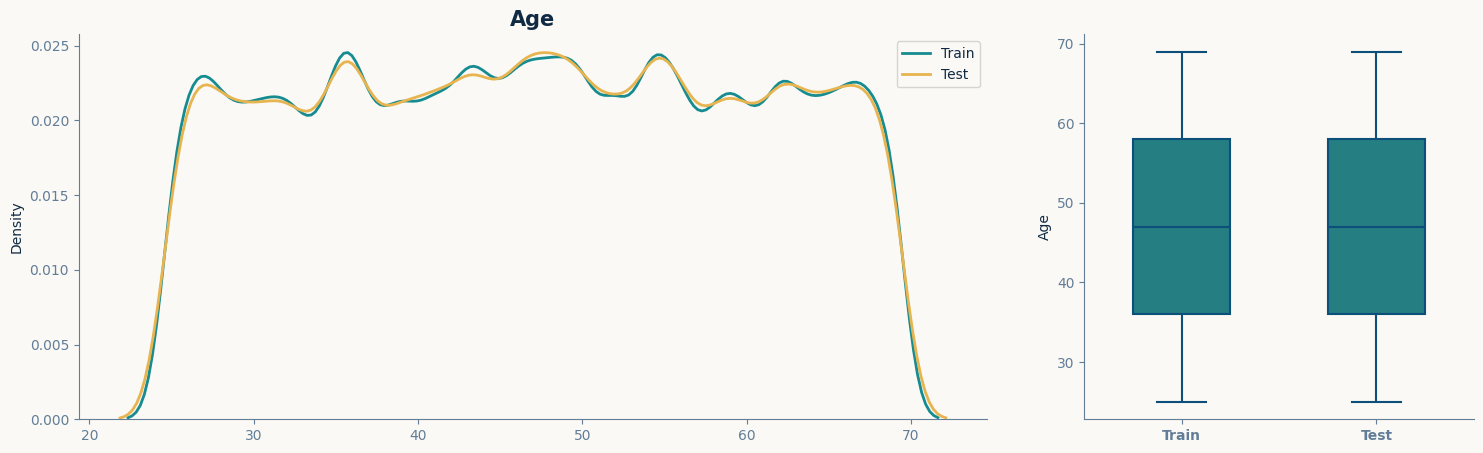

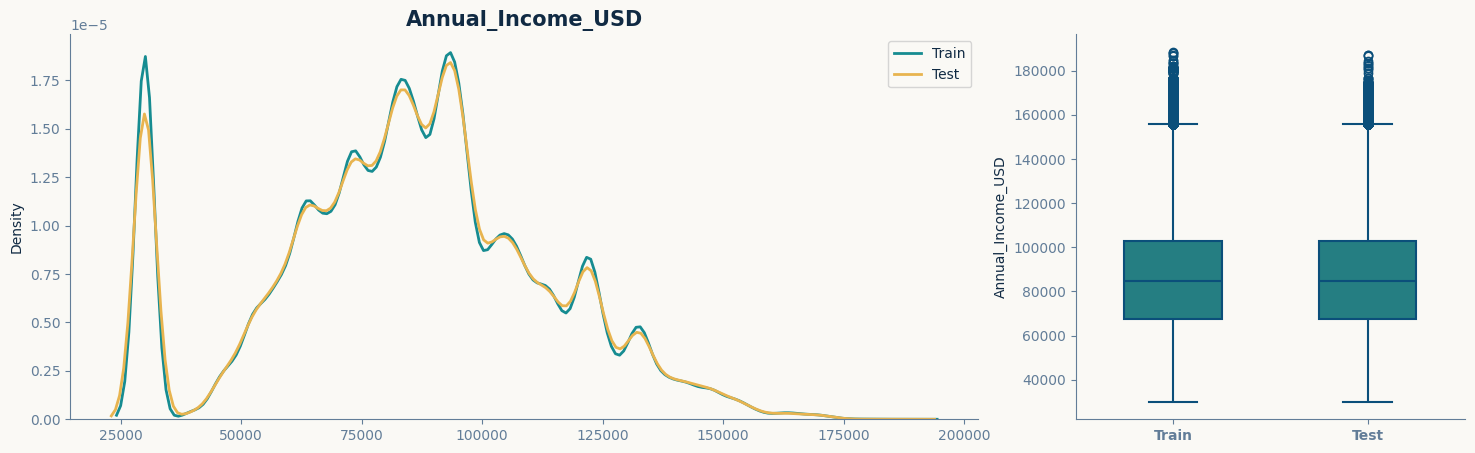

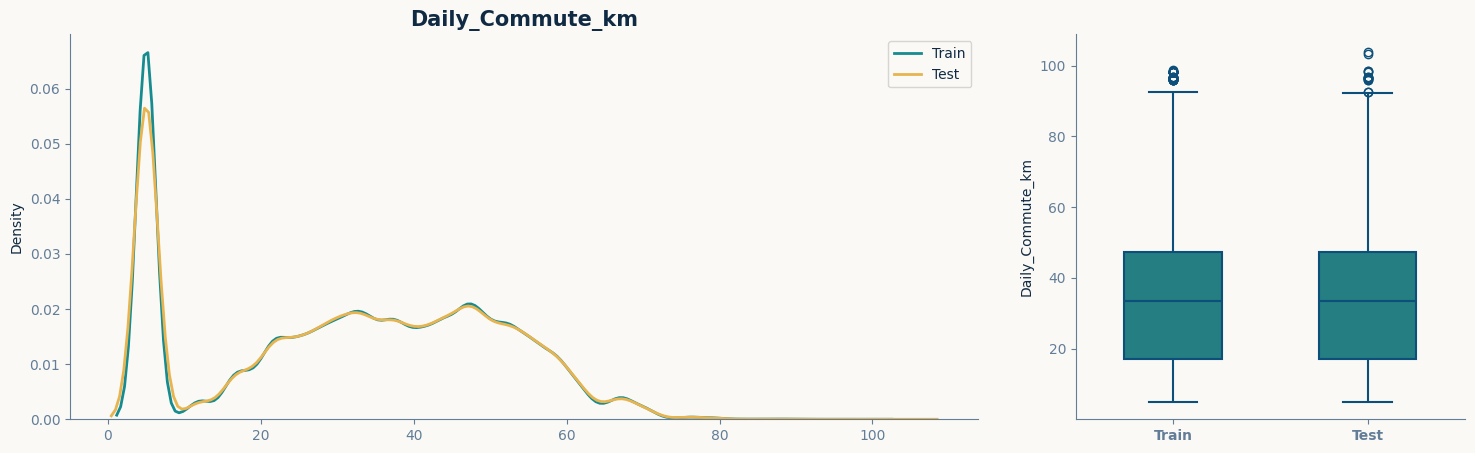

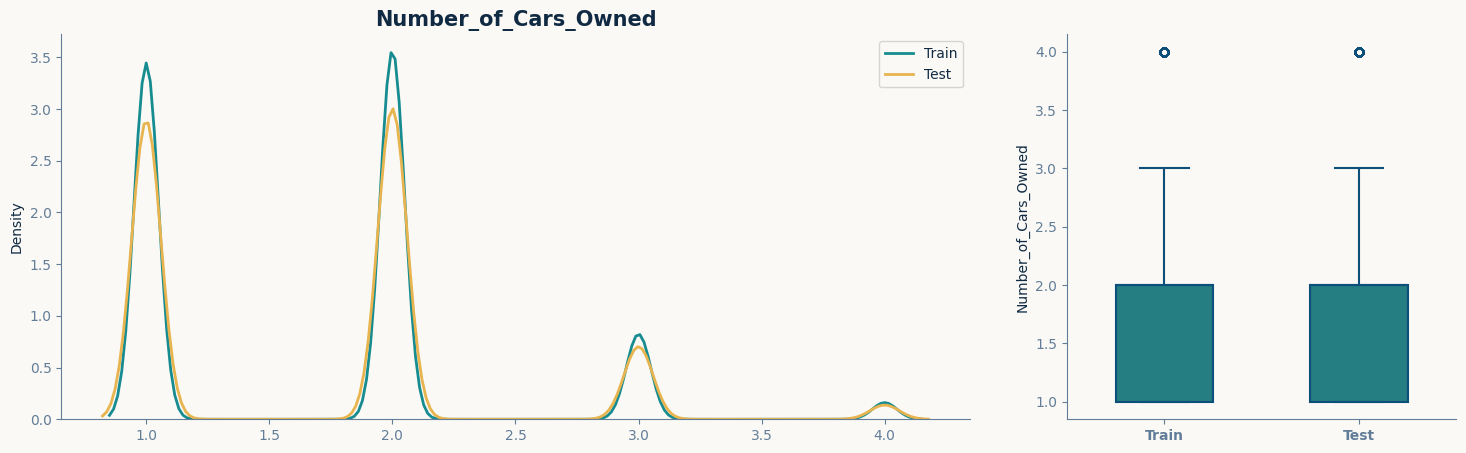

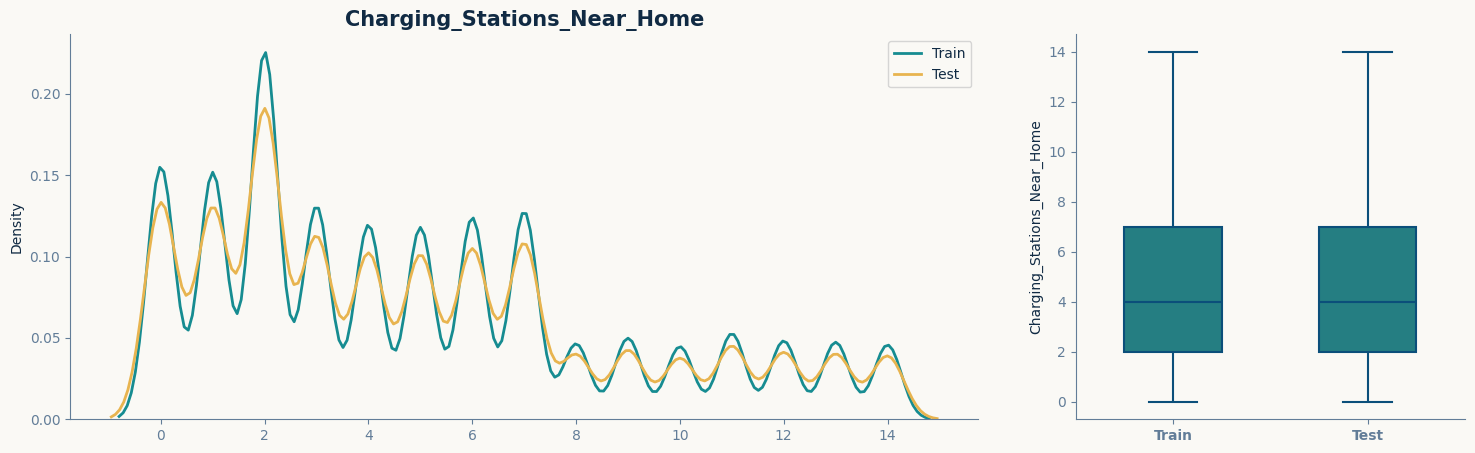

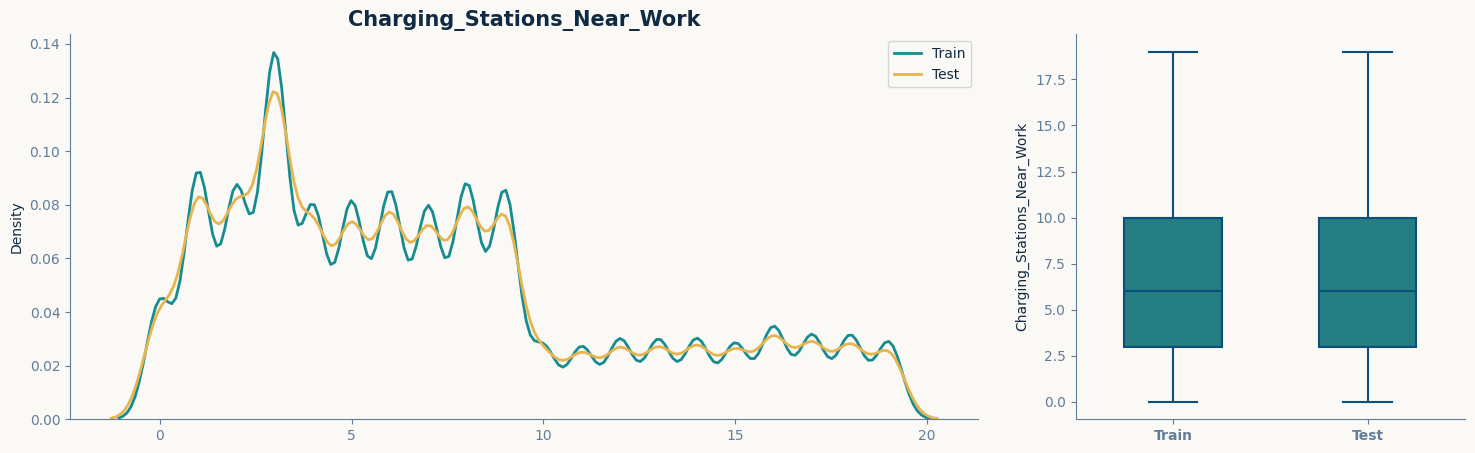

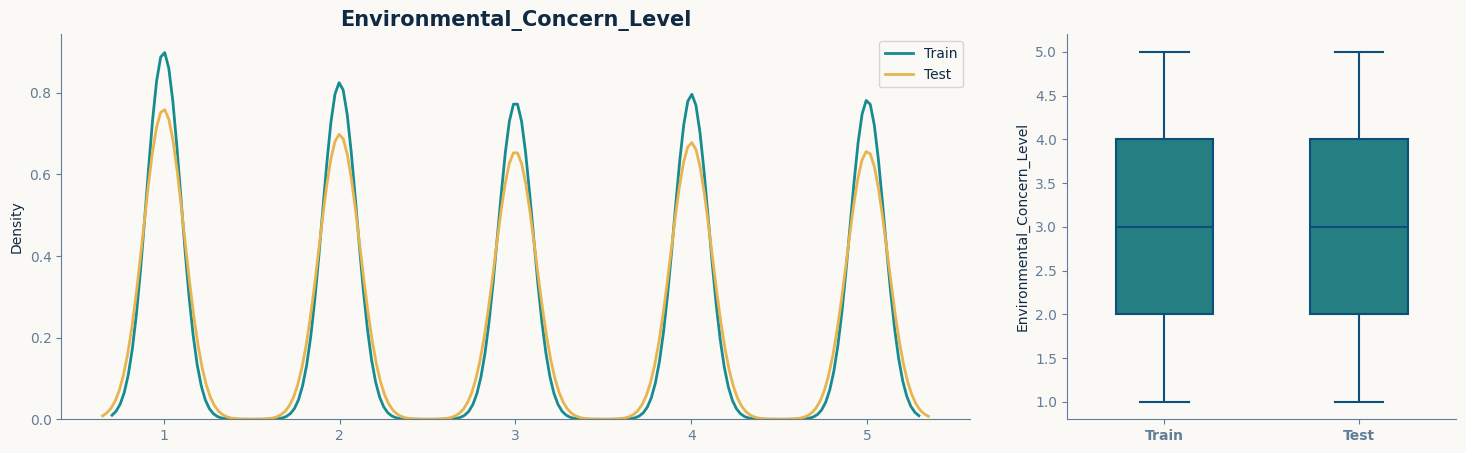

In [19]:
num_distplots = distplots_data(train=train, test=test, features=NUMS) # orig=orig

In [20]:
NUMS

['Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level']

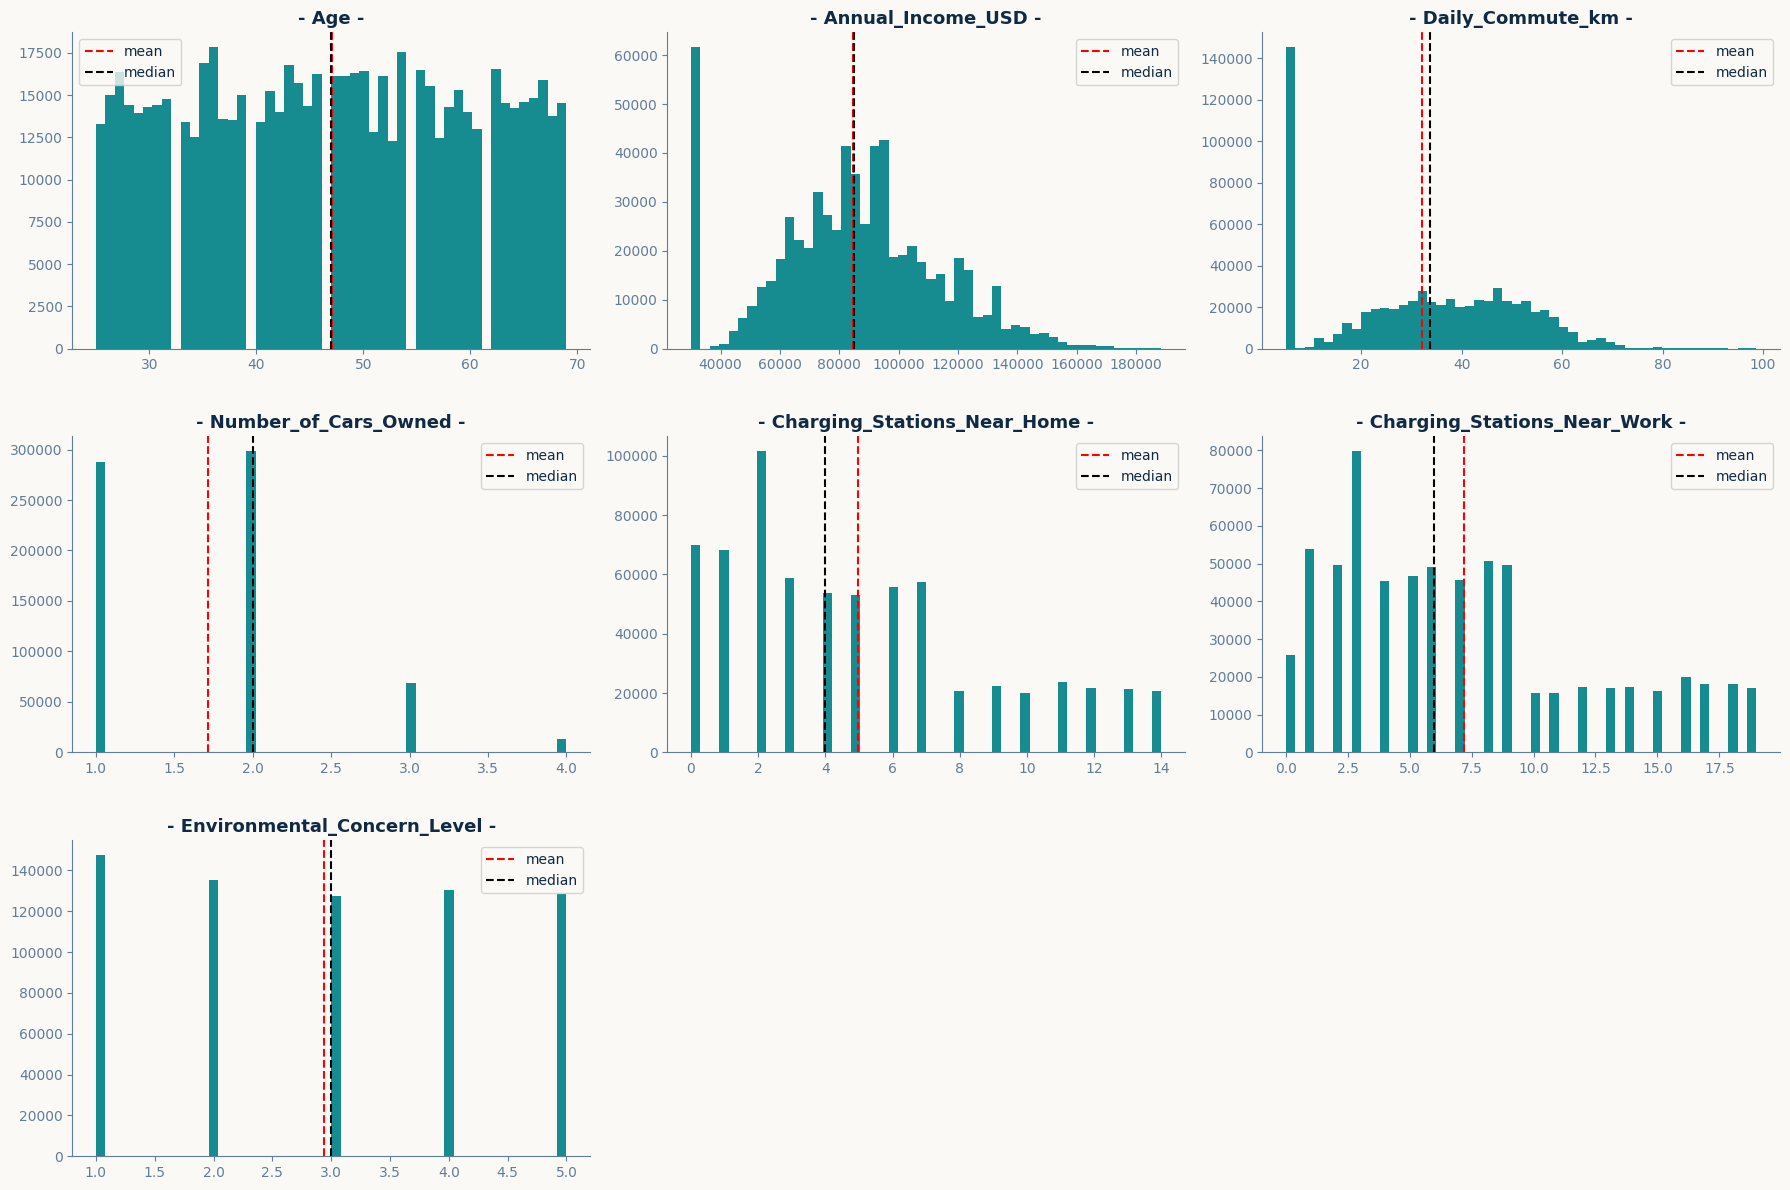

In [21]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(NUMS):
    plt.subplot(3, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='k', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout(h_pad=3.0)
plt.show()

## ~ CATEGORICAL

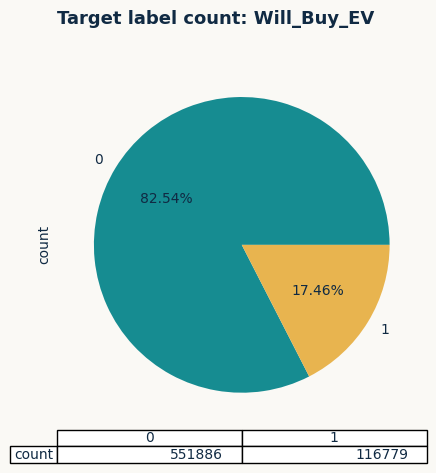

In [22]:
## -- Target label count --
_ = train[TARGET].value_counts(dropna=False).plot.pie(autopct='%1.2f%%', table=True)
_.set_title(f"Target label count: {TARGET}", loc="left", pad=26)
plt.show()

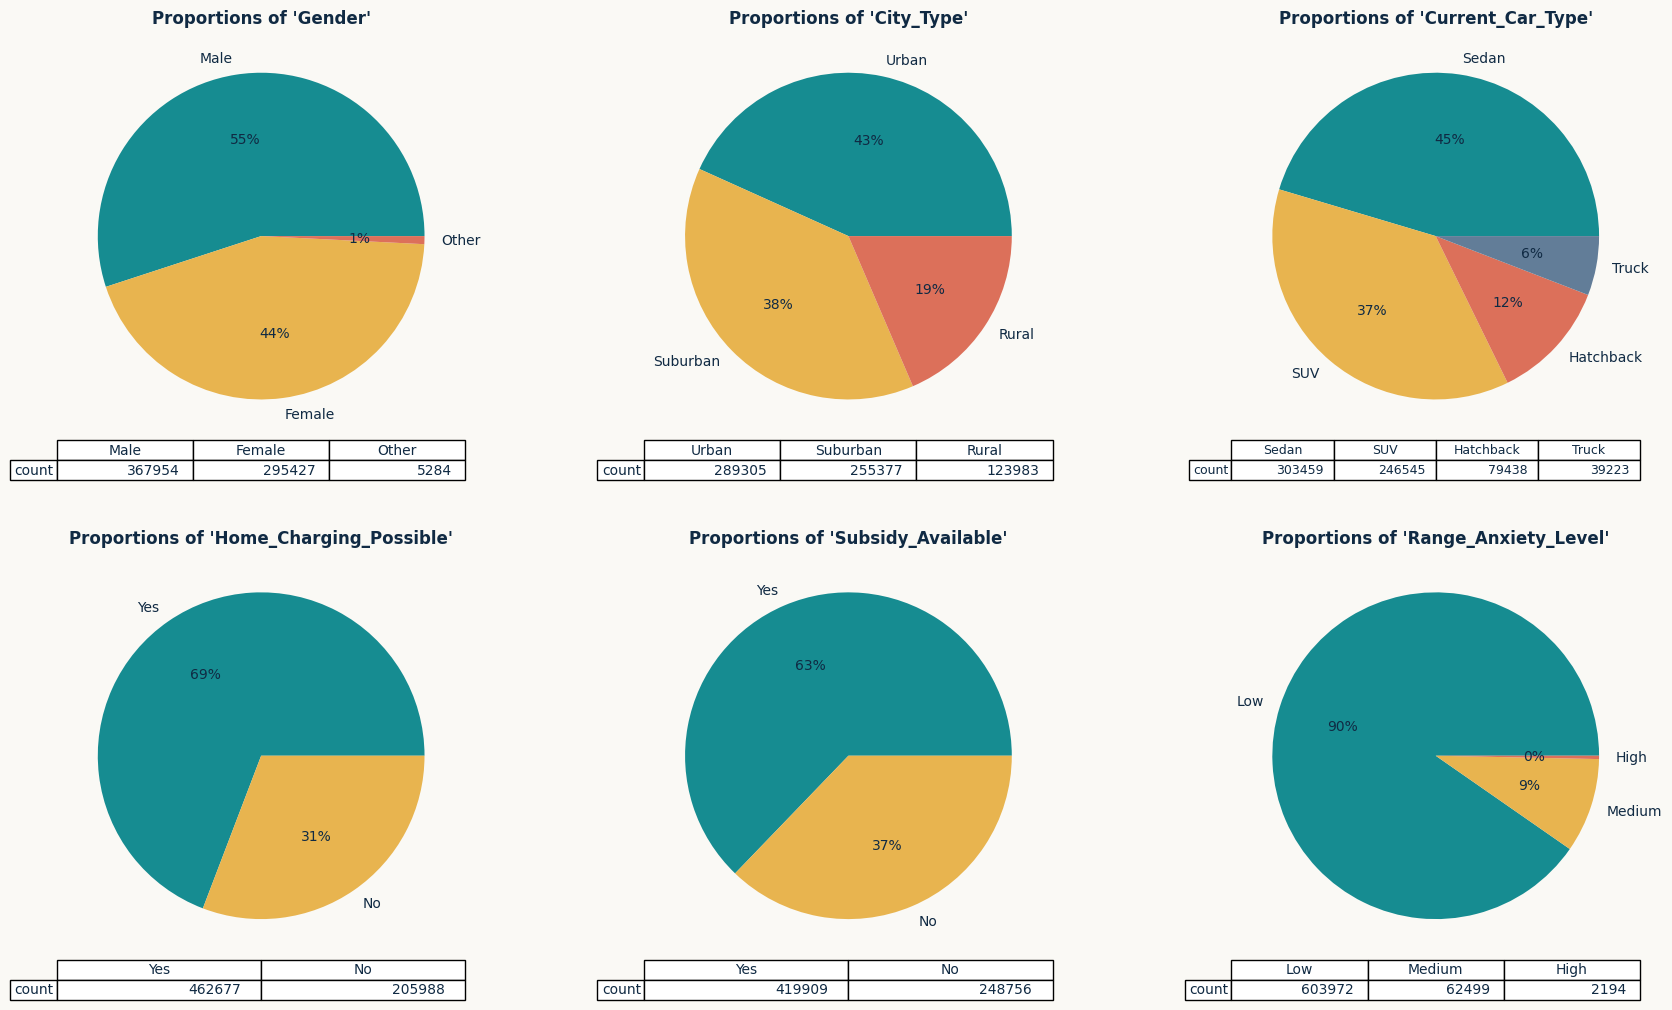

In [23]:
## -- Categorical Features --
plt.figure(figsize=(18, 15))
# for i, col in enumerate([c for c in BASE if train[c].nunique() <= 20]):
for i, col in enumerate(CATS):
    plt.subplot(3, 3, i+1)
    values=train[col].value_counts(dropna=False)
    values.plot.pie(autopct='%1.0f%%', table=True) #fontsize=12, 
    plt.title(f"Proportions of '{col}'", fontdict={'size':12, 'weight': 'bold'})
    plt.axis('off')

plt.tight_layout(h_pad=4.0, w_pad=0.25)
plt.show()

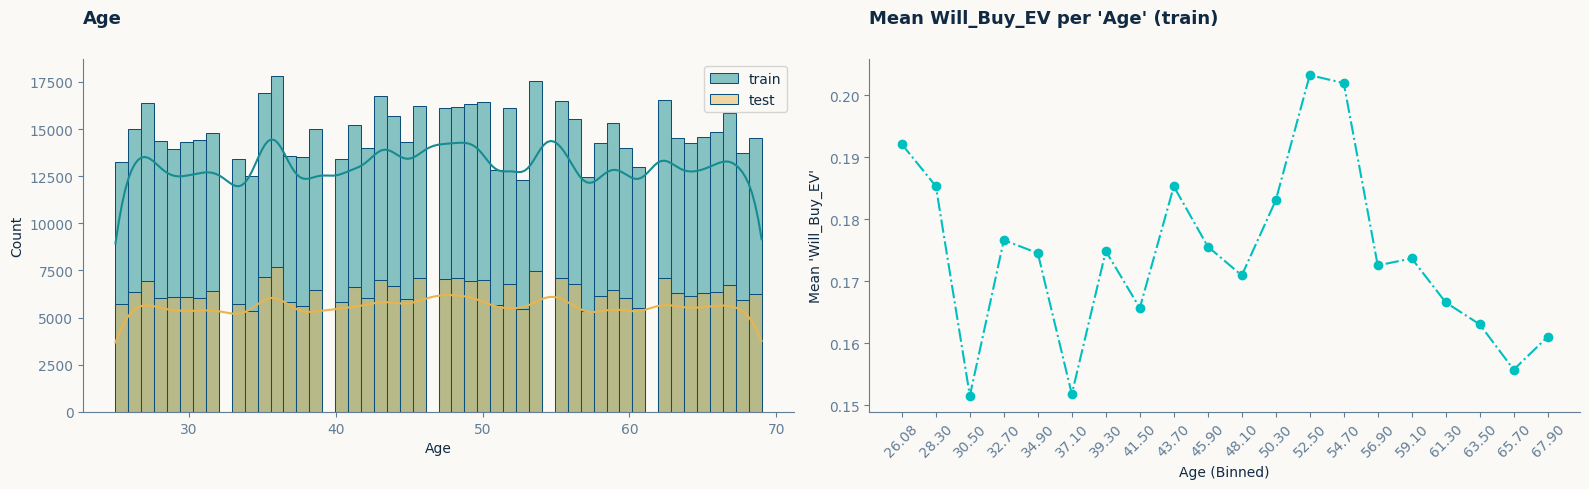

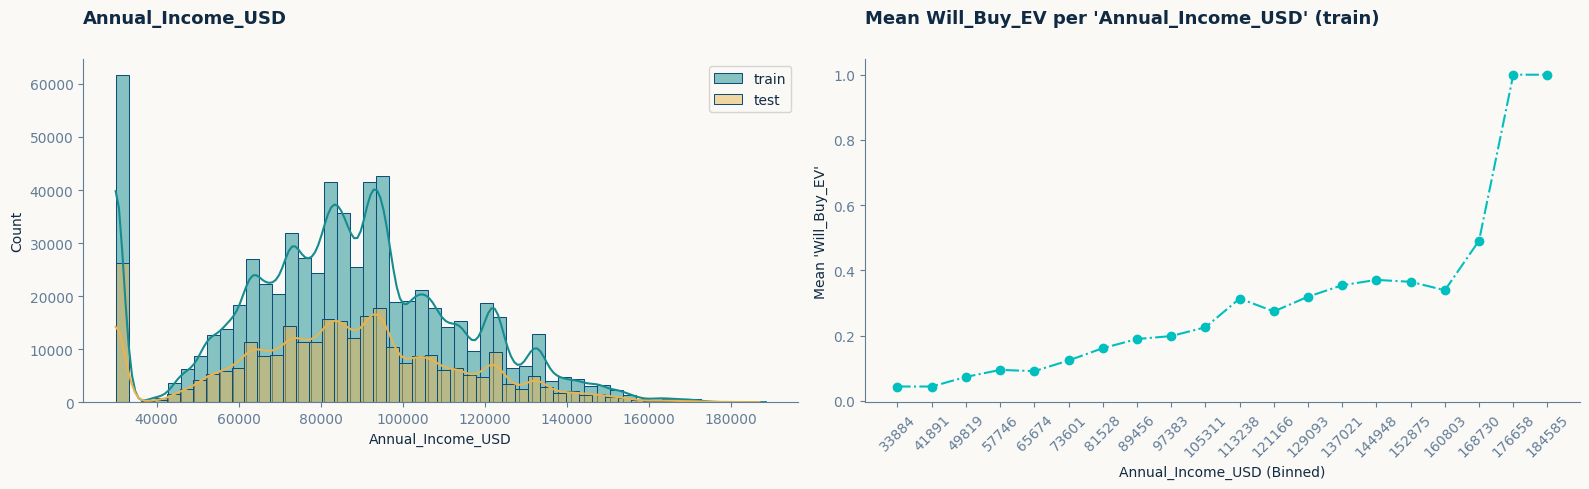

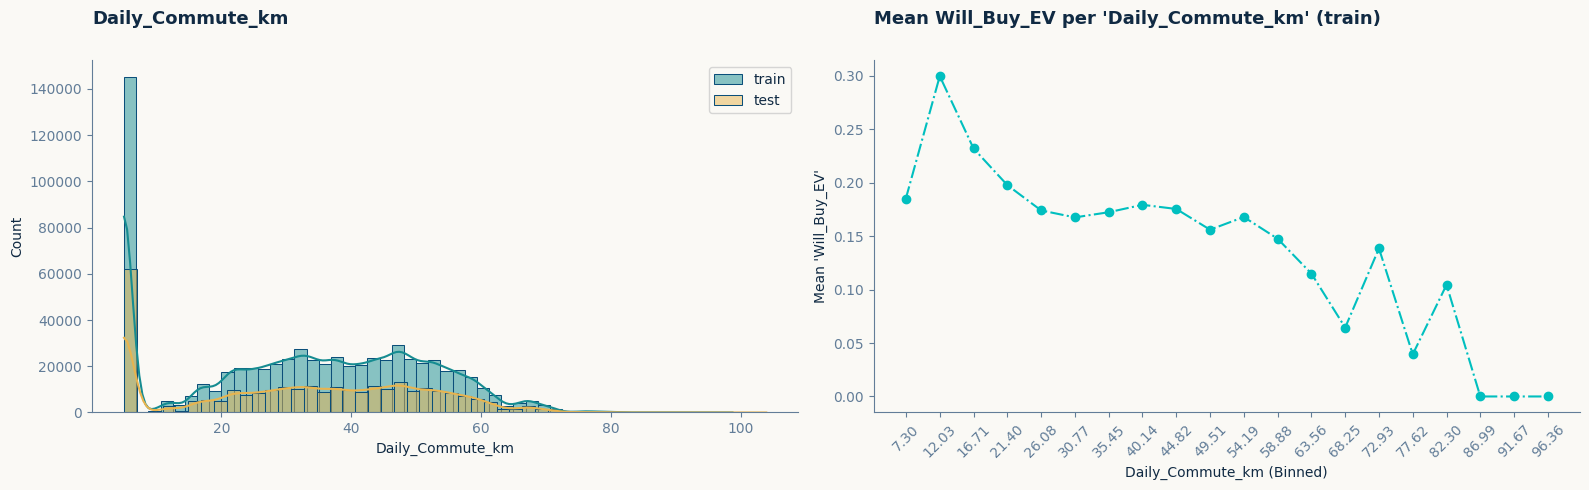

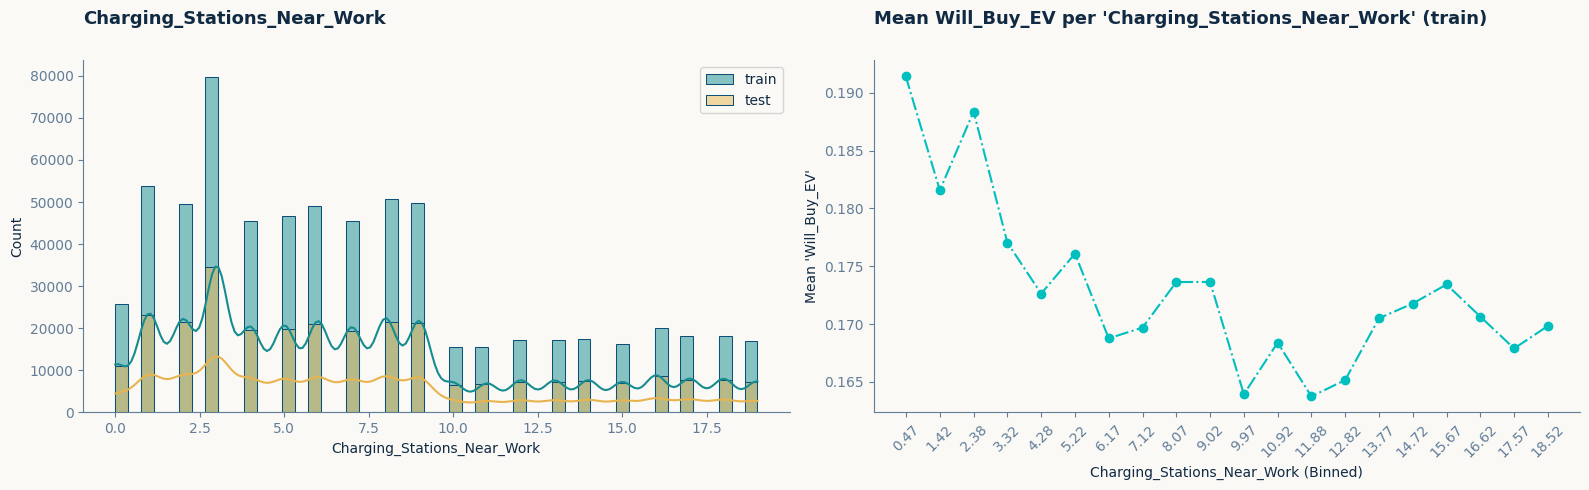

In [24]:
BINS = 20

for c in NUMS: #, 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']:
    if train[c].nunique() >= BINS: 
        # Plot 'train' & 'test' distributions
        plt.figure(figsize=(16, 5))
        plt.subplot(121)
        sns.histplot(train[c], kde=True, bins=50, label='train')
        sns.histplot(test[c], kde=True, bins=50, label='test')
        plt.legend()
        plt.title(f"{c}", loc='left', pad=26)
        # plt.xticks('')
        ## -- Plot relationship between 'target' and bins
        plt.subplot(122)
        train['bucket'], edges = pd.cut(train[c],bins=BINS,include_lowest=True,retbins=True,labels=False)
        # train['bucket'], edges = pd.qcut(train[c],q=BINS,retbins=True,labels=False)
        bucket_means = train.groupby('bucket')[TARGET].mean()
        bin_midpoints = (edges[:-1] + edges[1:]) / 2
        plt.plot(bin_midpoints, bucket_means, marker='o',linestyle='-.',color='c')
        plt.xlabel(f'{c} (Binned)')
        plt.ylabel(f"Mean '{TARGET}'")
        plt.title(f"Mean {TARGET} per '{c}' (train)", loc='left', pad=26)
        plt.xticks(bin_midpoints, rotation=45)
    
        plt.tight_layout()
        plt.show()

train.drop(['bucket'], axis=1, inplace=True)

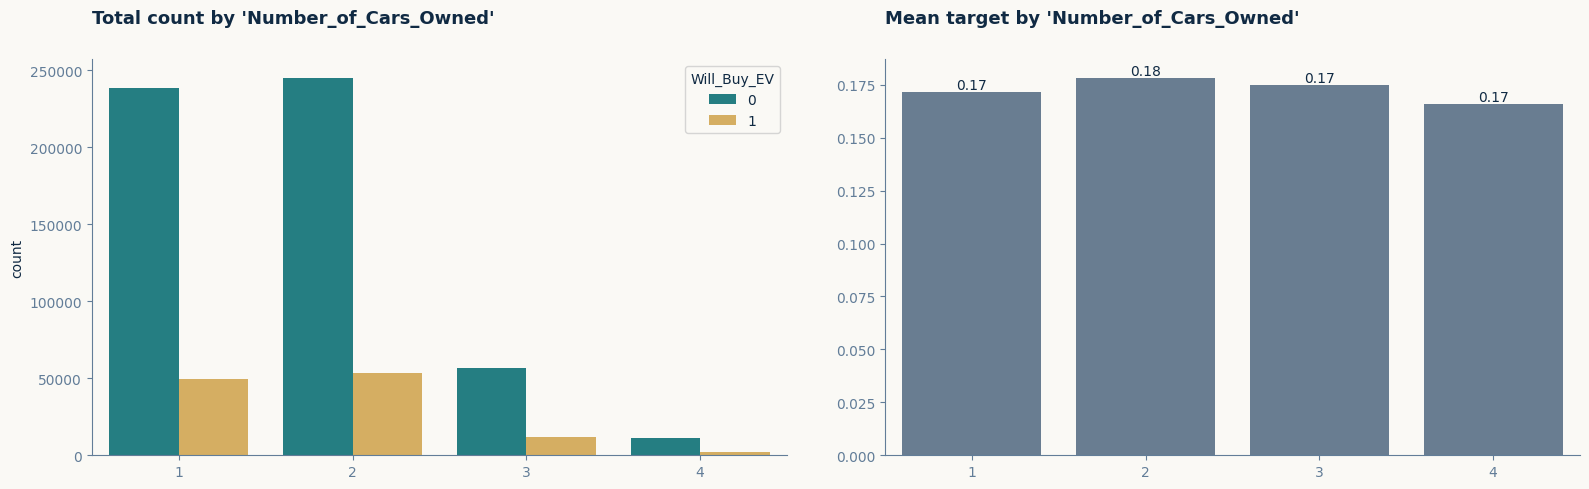

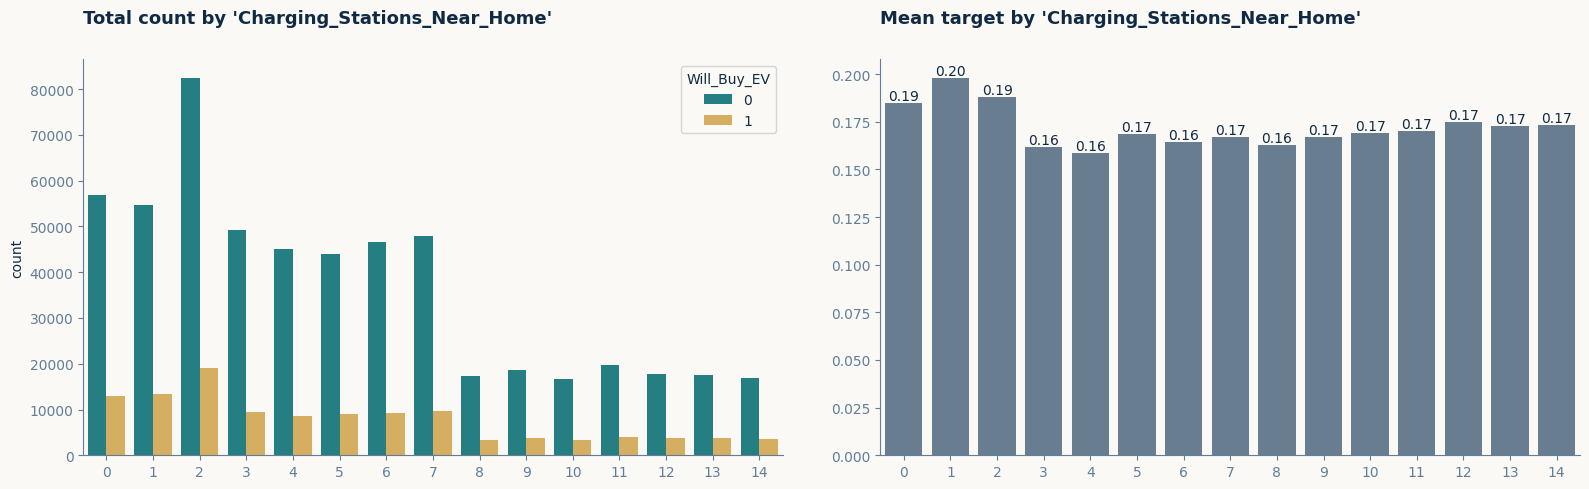

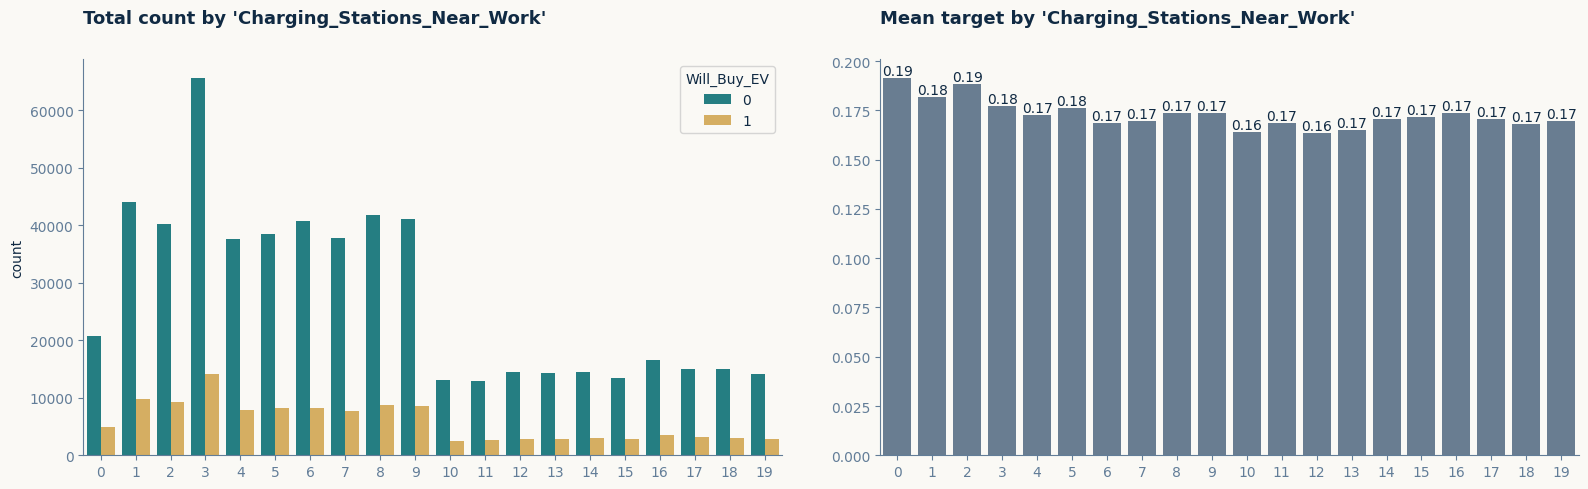

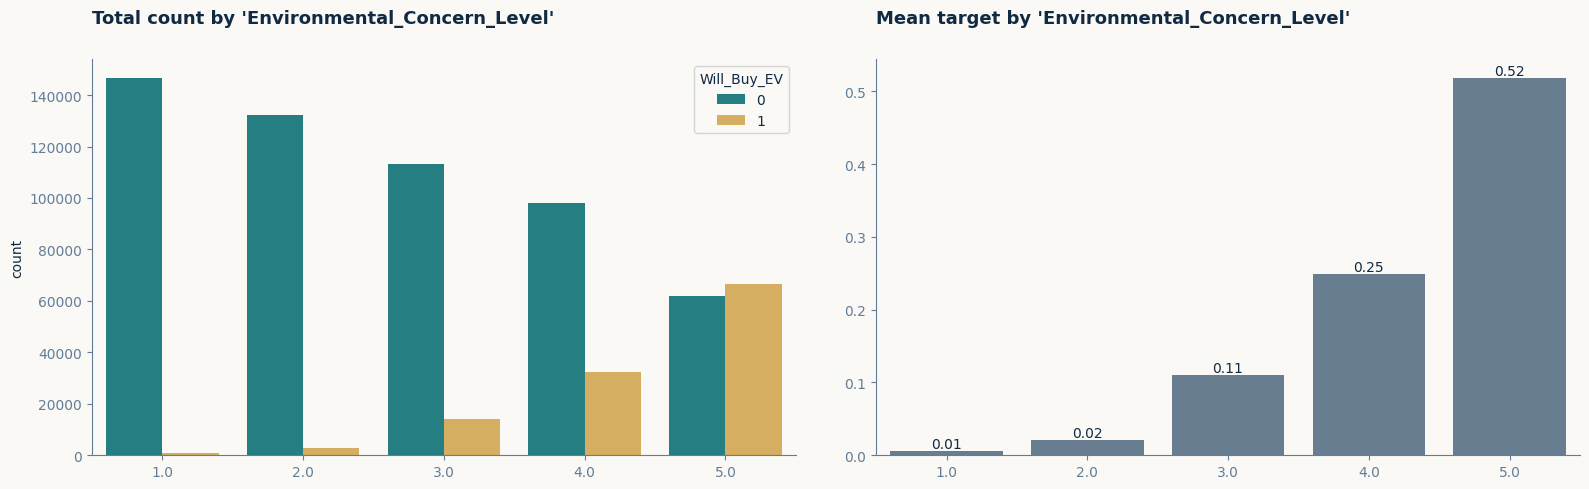

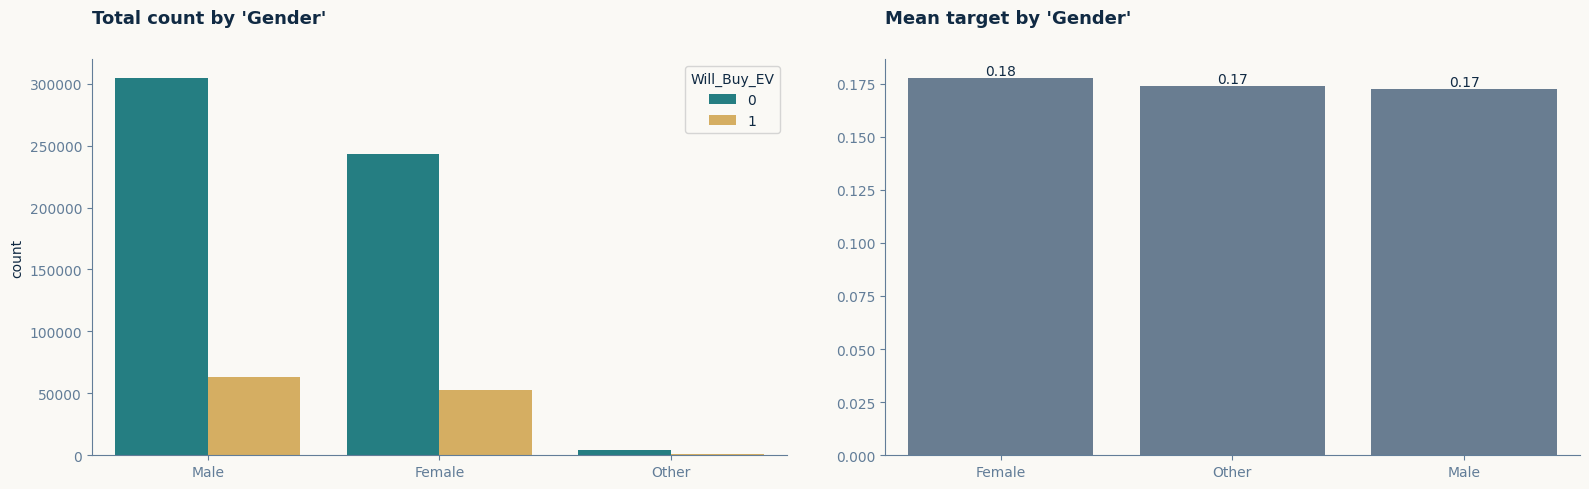

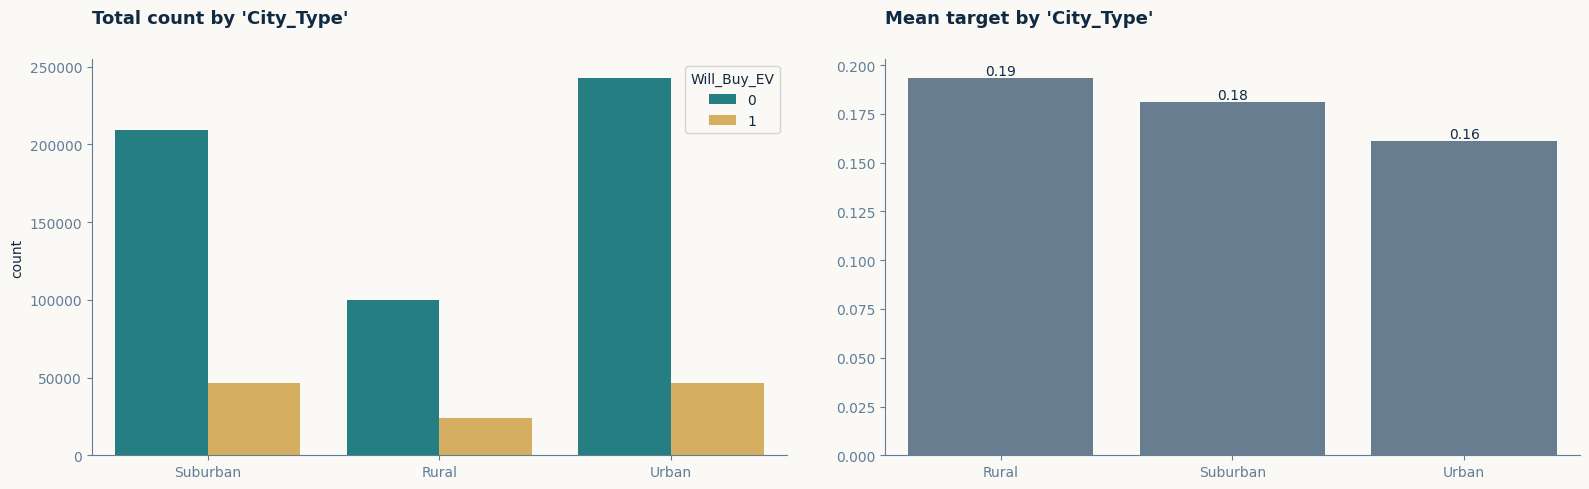

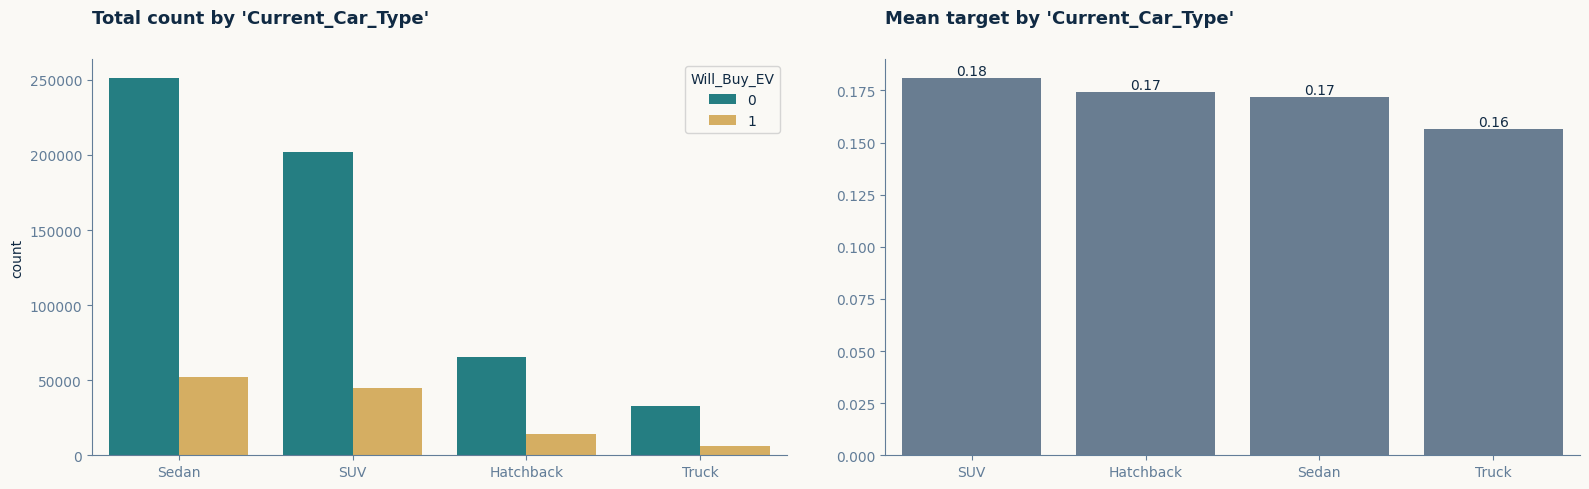

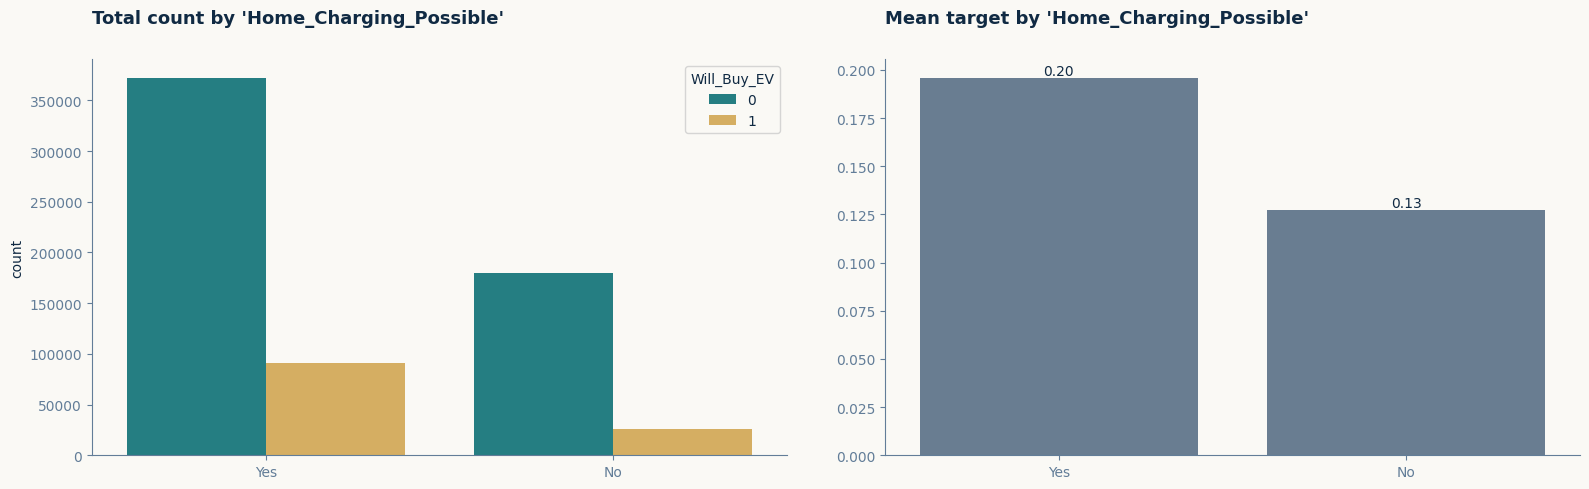

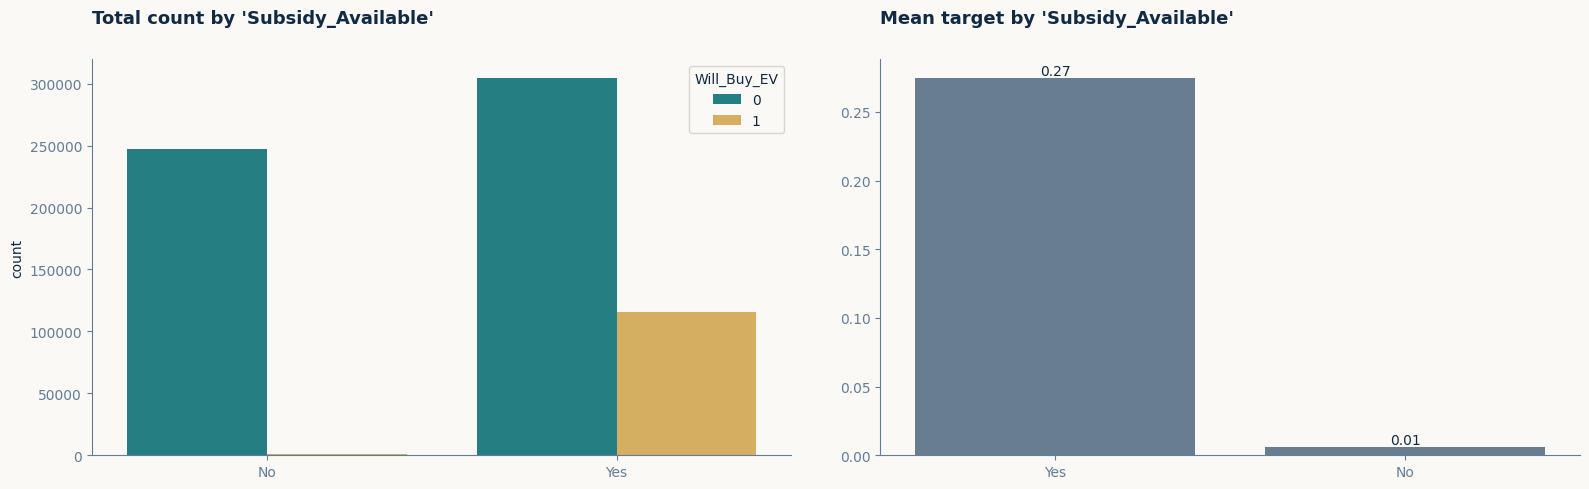

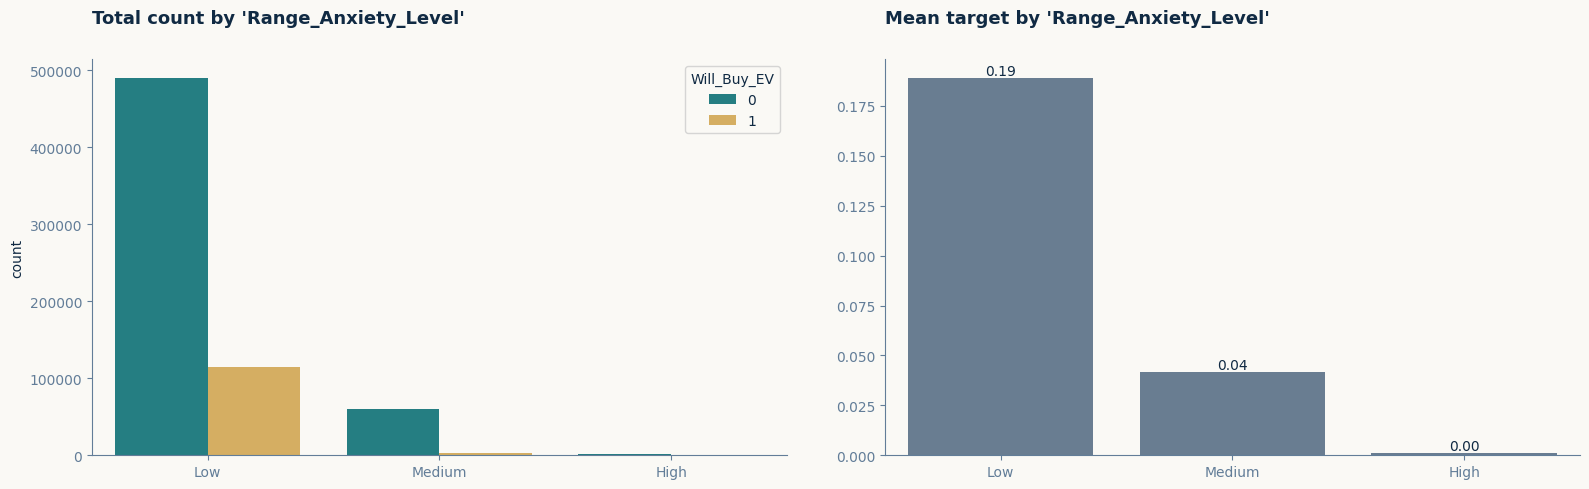

In [25]:
## -- Categorical Features: Counts and Mean by TARGET --
## -- Features with unique count <= 100
CATS_100 = [c for c in BASE if train[c].nunique() <= 20]

for i, c in enumerate(CATS_100):
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    sns.countplot(train, x=c, hue=TARGET, ax=axs[0])
    axs[0].set_title(f"Total count by '{c}'", loc="left", pad=26)
    axs[0].set_xlabel('')
    axs[0].tick_params(axis='x', rotation=0)

    v_mean = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=v_mean.index, y=v_mean.values, ax=axs[1], color=MUTED)
    axs[1].set_title(f"Mean target by '{c}'", loc="left", pad=26)
    axs[1].set_xlabel('')
    axs[1].tick_params(axis='x', rotation=0)

    for container in axs[1].containers: # Display values on bars
        axs[1].bar_label(container, fmt='%.2f')

    _ = fig.tight_layout(w_pad=3.5)
    plt.show()
    print()

## ~ PAIRWISE (CATEGORICAL) ANALYSIS

In [26]:
n_unique = train[BASE].nunique().sort_values()
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
Gender                             3
City_Type                          3
Range_Anxiety_Level                3
Number_of_Cars_Owned               4
Current_Car_Type                   4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

In [27]:
# if train[combo[0]].nunique() > train[combo[1]].nunique():
#     print(f'a: {combo[0]} has more nunique values than b: {combo[1]}')
#     combo = [combo[0], combo[0]]
#     print(combo)
# else:
#     print(f'b: {combo[1]} has more nunique values than a: {combo[0]}')
#     combo = [combo[1], combo[0]]
#     print(combo)

('Home_Charging_Possible', 'Subsidy_Available')| Subsidy_Available has more unique variables | ['Subsidy_Available', 'Home_Charging_Possible']


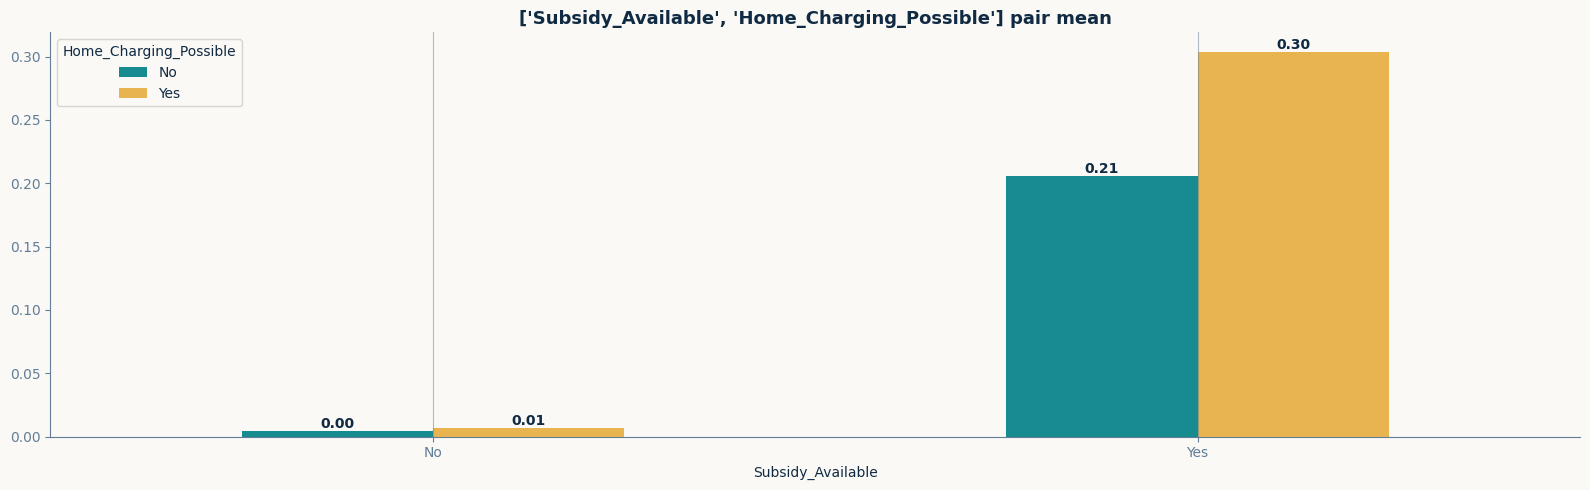


('Home_Charging_Possible', 'Gender')| Gender has more unique variables | ['Gender', 'Home_Charging_Possible']


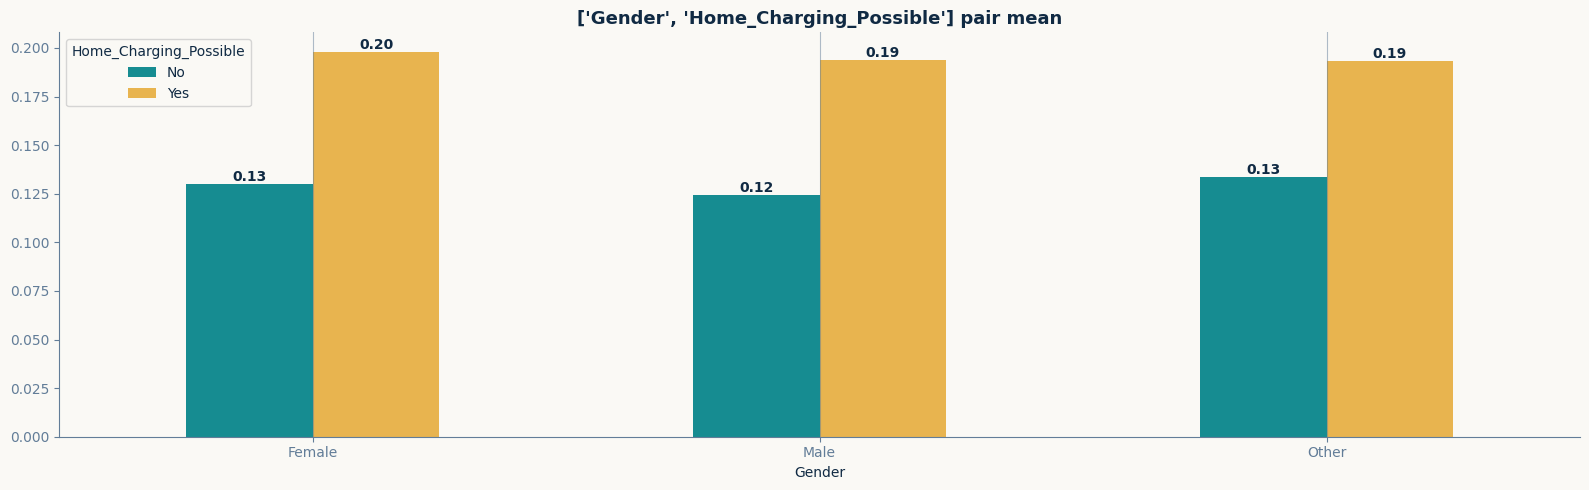


('Home_Charging_Possible', 'City_Type')| City_Type has more unique variables | ['City_Type', 'Home_Charging_Possible']


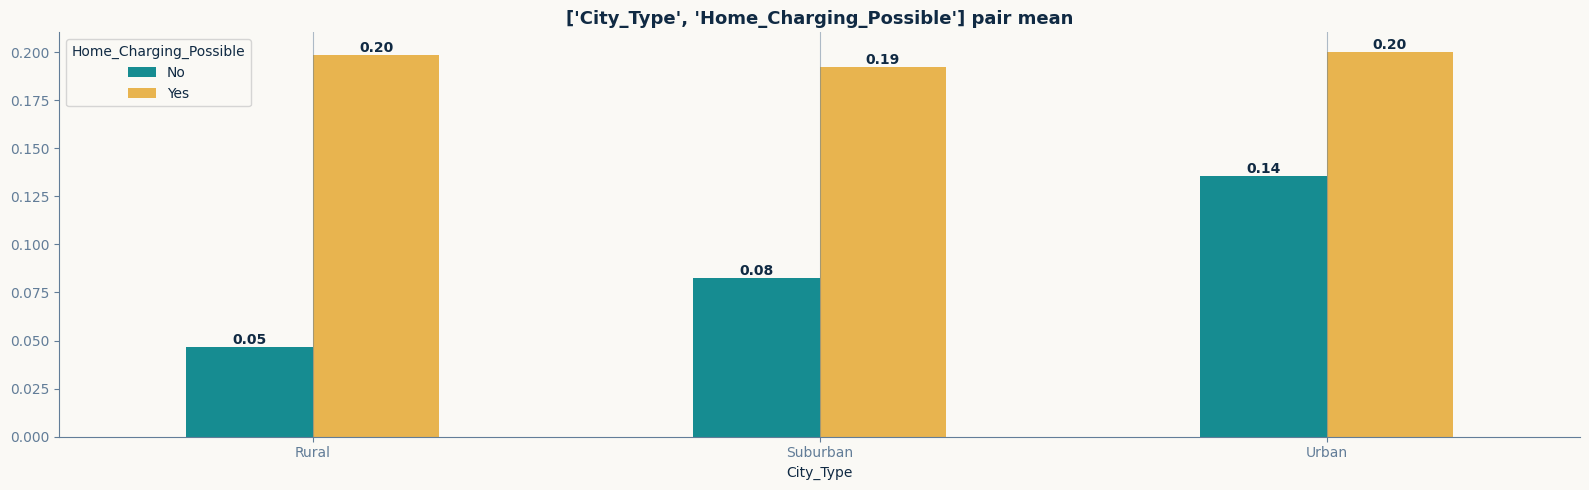


('Home_Charging_Possible', 'Range_Anxiety_Level')| Range_Anxiety_Level has more unique variables | ['Range_Anxiety_Level', 'Home_Charging_Possible']


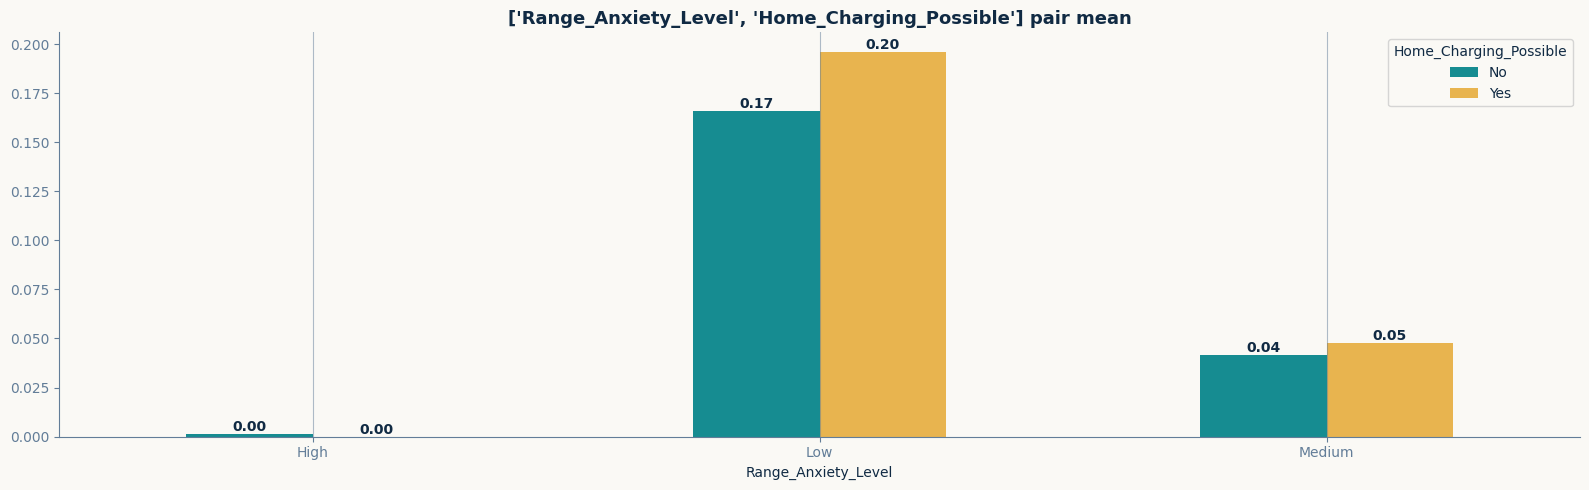


('Home_Charging_Possible', 'Number_of_Cars_Owned')| Number_of_Cars_Owned has more unique variables | ['Number_of_Cars_Owned', 'Home_Charging_Possible']


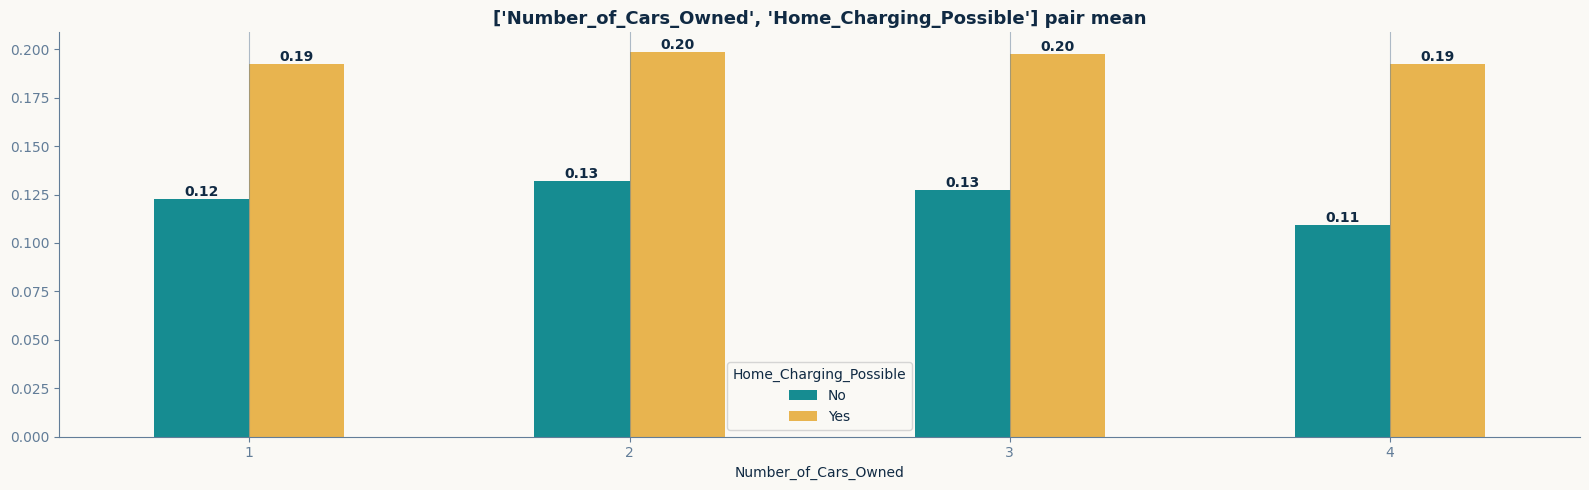


('Home_Charging_Possible', 'Current_Car_Type')| Current_Car_Type has more unique variables | ['Current_Car_Type', 'Home_Charging_Possible']


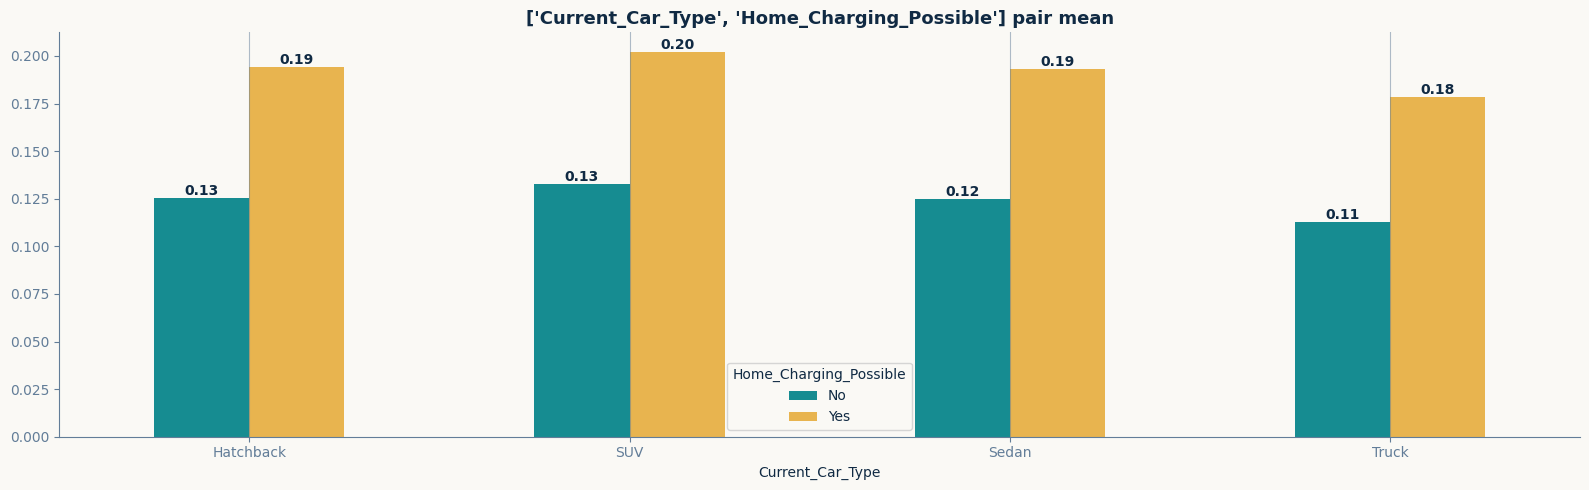


('Home_Charging_Possible', 'Environmental_Concern_Level')| Environmental_Concern_Level has more unique variables | ['Environmental_Concern_Level', 'Home_Charging_Possible']


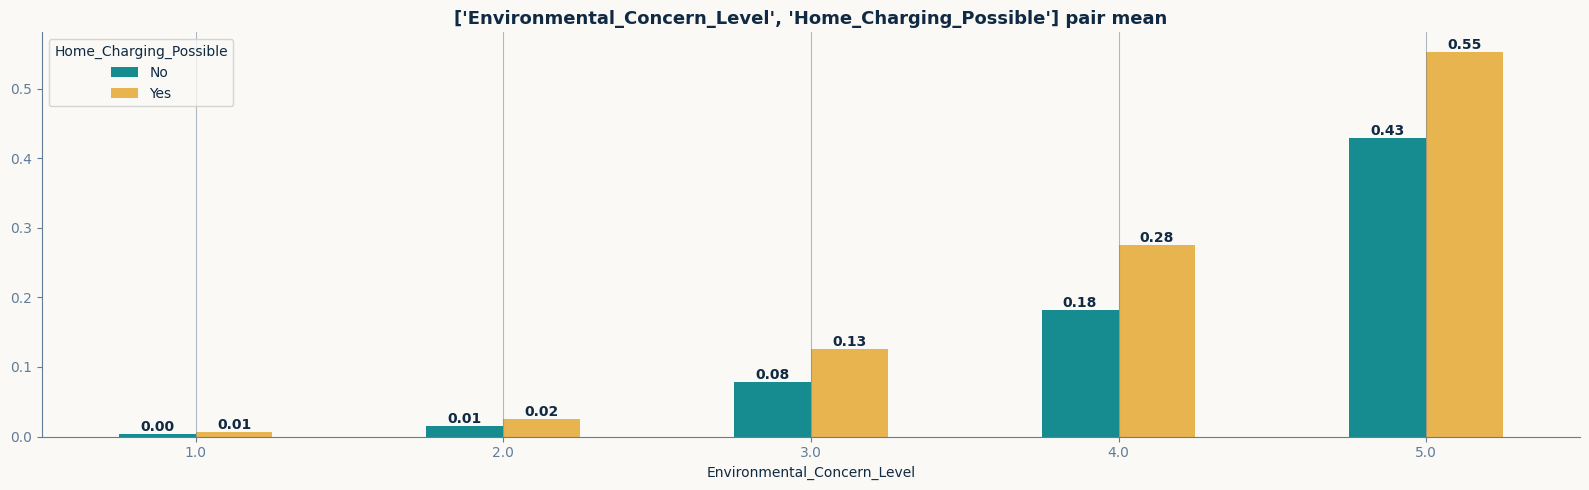


('Subsidy_Available', 'Gender')| Gender has more unique variables | ['Gender', 'Subsidy_Available']


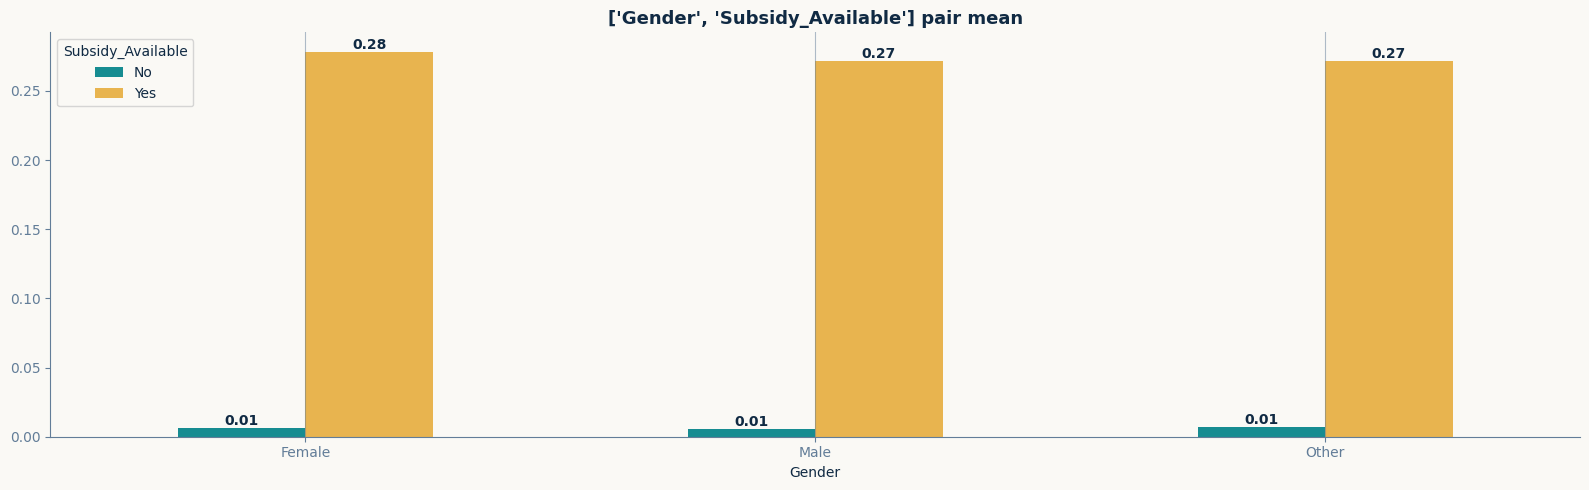


('Subsidy_Available', 'City_Type')| City_Type has more unique variables | ['City_Type', 'Subsidy_Available']


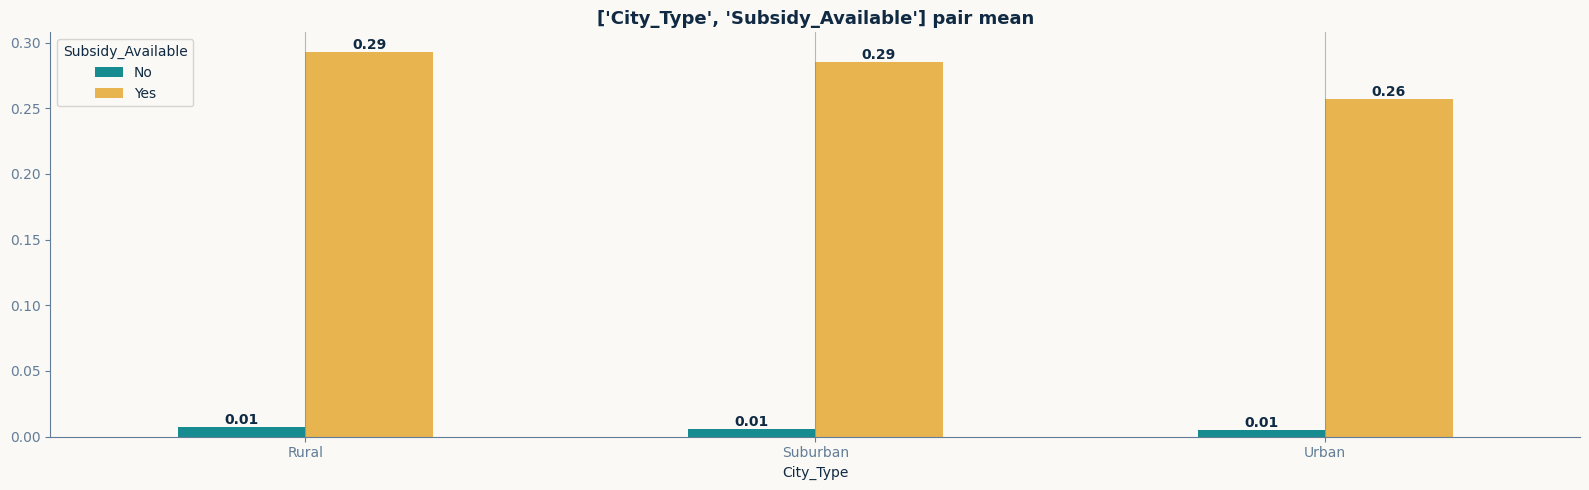


('Subsidy_Available', 'Range_Anxiety_Level')| Range_Anxiety_Level has more unique variables | ['Range_Anxiety_Level', 'Subsidy_Available']


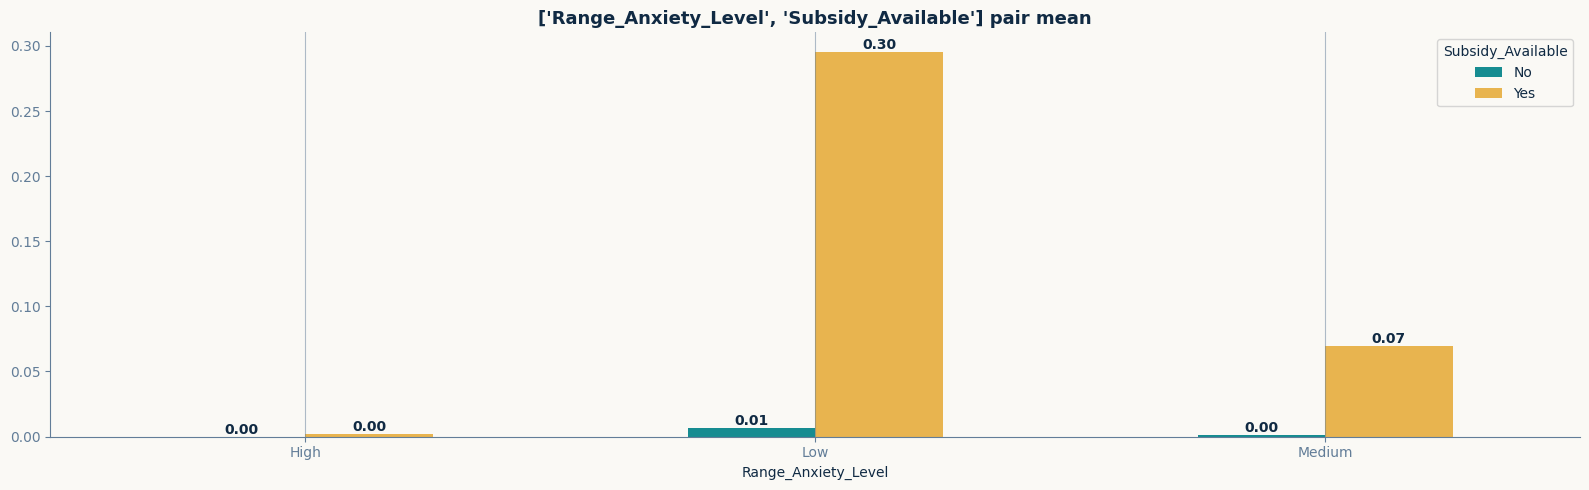


('Subsidy_Available', 'Number_of_Cars_Owned')| Number_of_Cars_Owned has more unique variables | ['Number_of_Cars_Owned', 'Subsidy_Available']


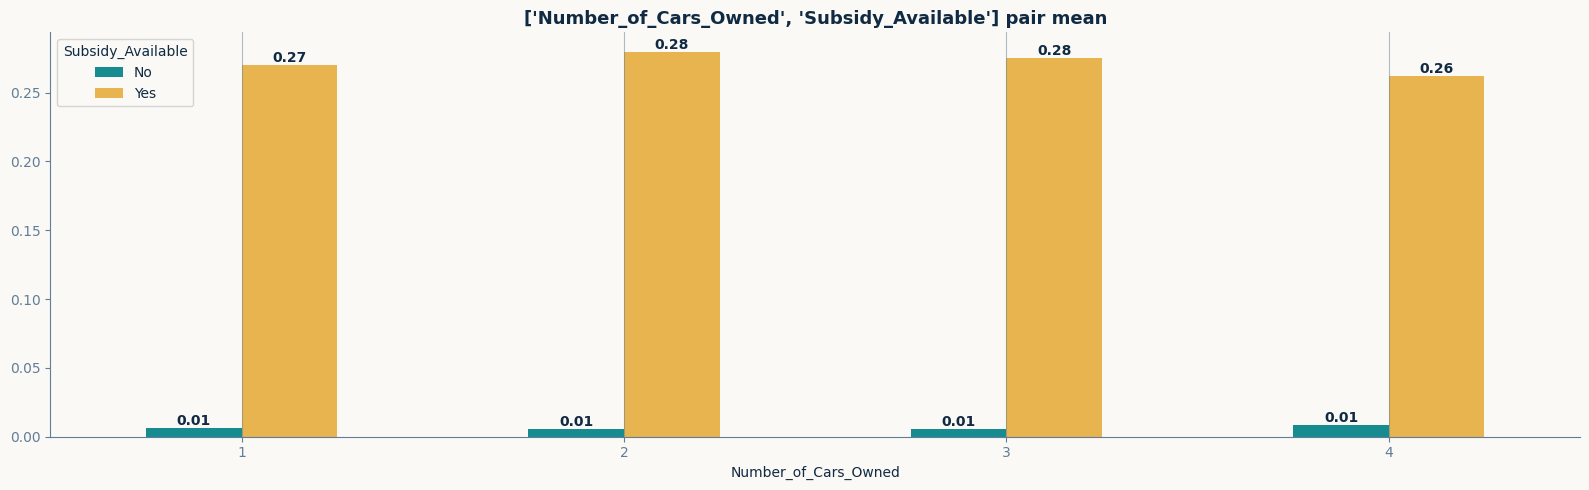


('Subsidy_Available', 'Current_Car_Type')| Current_Car_Type has more unique variables | ['Current_Car_Type', 'Subsidy_Available']


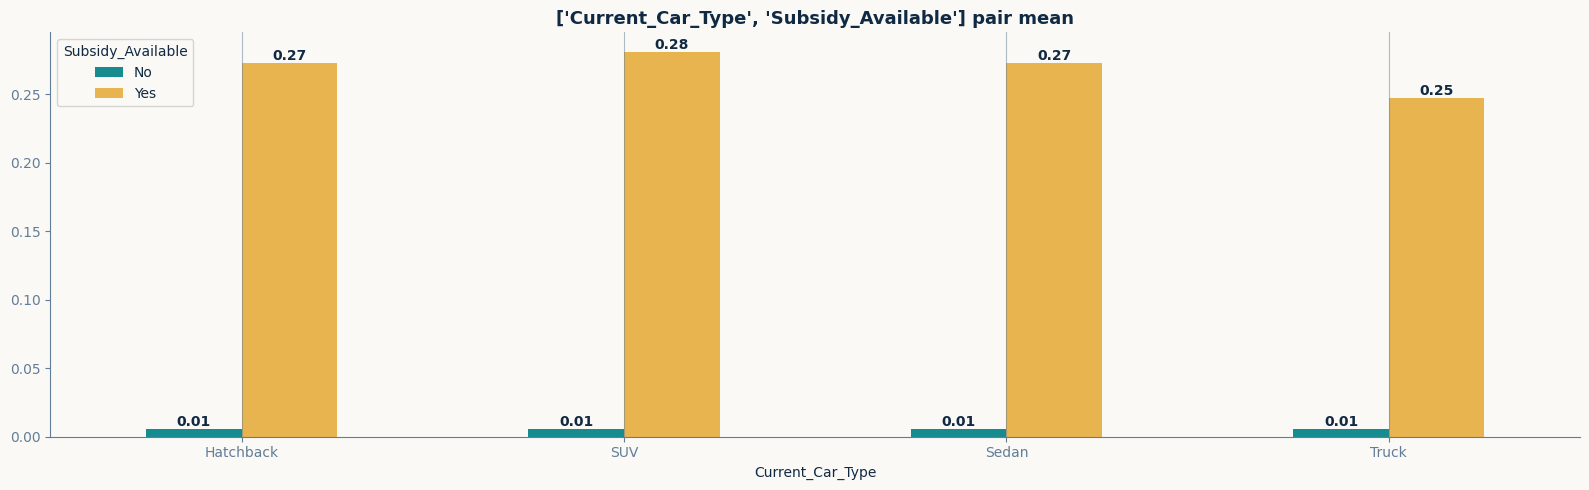


('Subsidy_Available', 'Environmental_Concern_Level')| Environmental_Concern_Level has more unique variables | ['Environmental_Concern_Level', 'Subsidy_Available']


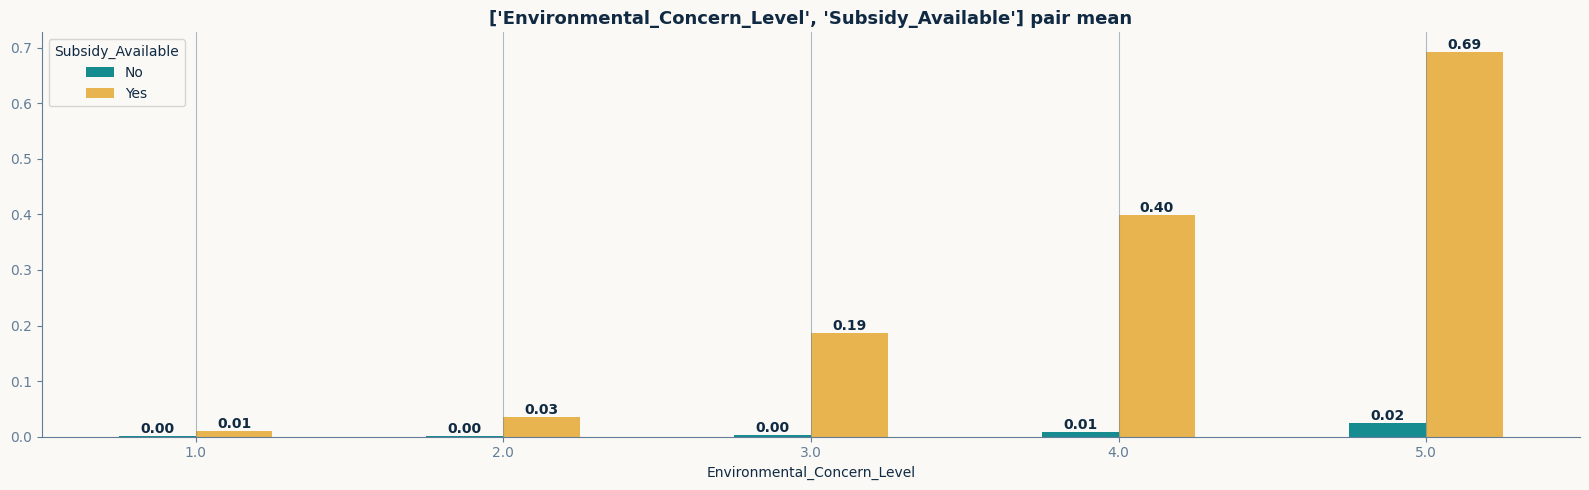


('Gender', 'City_Type')| City_Type has more unique variables | ['City_Type', 'Gender']


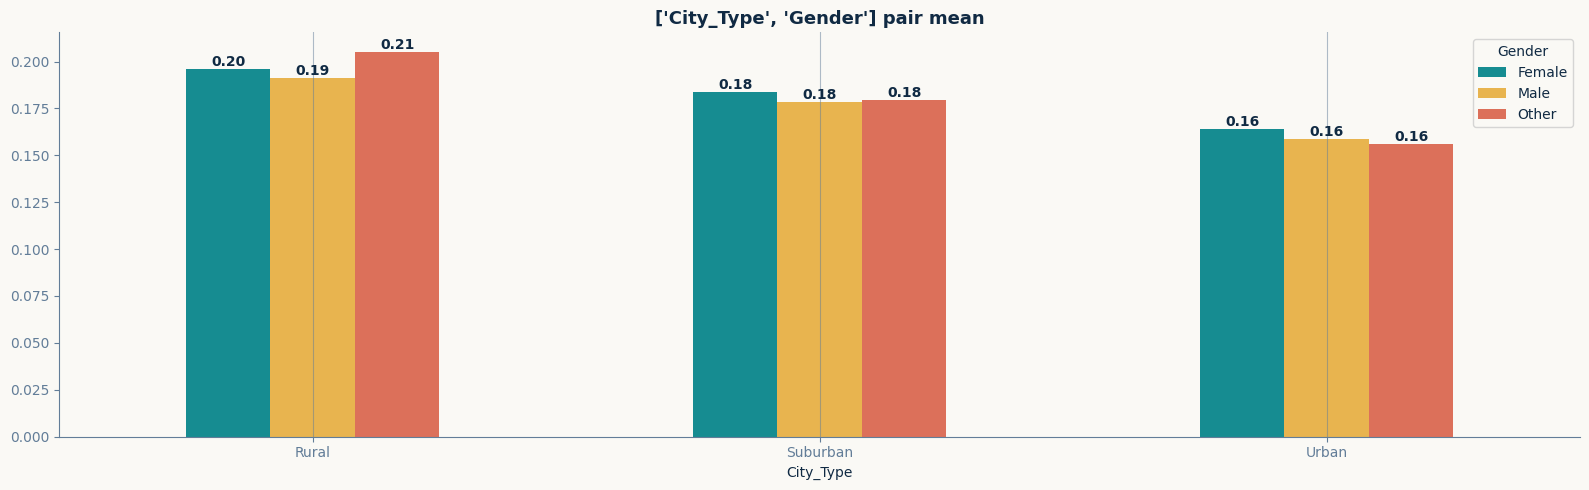


('Gender', 'Range_Anxiety_Level')| Range_Anxiety_Level has more unique variables | ['Range_Anxiety_Level', 'Gender']


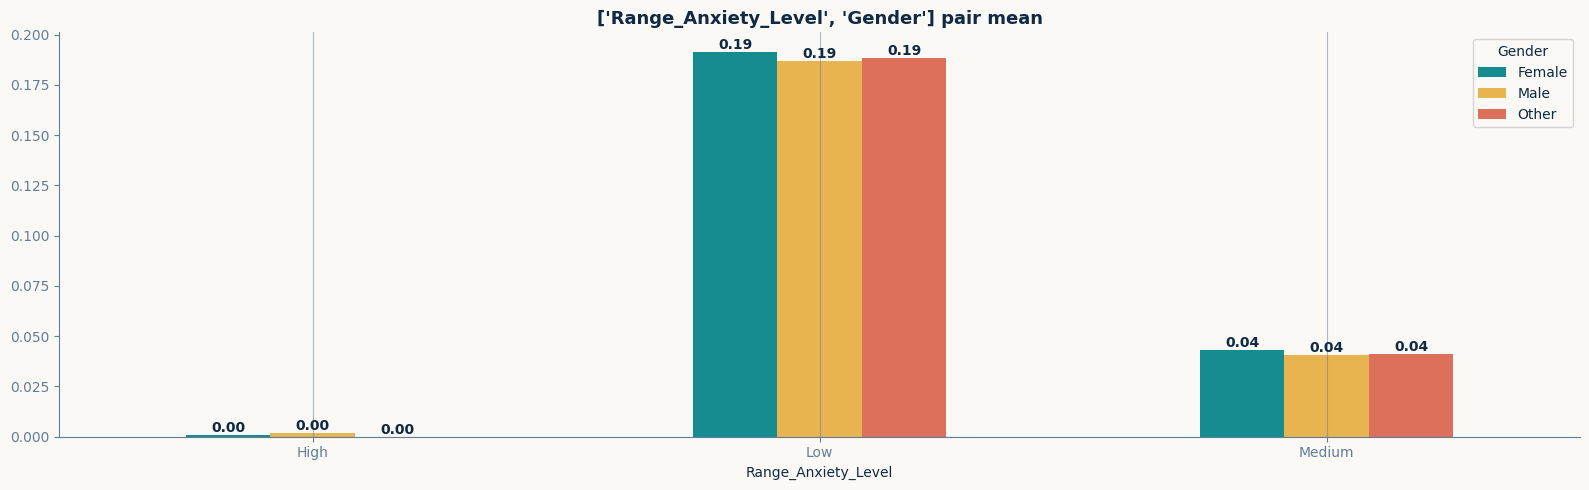


('Gender', 'Number_of_Cars_Owned')| Number_of_Cars_Owned has more unique variables | ['Number_of_Cars_Owned', 'Gender']


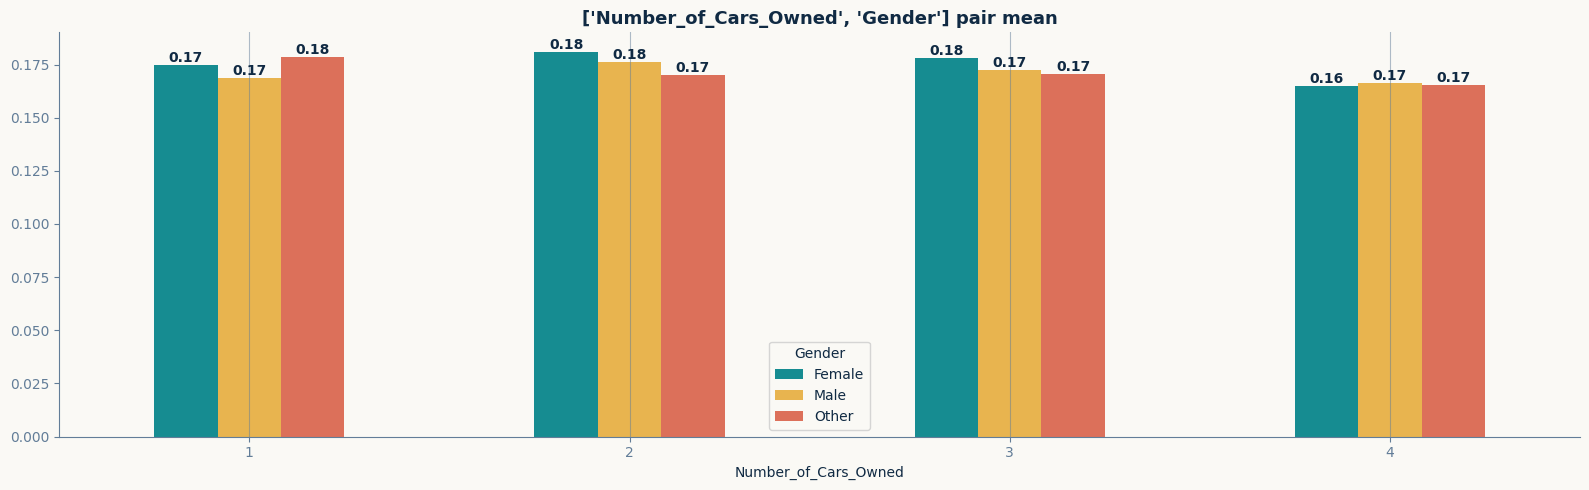


('Gender', 'Current_Car_Type')| Current_Car_Type has more unique variables | ['Current_Car_Type', 'Gender']


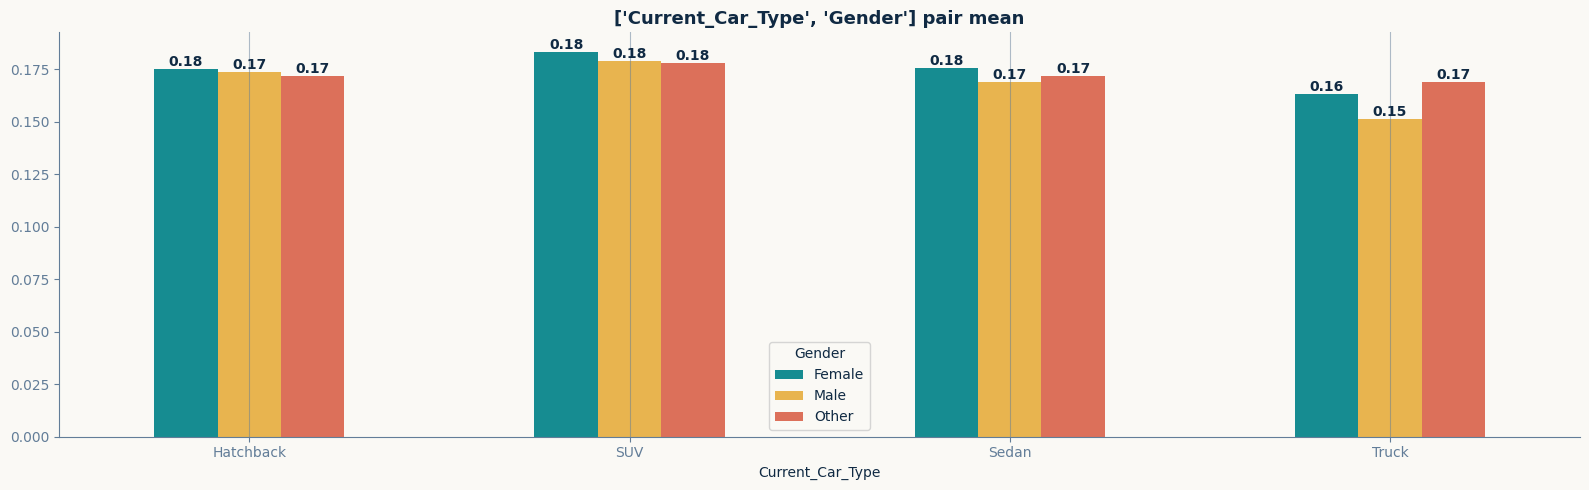


('Gender', 'Environmental_Concern_Level')| Environmental_Concern_Level has more unique variables | ['Environmental_Concern_Level', 'Gender']


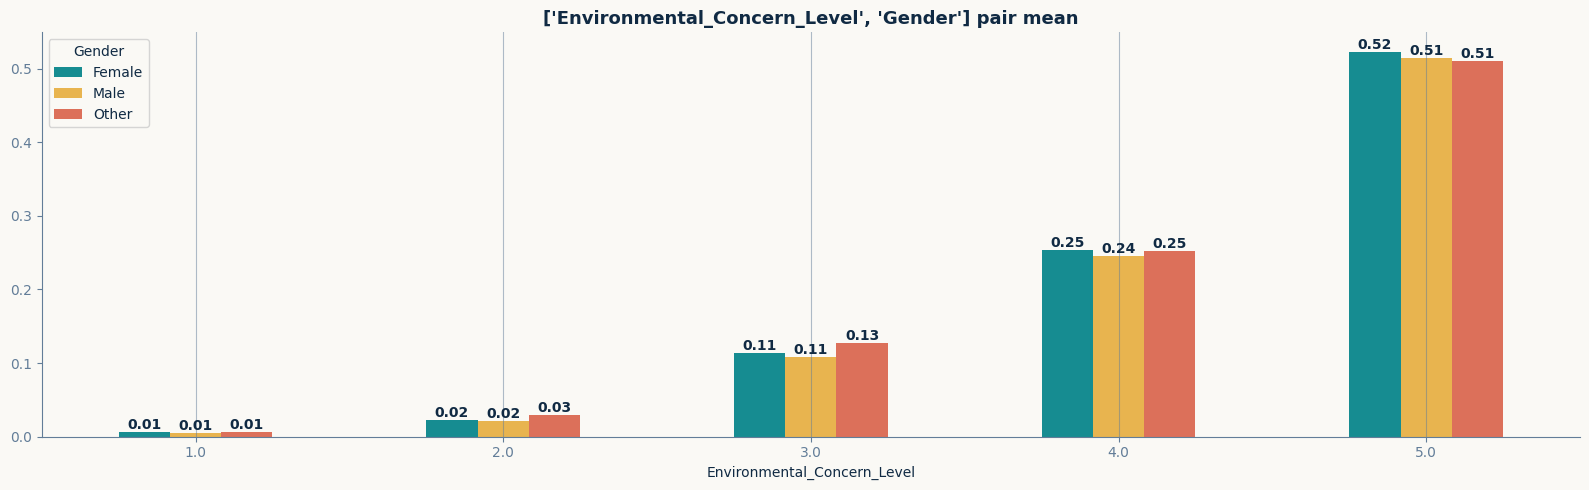


('City_Type', 'Range_Anxiety_Level')| Range_Anxiety_Level has more unique variables | ['Range_Anxiety_Level', 'City_Type']


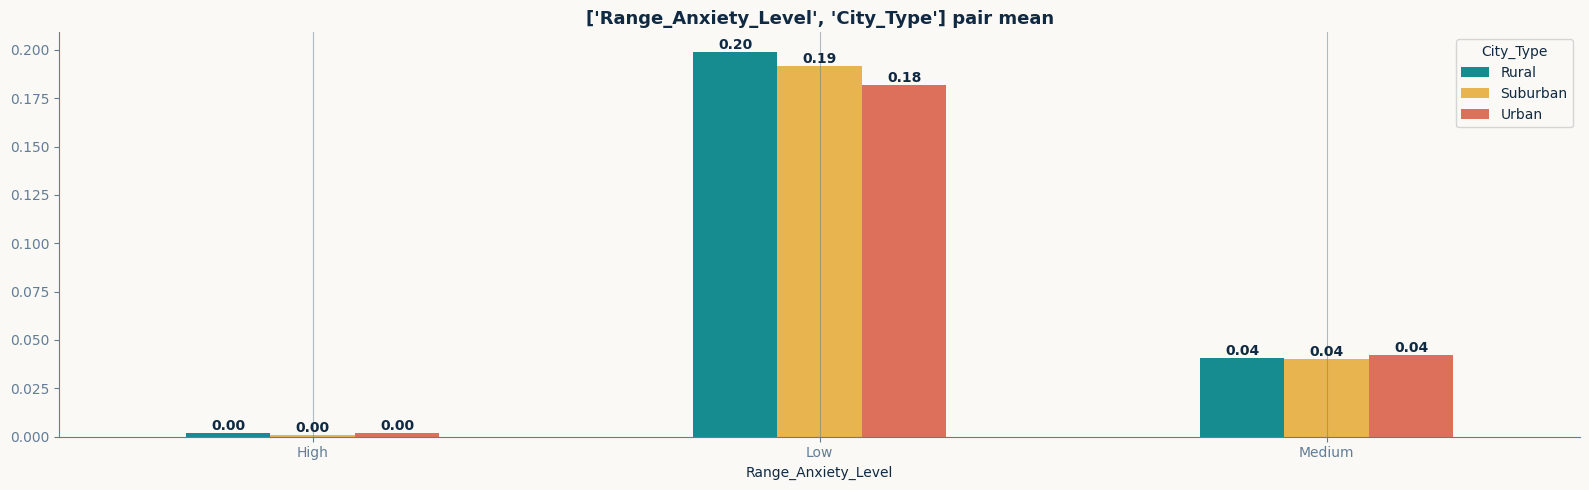


('City_Type', 'Number_of_Cars_Owned')| Number_of_Cars_Owned has more unique variables | ['Number_of_Cars_Owned', 'City_Type']


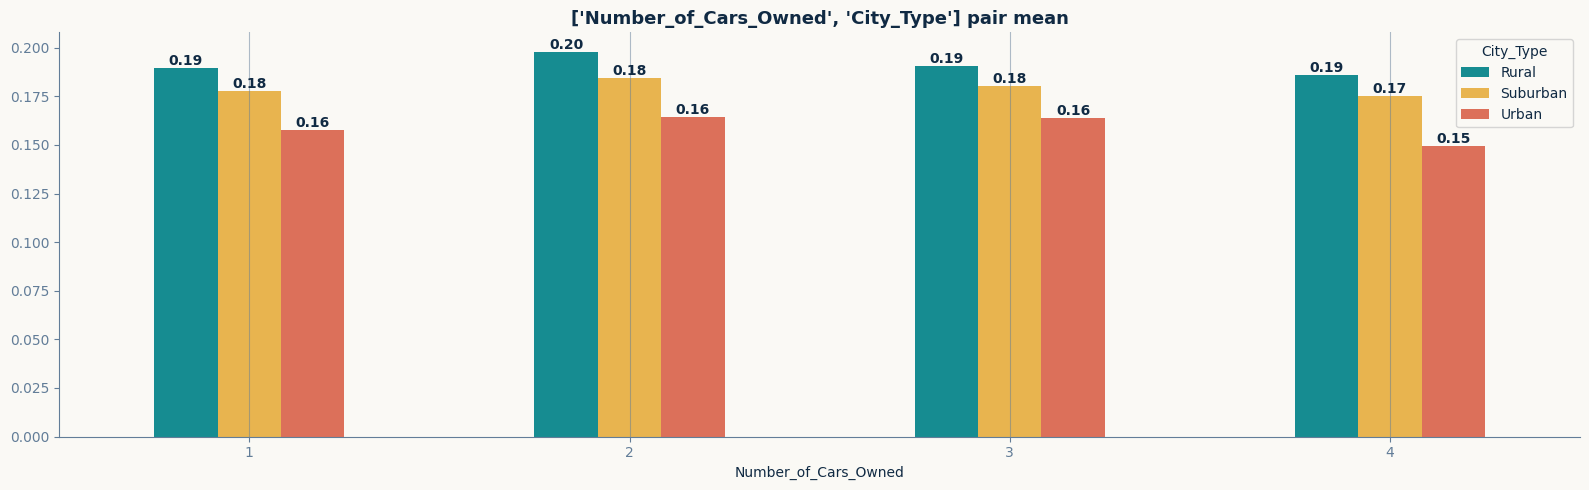


('City_Type', 'Current_Car_Type')| Current_Car_Type has more unique variables | ['Current_Car_Type', 'City_Type']


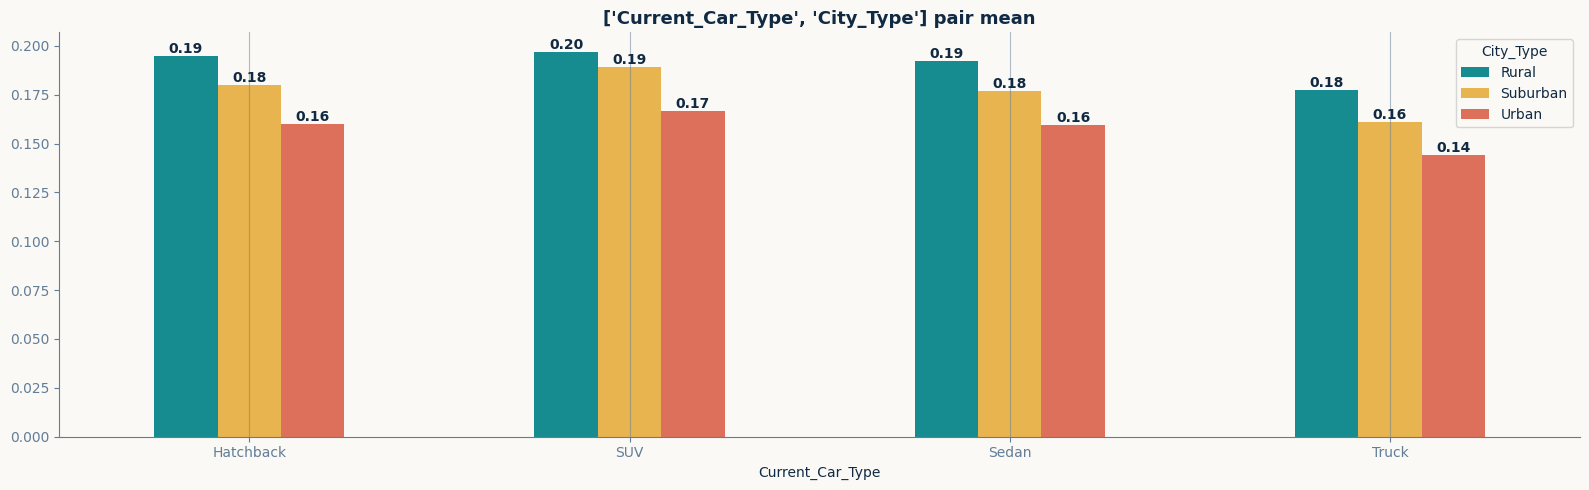


('City_Type', 'Environmental_Concern_Level')| Environmental_Concern_Level has more unique variables | ['Environmental_Concern_Level', 'City_Type']


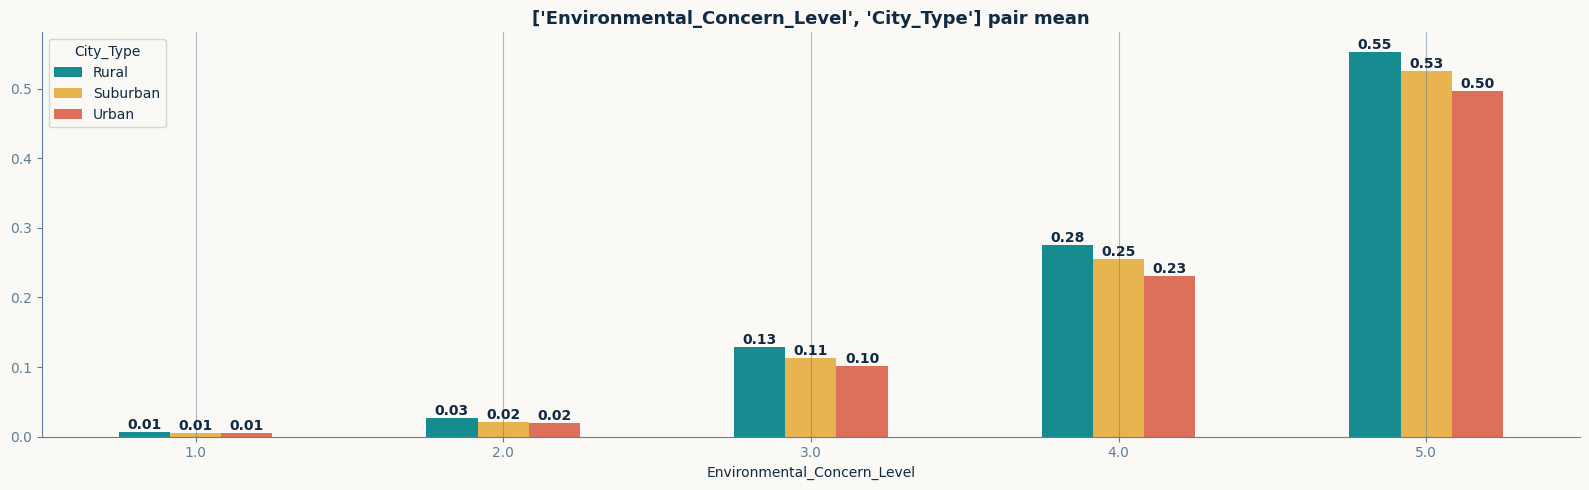


('Range_Anxiety_Level', 'Number_of_Cars_Owned')| Number_of_Cars_Owned has more unique variables | ['Number_of_Cars_Owned', 'Range_Anxiety_Level']


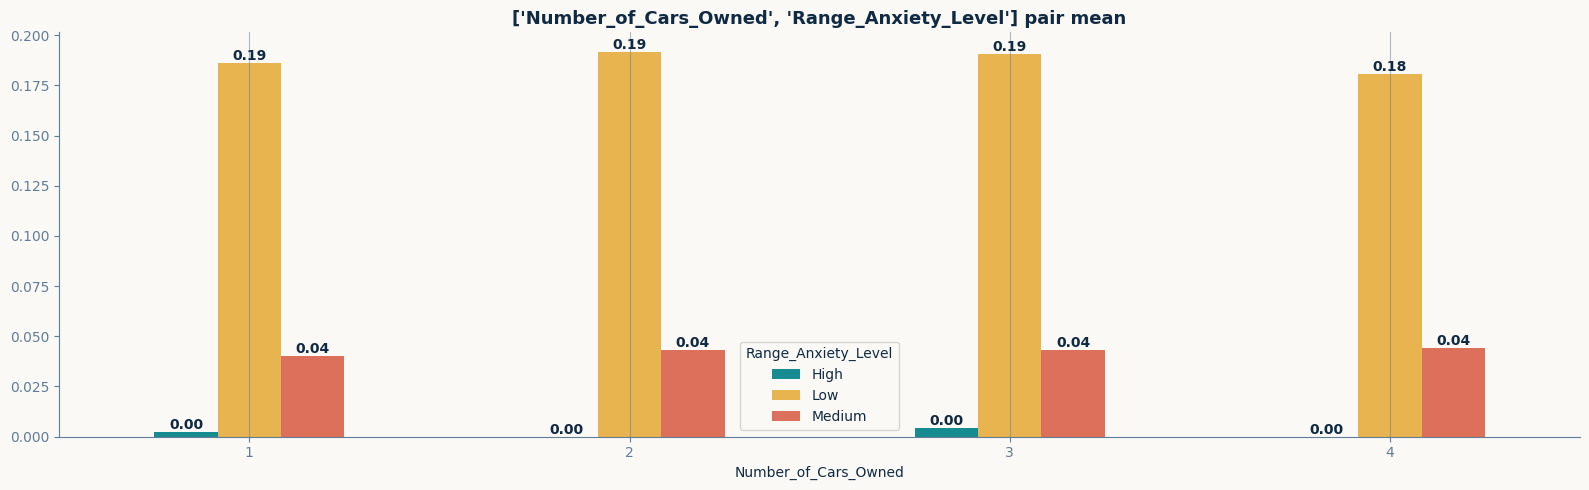


('Range_Anxiety_Level', 'Current_Car_Type')| Current_Car_Type has more unique variables | ['Current_Car_Type', 'Range_Anxiety_Level']


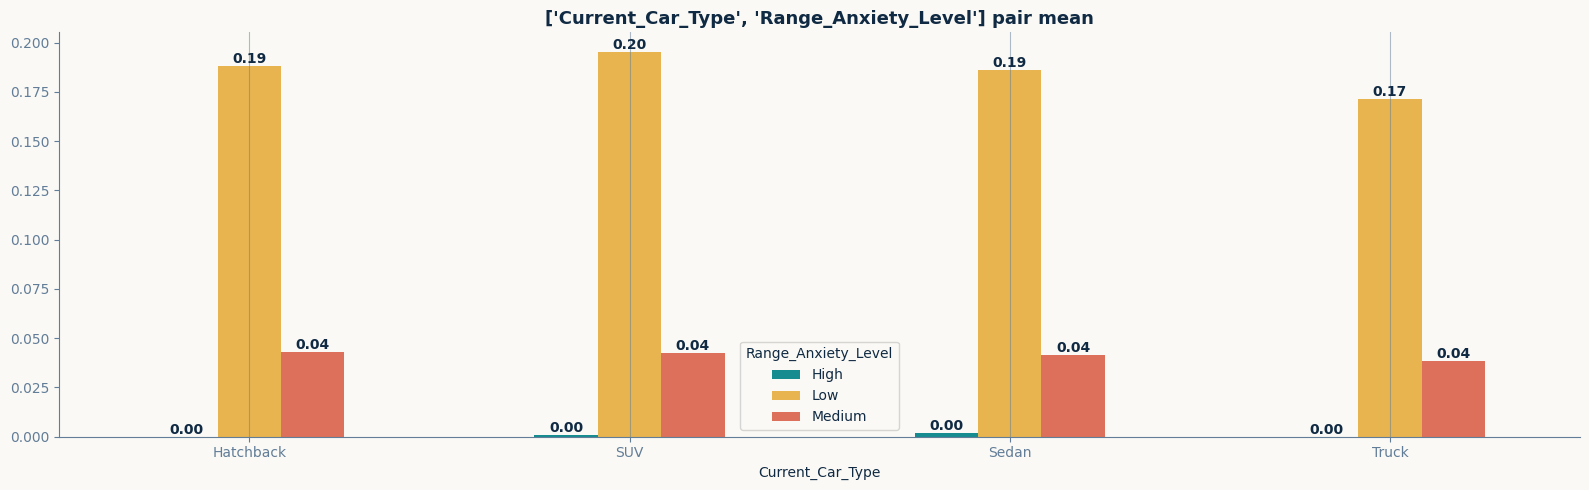


('Range_Anxiety_Level', 'Environmental_Concern_Level')| Environmental_Concern_Level has more unique variables | ['Environmental_Concern_Level', 'Range_Anxiety_Level']


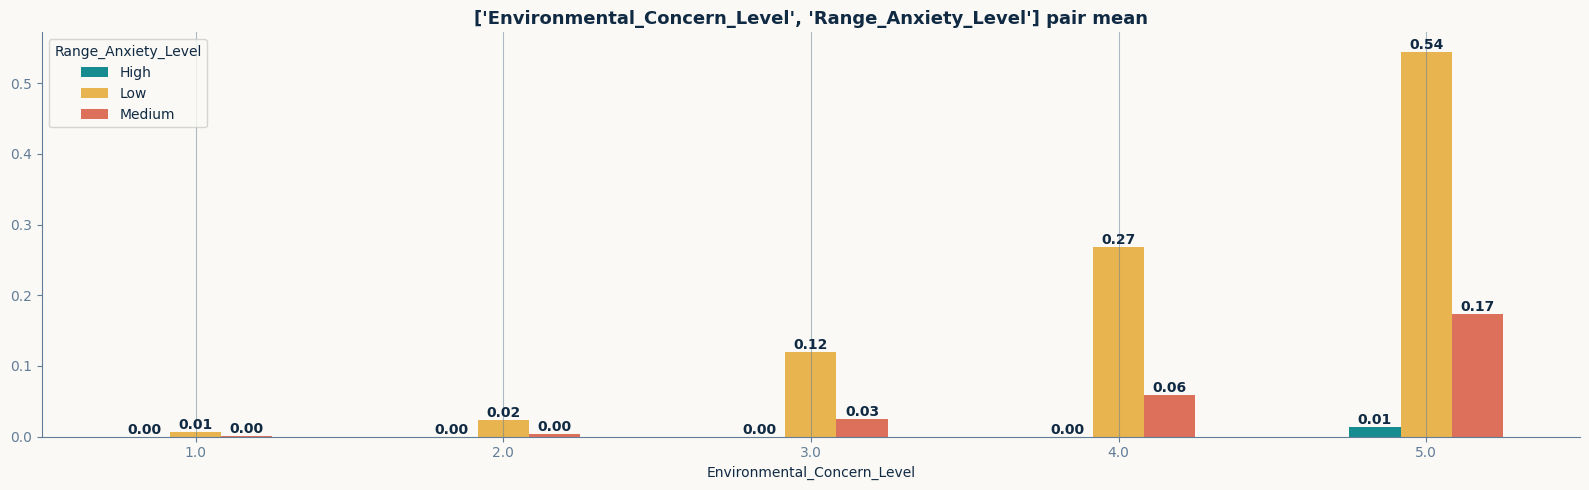


('Number_of_Cars_Owned', 'Current_Car_Type')| Current_Car_Type has more unique variables | ['Current_Car_Type', 'Number_of_Cars_Owned']


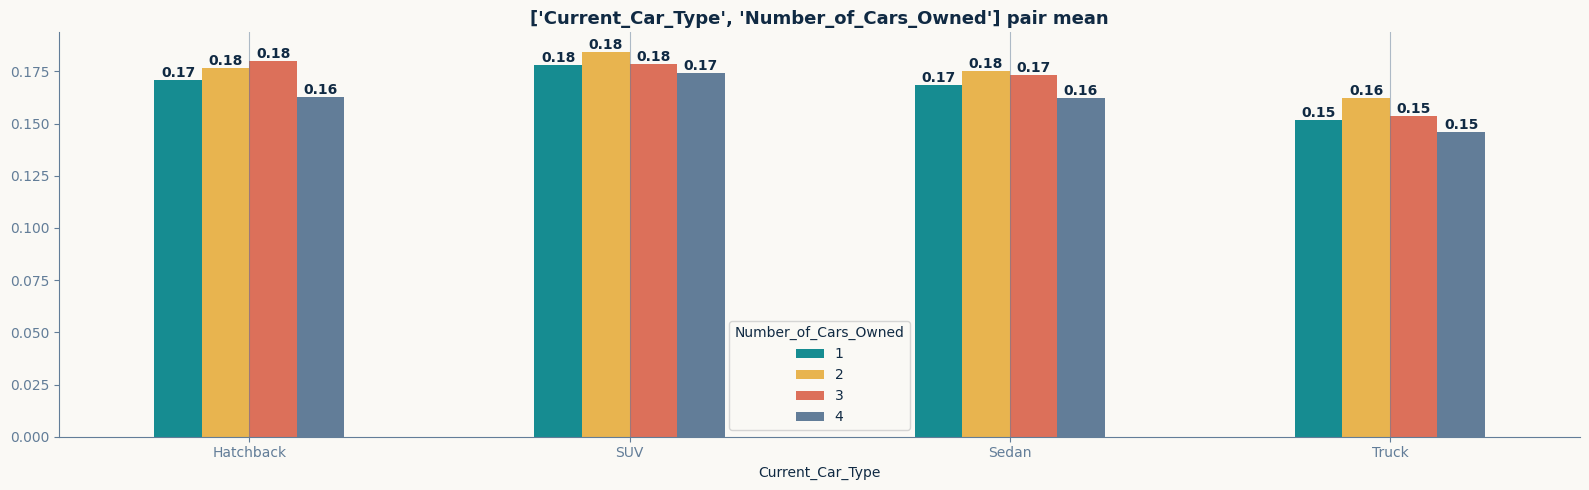


('Number_of_Cars_Owned', 'Environmental_Concern_Level')| Environmental_Concern_Level has more unique variables | ['Environmental_Concern_Level', 'Number_of_Cars_Owned']


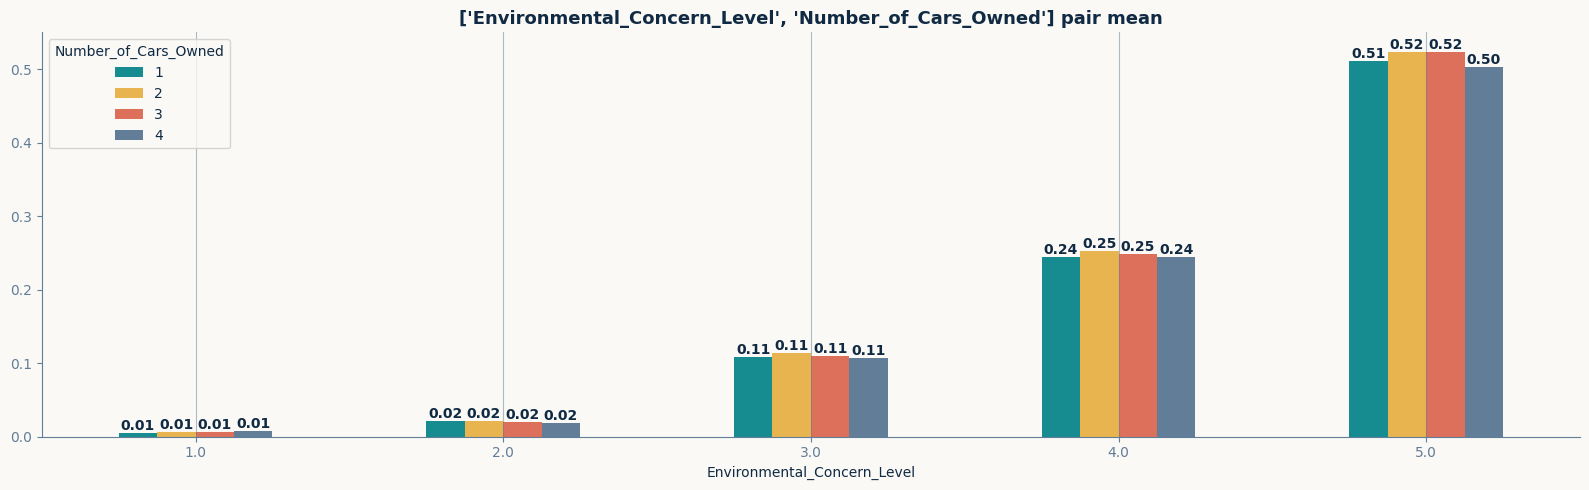


('Current_Car_Type', 'Environmental_Concern_Level')| Environmental_Concern_Level has more unique variables | ['Environmental_Concern_Level', 'Current_Car_Type']


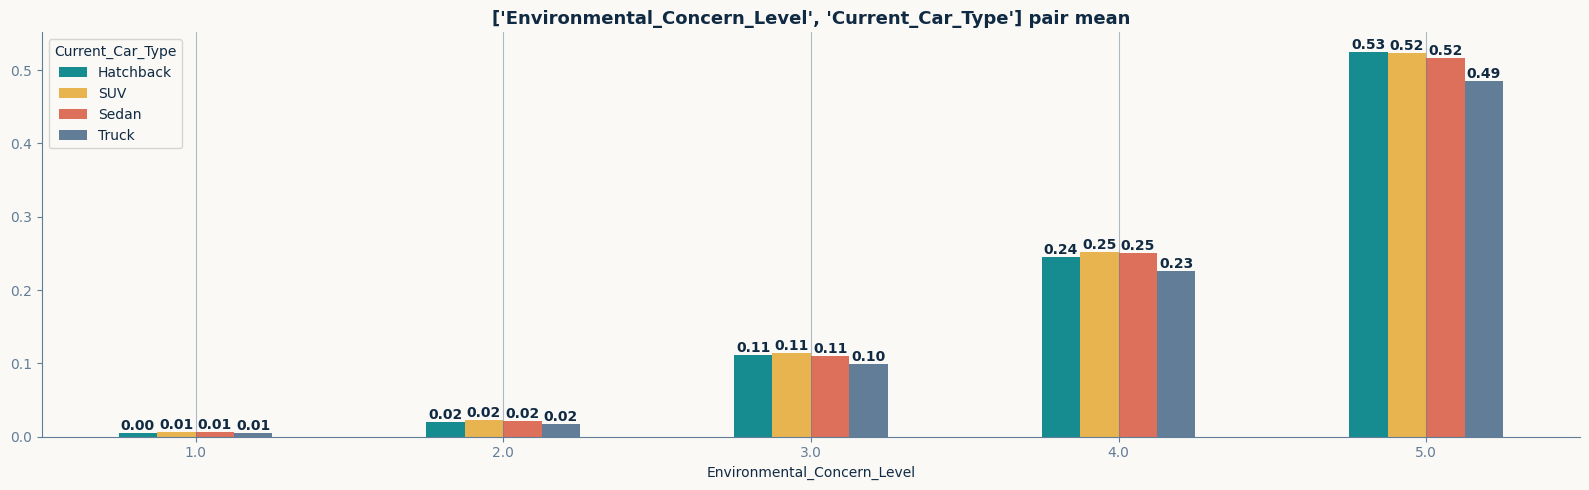

In [28]:
## -- Pairwise feature-mean (binary target) --
PAIRS = itertools.combinations(n_unique[n_unique < 10].index, 2)

for i, combo in enumerate(PAIRS):
    if train[combo[0]].nunique() > train[combo[1]].nunique():
        print(combo, end='')
        print(f'| {combo[0]} has more unique variables | ', end='')
        combo = [combo[0], combo[1]]
        print(combo)
    else:
        print(combo, end='')
        print(f'| {combo[1]} has more unique variables | ', end='')
        combo = [combo[1], combo[0]]
        print(combo)

    group_mean = train.groupby(combo)[TARGET].mean().unstack()
    ax1 = group_mean.plot.bar(figsize=(16, 5))
    ax1.set_title(f'{combo} pair mean', fontweight='semibold')
    ax1.tick_params('x', rotation=0)
    ax1.grid(axis='x')

    for container in ax1.containers: # Show values on bars
        ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

    plt.tight_layout()
    plt.show()
    print()

In [29]:
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
Gender                             3
City_Type                          3
Range_Anxiety_Level                3
Number_of_Cars_Owned               4
Current_Car_Type                   4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

In [30]:
# try:
#     from labellines import labelLines
# except:
#     !uv pip install --system matplotlib-label-lines
#     from labellines import labelLines

In [31]:
# ## -- Pairwise 'Position' against others --
# PAIRS = itertools.product(['gender'], n_unique[n_unique <= 10].index)
# PLOT_LINE = True

# for i, combo in enumerate(PAIRS):
#     # fig, axs = plt.subplots(1, 1, figsize=(15, 5), facecolor='#0f0f1a')
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(16, 5), marker='o')
#     else:
#         ax1 = group_mean.plot.bar(figsize=(16, 5))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=0)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

In [32]:
# ## -- Pairwise 'Race' against others --
# PAIRS = itertools.product(['age'], n_unique[n_unique < 10].index)
# PLOT_LINE = False

# for i, combo in enumerate(PAIRS):
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(18, 8))
#     else:
#         ax1 = group_mean.plot.bar(figsize=(18, 8))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=90)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

In [33]:
# ## -- Pairwise 'Position_Change' against others --
# PAIRS = itertools.product(['stress_level'], n_unique[n_unique < 10].index)
# PLOT_LINE = True

# for i, combo in enumerate(PAIRS):
#     # fig, axs = plt.subplots(1, 1, figsize=(15, 5), facecolor='#0f0f1a')
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(16, 5), marker='o')
#     else:
#         ax1 = group_mean.plot.bar(figsize=(16, 5))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=0)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

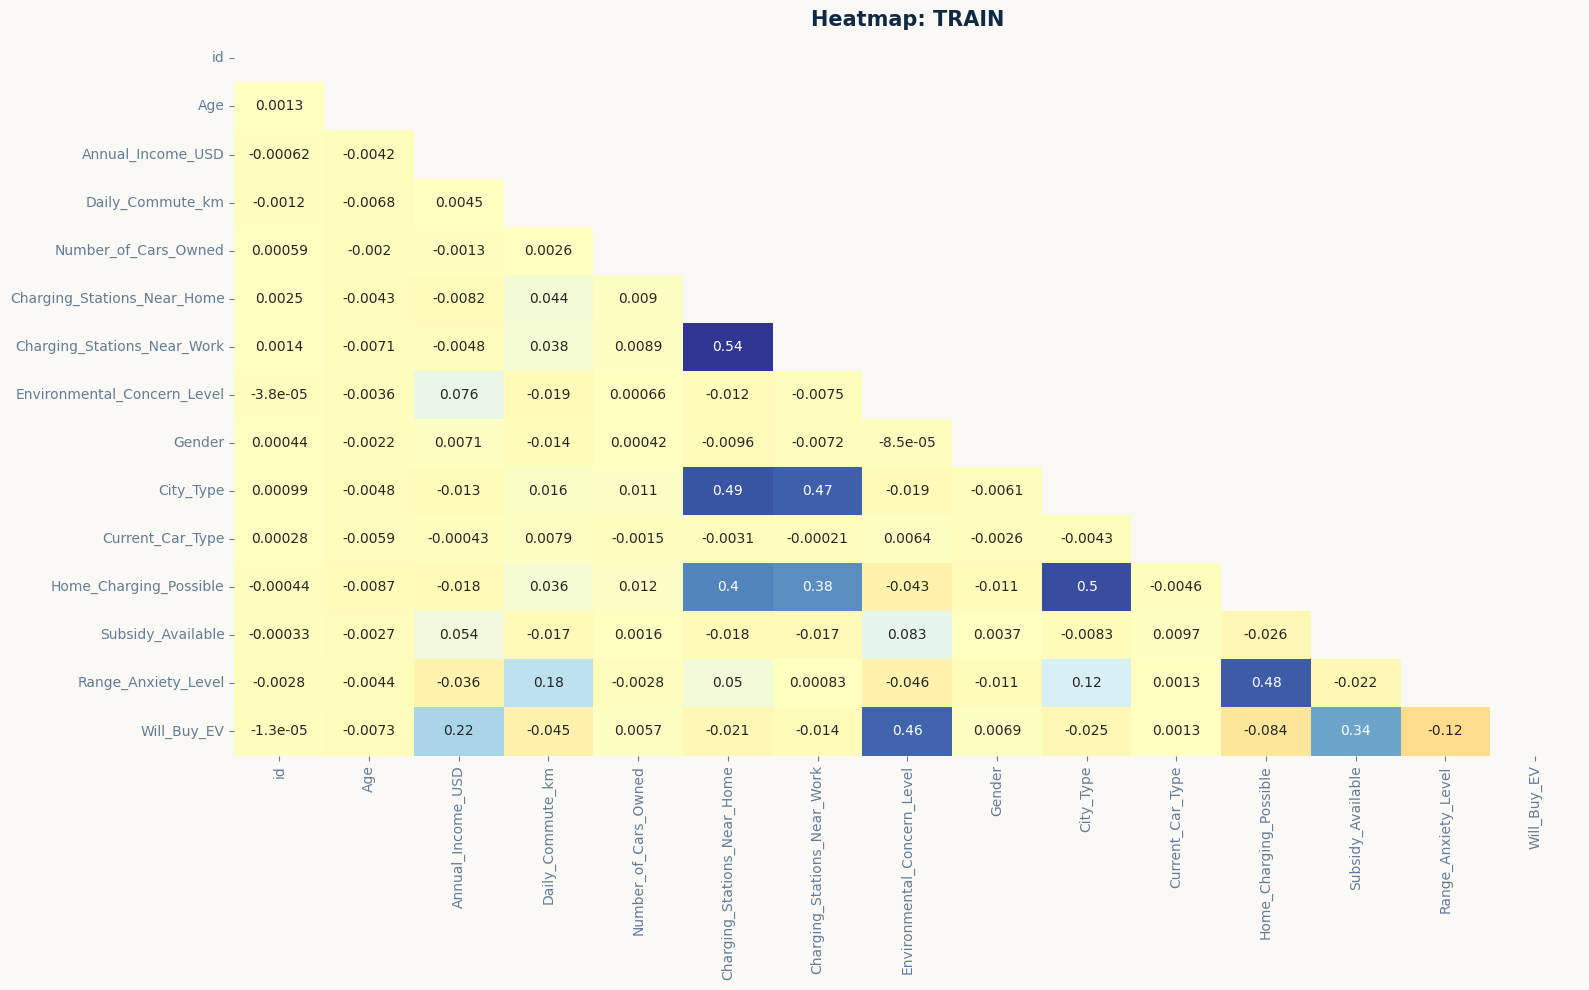

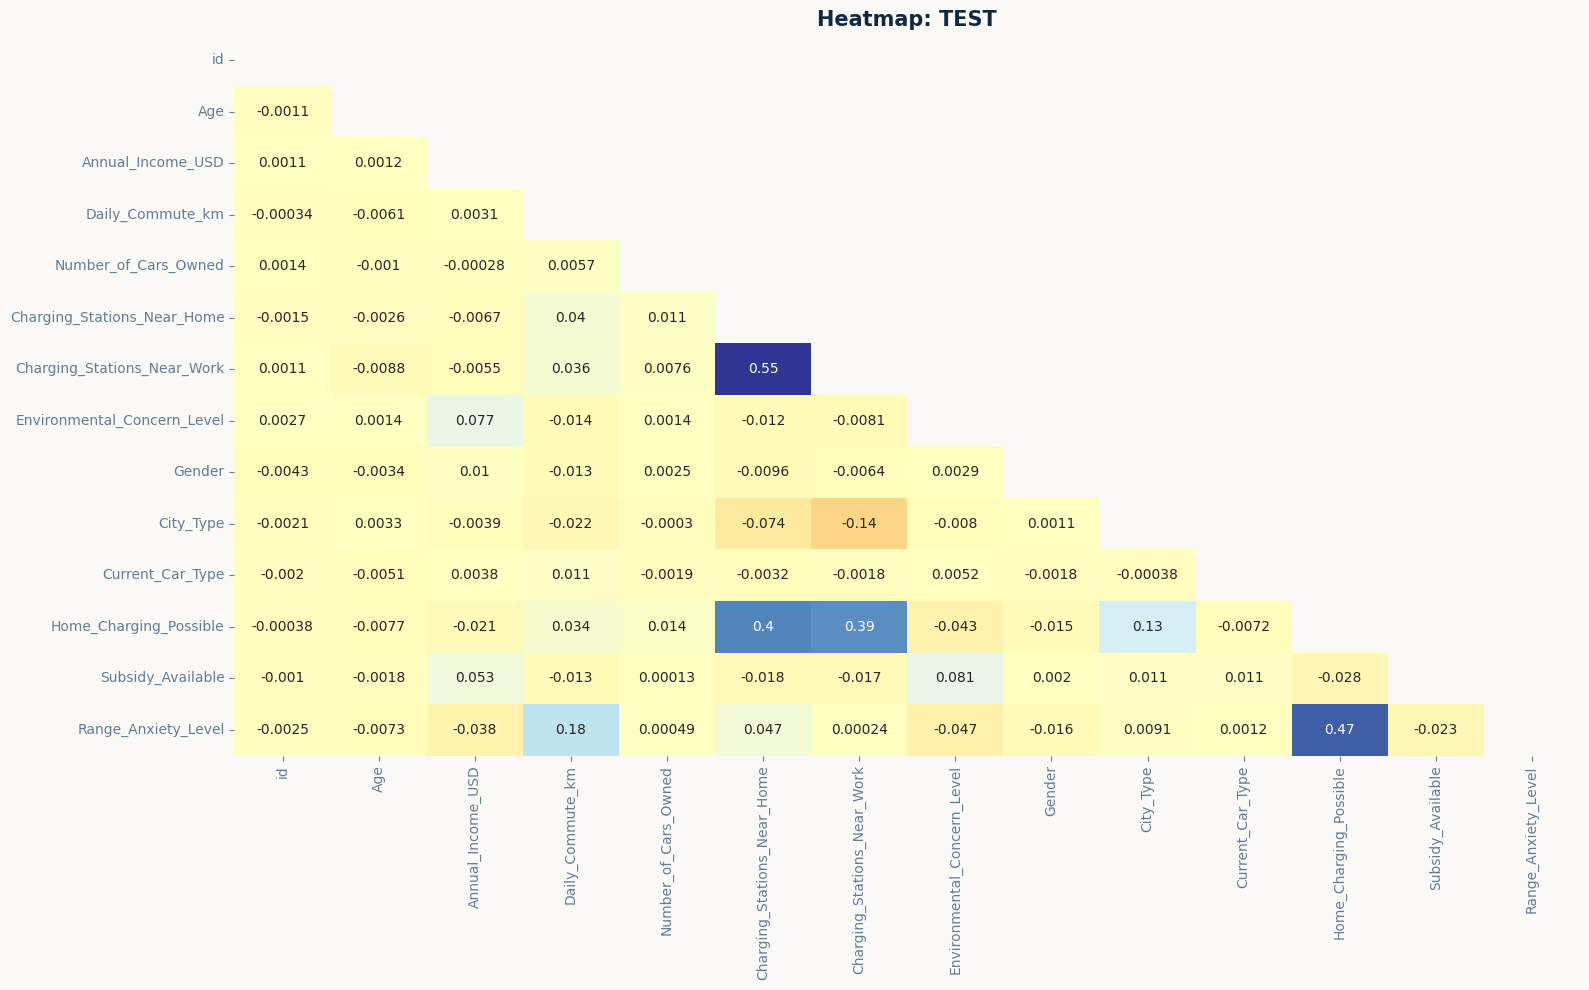

In [34]:
def plot_heatmap(df_, name='Data'):
    df = df_.copy()
    cat_cols = [c for c in df.columns if df[c].dtype in ['str', 'object', 'category']]
    for c in cat_cols:
        df[c] = pd.factorize(df[c])[0]

    CORR = df.corr('spearman')
    plt.figure(figsize=(16, 10))
    sns.heatmap(CORR, mask=np.triu(CORR), annot=True, cmap='RdYlBu', cbar=False, center=0)
    plt.title(f"Heatmap: {name}", fontdict={'size':15, 'weight': 'semibold'})
    plt.tight_layout()
    plt.show()

    del df

plot_heatmap(train, 'TRAIN')
# plot_heatmap(orig, 'ORIGINAL')
plot_heatmap(test, 'TEST')

In [35]:
# ## -- VIOLIN PLOT --
# plt.figure(figsize=(18, 5))
# for i, col in enumerate(NUMS):
#     plt.subplot(1, len(NUMS), i+1)
#     sns.violinplot(train[col])

# plt.tight_layout()
# plt.show()

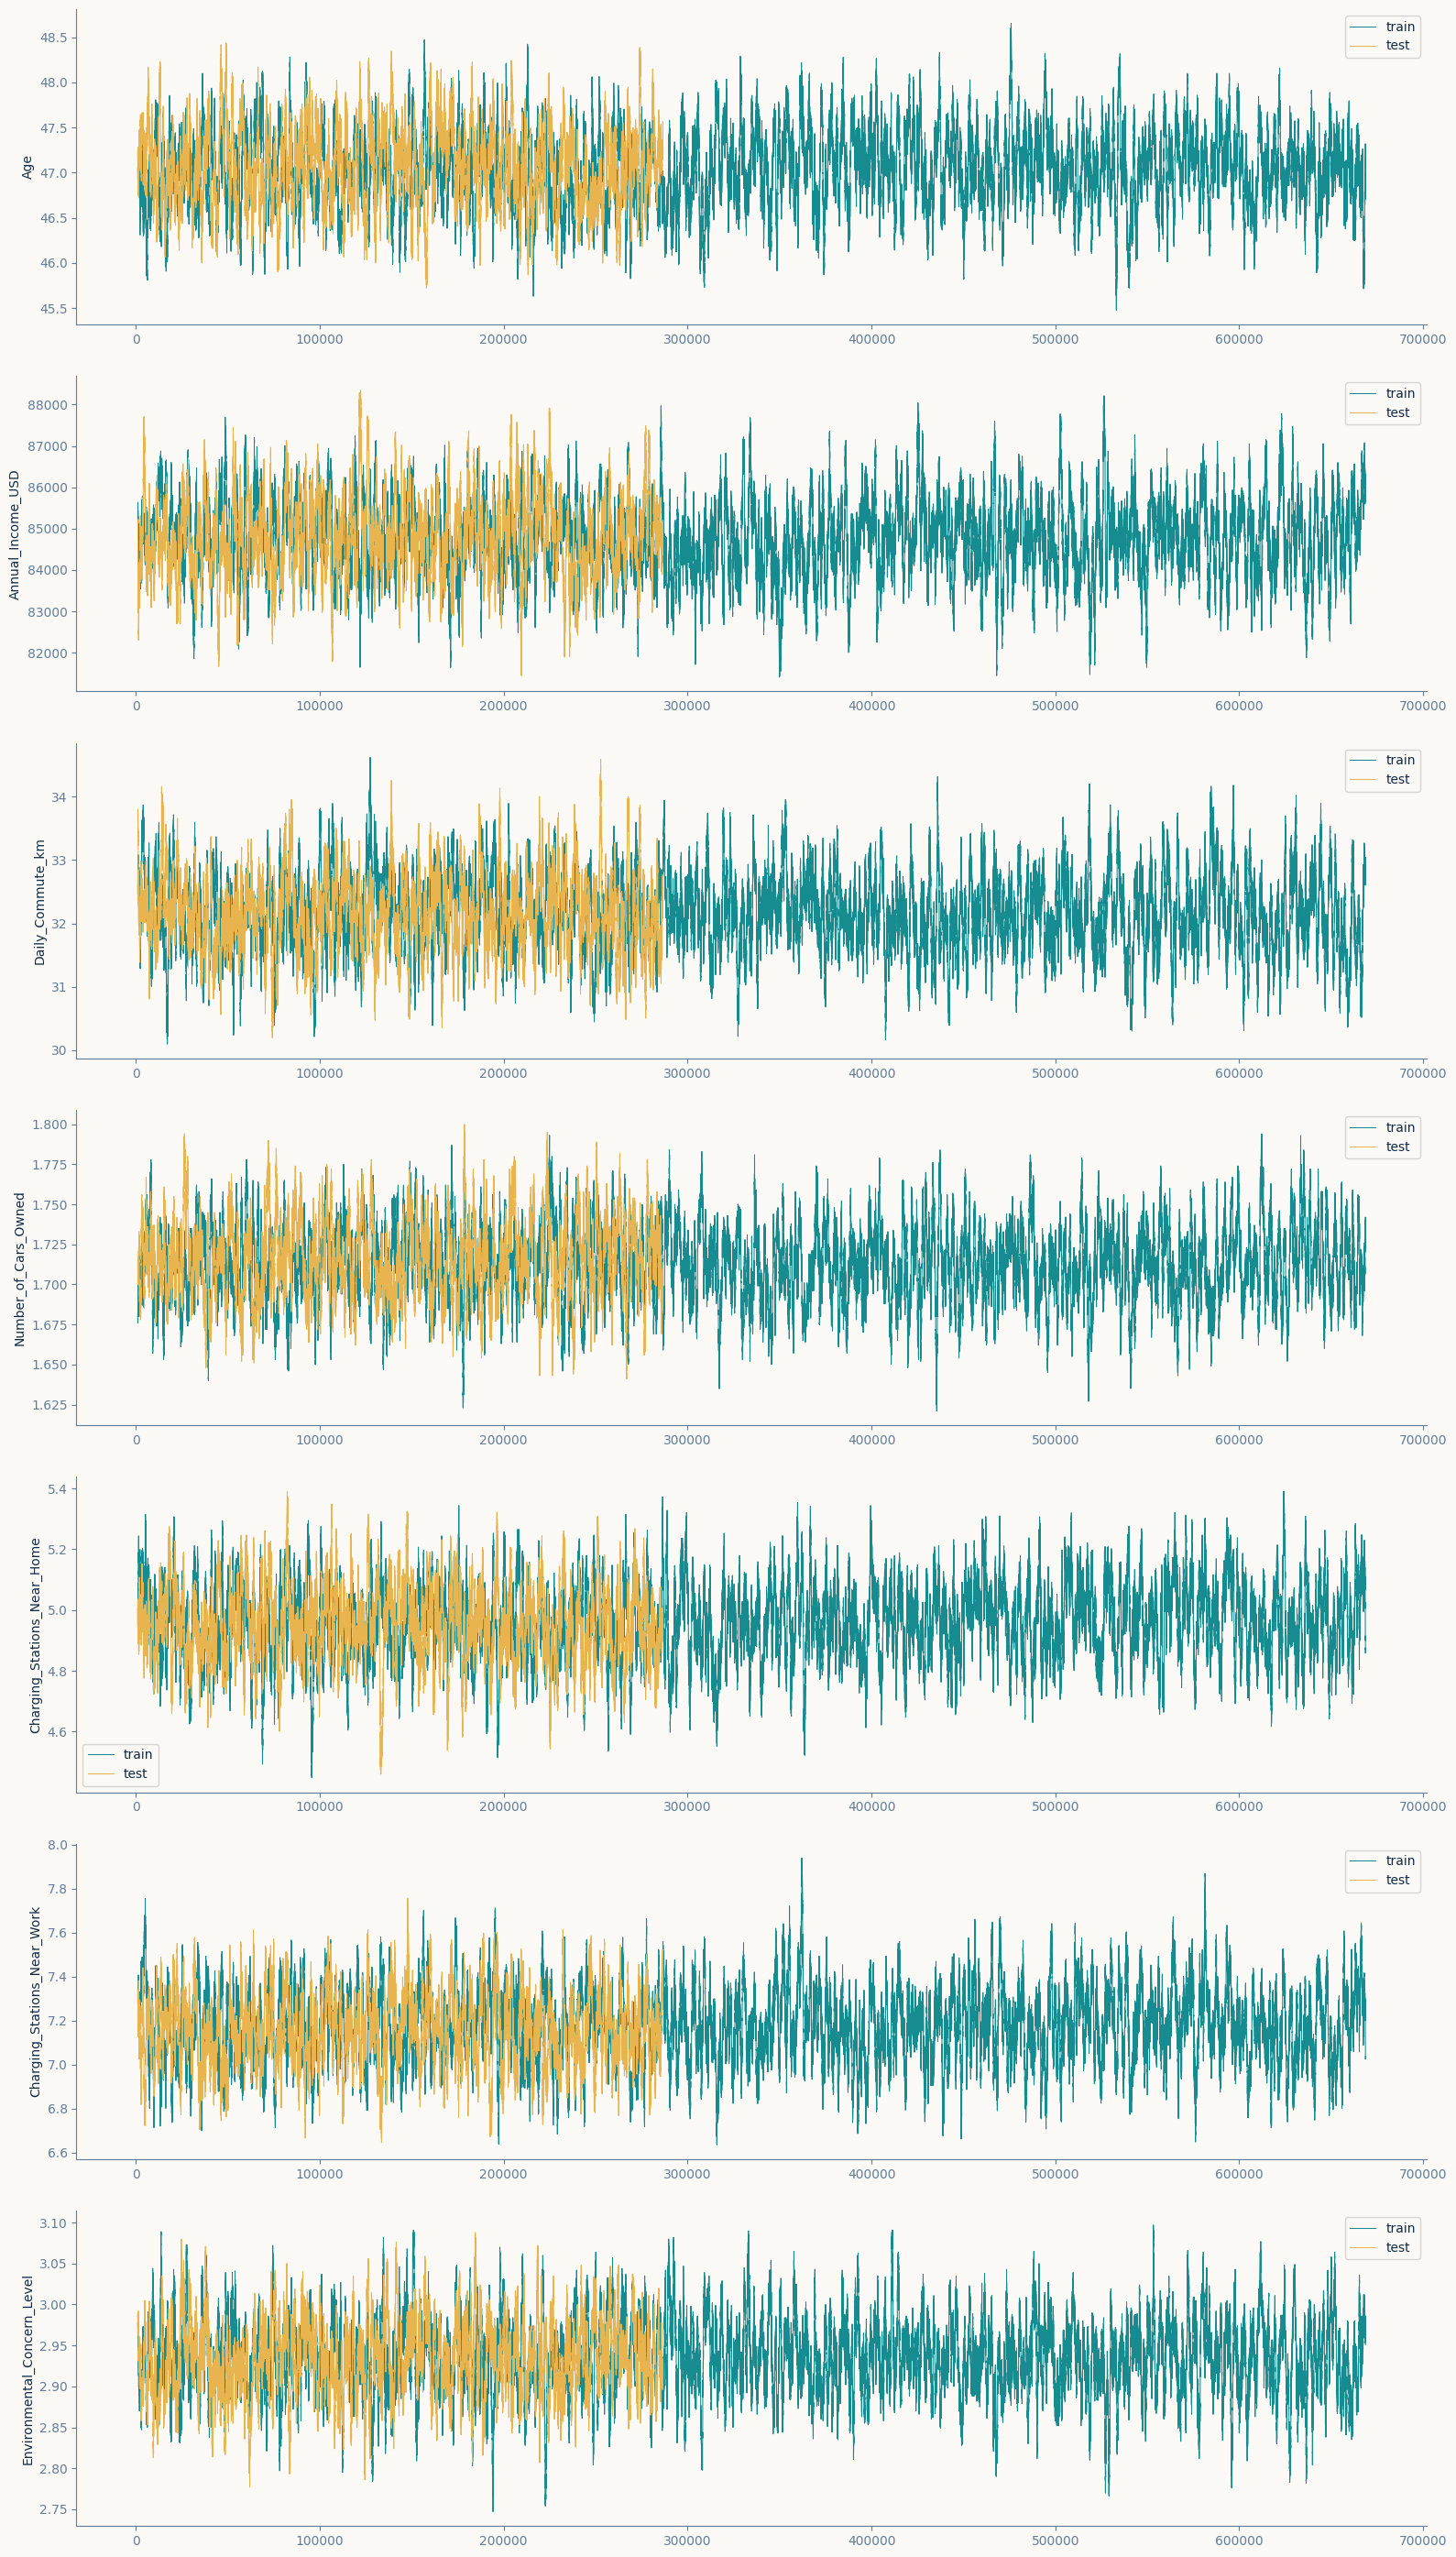

In [36]:
## -- Drift check--
rolling = 1000
line_w = 0.75

plt.figure(figsize=(16, len(NUMS) * 4))
for i, col in enumerate(NUMS):
    plt.subplot(len(NUMS), 1, i + 1)
    sns.lineplot(train[col].rolling(rolling).mean(), linewidth=line_w, label='train')
    sns.lineplot(test[col].rolling(rolling).mean(),  linewidth=line_w, label='test')
    # sns.lineplot(orig[col].rolling(1000).mean(),  linewidth=line_w, label='orig')

plt.legend()
plt.tight_layout(h_pad=2)
plt.show()

In [37]:
# %%time

# ## -- FEATURE MUTUAL INFO --
# mutual_info = mutual_info_regression(train[BASE], train[TARGET])
# mutual_info_df = pd.DataFrame.from_dict(
#     dict(zip(test.columns.tolist(), list(mutual_info))),
#     orient='index', columns=['Score'],
# ).sort_values(by='Score', ascending=False)

# plt.figure(figsize=(18, 8))
# sns.barplot(data=mutual_info_df, x='Score', y=mutual_info_df.index)
# plt.title('-- Univariate Analysis: Top predictors --')
# plt.show()

## 1. Kolmogorov-Smirnov (K-S) Drift check

In [38]:
from scipy.stats import ks_2samp

def ks_driftcheck(df_1, df_2, df2_mame: str, features):
    df_train = df_1.copy()
    df_test  = df_2.copy()

    ks_stats_all = []
    cols = []
    threshold = 0.05

    print(f"{'feature':>25}\t{'ks-stat':>10}\t{'drift'}")
    print(f"{'-'*20:>25}\t{'-------':>10}\t{'-------'}")
    RED = '\033[33m'
    for c in features:
        ks_stat, p_val = np.round(ks_2samp(df_train[c].values, df_test[c].values), 6)
        if ks_stat >= threshold:
            print(f"{CFG['YELLOW']}{c:>25}\t{ks_stat:>10}\t⚠️ Drift{CFG['RESET']}")
        else:
            print(f"{c:>25}\t{ks_stat:>10}\t✅ Safe!")

        ks_stats_all.append(ks_stat)
        cols.append(c)

    print()
    plt.barh(cols, ks_stats_all, color=[CRIM if c >= threshold else MUTED for c in ks_stats_all])
    plt.axvline(x=threshold, linestyle="--", color=GOLD, label=f"Drift threshold: {threshold}")
    plt.title(f"(K-S) drift test: Train vs {df2_mame}", loc="left", pad=26)
    plt.legend()
    plt.show()

    gc.collect()

                  feature	   ks-stat	drift
     --------------------	   -------	-------
                      Age	  0.002293	✅ Safe!
        Annual_Income_USD	  0.001639	✅ Safe!
         Daily_Commute_km	  0.001067	✅ Safe!
     Number_of_Cars_Owned	   0.00166	✅ Safe!
Charging_Stations_Near_Home	  0.001579	✅ Safe!
Charging_Stations_Near_Work	  0.003005	✅ Safe!
Environmental_Concern_Level	  0.001271	✅ Safe!
                   Gender	    0.0002	✅ Safe!
                City_Type	  0.001347	✅ Safe!
         Current_Car_Type	   0.00075	✅ Safe!
   Home_Charging_Possible	  0.000662	✅ Safe!
        Subsidy_Available	  0.001455	✅ Safe!
      Range_Anxiety_Level	  0.001711	✅ Safe!



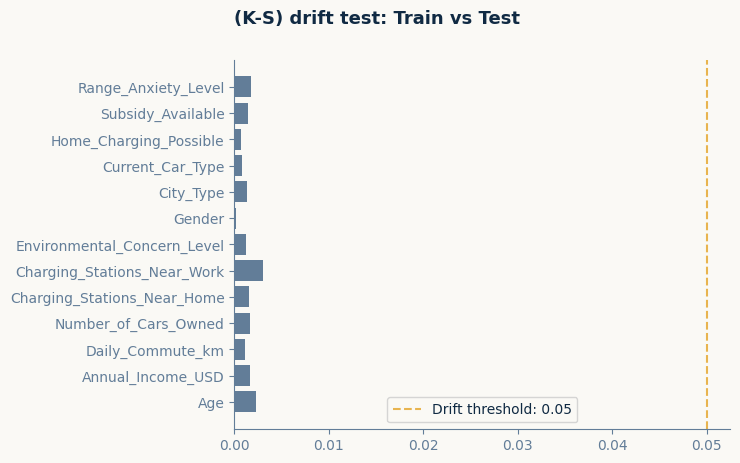

In [39]:
## -- Drift test for TRAIN & TEST --
ks_driftcheck(train, test, "Test", BASE)

In [40]:
# ## -- Drift test for TRAIN & ORIGINAL --
# ks_driftcheck(train, orig, "Original", BASE+[TARGET])

In [41]:
# try:
#     from evidently import Dataset, DataDefinition, Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset
# except:
#     !uv pip install --system evidently
#     from evidently import Dataset, DataDefinition, Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset

# def evid_driftcheck(df_1, df_2, features, nums, cats):

#     schema = DataDefinition(
#         numerical_columns=nums,
#         categorical_columns=cats,
#         # classification=[BinaryClassification(target="target", prediction_labels="prediction")]
#     )

#     train_df = Dataset.from_pandas(df_1[features], data_definition=schema)
#     test_df  = Dataset.from_pandas(df_2[features], data_definition=schema)

#     report   = Report([DataDriftPreset()])
#     my_eval  = report.run(train_df, test_df)

#     return my_eval

# print("evidently drift check function ready!")

In [42]:
# ## -- Drift: 'train' & 'test' datasets --
# drift_train_test = evid_driftcheck(train, test, BASE, NUMS, CATS)
# display(drift_train_test)

In [43]:
# ## -- Drift: 'train' & 'orig' datasets --
# drift_train_orig = evid_driftcheck(train, orig, BASE, NUMS, CATS)
# display(drift_train_orig)

## 2. Permutation Importances

In [44]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test, plot_bar=False):
    model_importances = pd.Series(
        model.feature_importances_, 
        index=X_test.columns,
    ).sort_values()

    ## -- Compute Permutation Importances --
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        # sample_weight=get_weights(y_test, y),
        scoring="roc_auc",
        random_state=0,
        #n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print("Complete!")

    fig, axs = plt.subplots(1, 2, figsize=(16, len(model_importances)*0.5))

    model_importances.plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")

    perm_df = pd.Series(
        result.importances_mean[perm_sorted_idx],
        index=X_test.columns[perm_sorted_idx],
    )

    if plot_bar:
        perm_df.plot.barh(ax=axs[1])
    else:
        axs[1].boxplot(
            result.importances[perm_sorted_idx].T,
            tick_labels=X_test.columns[perm_sorted_idx],
            orientation="horizontal", whis=(0, 100)
        )

    axs[1].axvline(x=0, linestyle="--", color=CRIM)
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("XGB impurity-based - vs - Permutation on valid data")
    _ = fig.tight_layout()
    plt.show()

    return perm_df

print("Permutation function ready!")

Permutation function ready!


Base model training... Complete!
Permutation training... Complete!


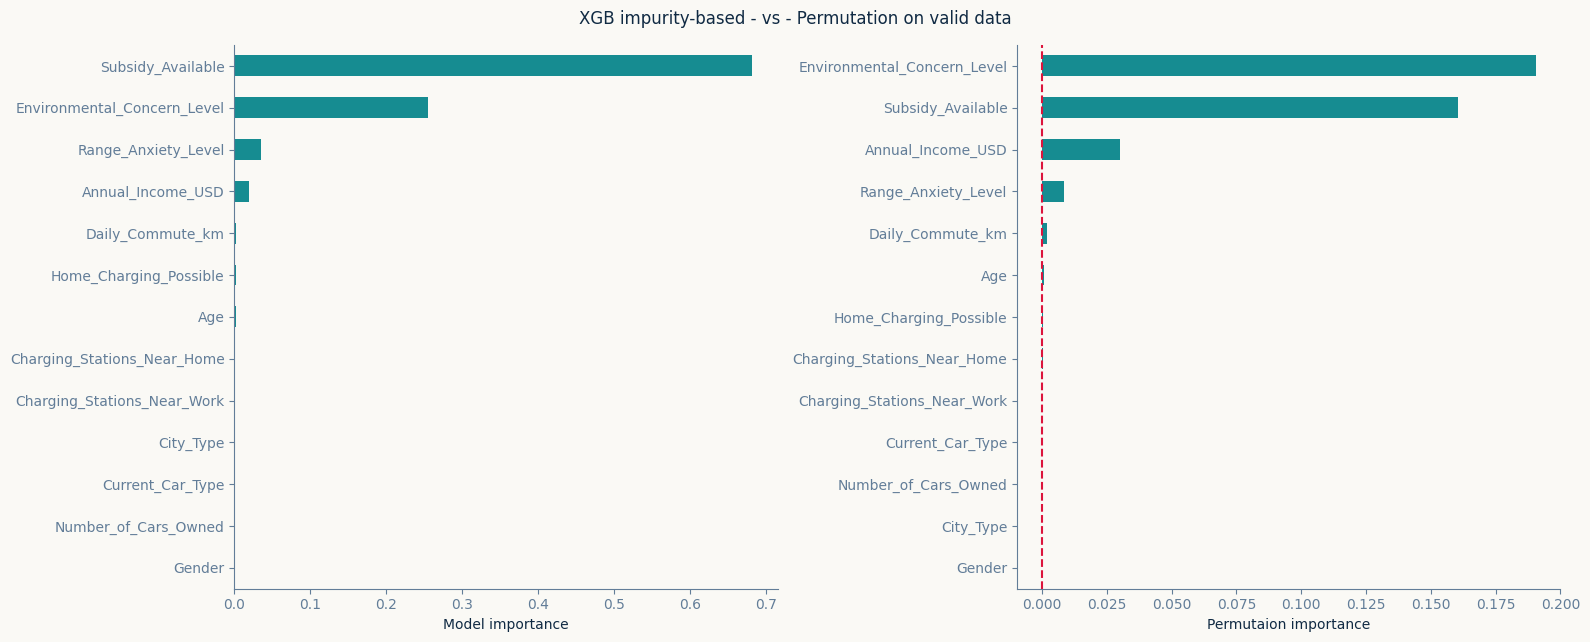

CPU times: user 2min 20s, sys: 118 ms, total: 2min 20s
Wall time: 1min 16s


In [45]:
%%time

X = train[BASE]
y = train[TARGET]

for c in CATS:
    X[c] = X[c].factorize()[0]
    X[c] = X[c].astype("category")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

## -- Compute Model Importances --
print("Base model training... ", end="")
params = {
    'objective': "binary:logistic",
    'eval_metric': 'auc',
    'subsample': 0.8,
    'colsample_bytree': 0.4,
    'enable_categorical': True,
    'importance_type': "gain",
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': -1,
    'device': "cuda" if torch.cuda.is_available() else "cpu",
}

xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)
print("Complete!")

print("Permutation training... ", end="")
perm_df = plot_permutation_importance(xgb_model, X_test, y_test, plot_bar=True)

## 2. SHAP VALUES

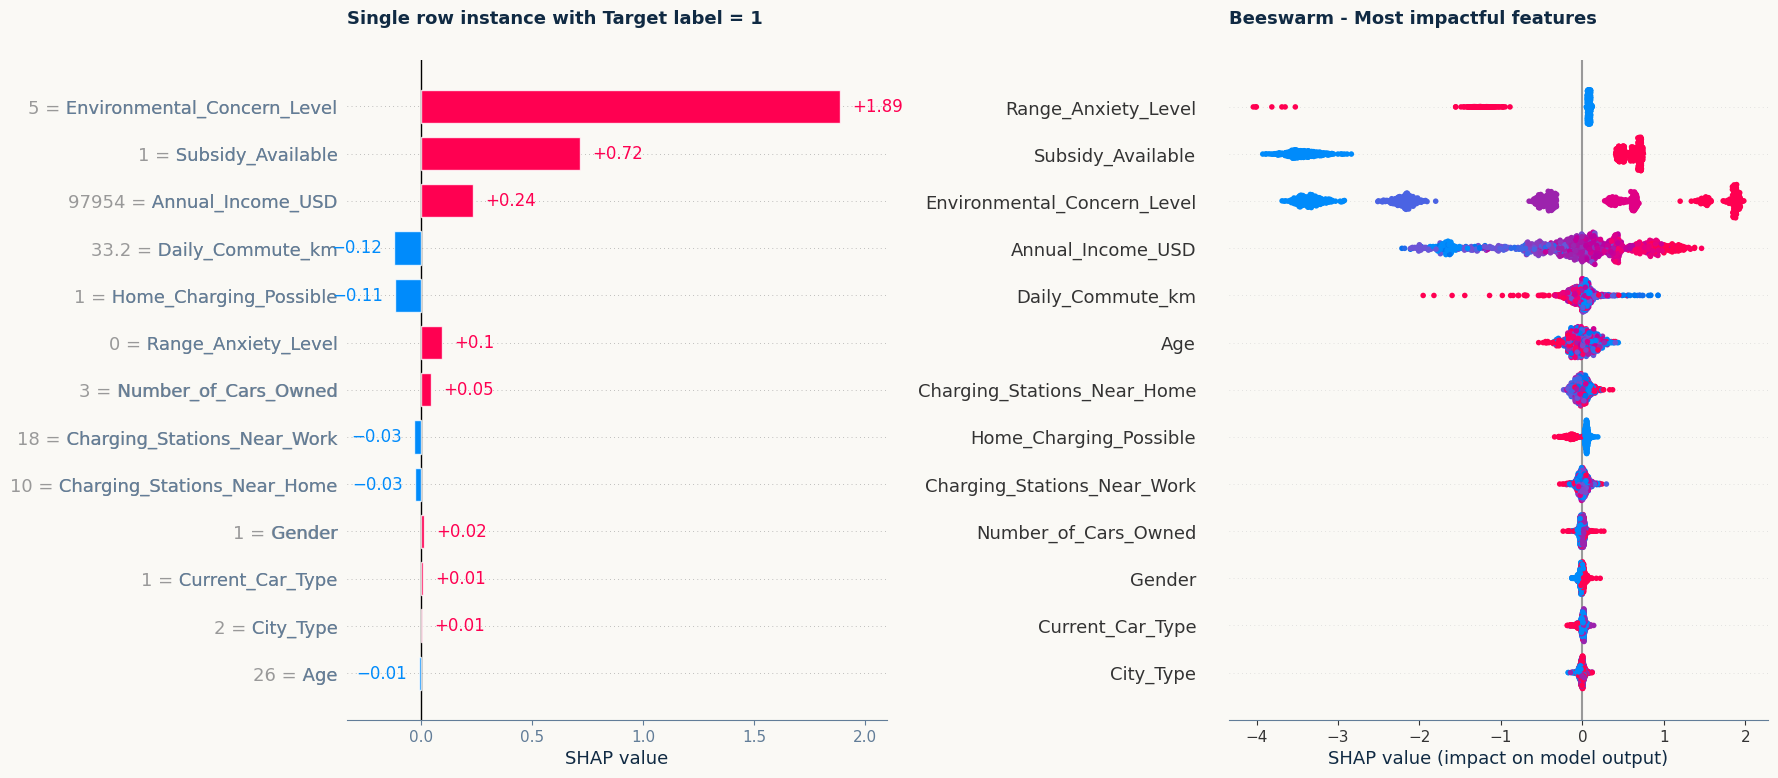

In [46]:
try:
    import shap
except:
    !uv pip install --system shap
    import shap

shap.initjs()

## -- Plot SHAP values --
idx = X_test.sample(1000, random_state=0).index
MAX      = 20
INSTANCE = -1

explainer = shap.TreeExplainer(xgb_model)
explanation = explainer(X_test.loc[idx])

## -- Bar plot --
plt.subplot(121)
shap.plots.bar(explanation[INSTANCE], max_display=MAX, show=False)
plt.title(f"Single row instance with Target label = {y_test.loc[idx].iloc[INSTANCE]}", loc="left", pad=26)

## -- Beeswarm plot --
plt.subplot(122)
shap.plots.beeswarm(
    explanation,
    max_display=MAX,
    order=explanation.abs.max(0),
    plot_size=(18, 8),
    color_bar=False,
    show=False,
)

plt.title("Beeswarm - Most impactful features", loc="left", pad=26)
# plt.suptitle(f"XGBoost shap values : Feature impact on model predictions",
#              fontweight="bold", fontsize=15, color=CRIM)

plt.tight_layout(pad=1.5)
plt.show()

shap.plots.force(explanation[INSTANCE], feature_names=BASE, contribution_threshold=0.1)

In [47]:
## -- Plot SHAP values --
from __future__ import annotations

try:
    import shapiq
except:
    !uv pip install --system shapiq
    import shapiq

explainer = shapiq.TreeExplainer(model=xgb_model, index="k-SII", min_order=1, max_order=3)
explanation = explainer.explain(X_test.loc[idx].iloc[INSTANCE].values, budget=1024, random_state=0)

print("\n", explanation)

Using Python 3.12.13 environment at: /usr
Resolved 27 packages in 533ms
Prepared 2 packages in 459ms
Installed 2 packages in 11ms
 + colour==0.1.5
 + shapiq==1.7.0

 InteractionValues(
    index=k-SII, max_order=3, min_order=1, estimated=False, estimation_budget=None,
    n_players=13, baseline_value=-1.767307072877884,
    Top 10 interactions:
        (6,): 1.7610006239050189
        (11,): 0.6074138513557177
        (1,): 0.4107637609895987
        (6, 11): 0.2218143832625625
        (0,): 0.17283564311261362
        (12,): 0.08405442884320778
        (2, 10): 0.08305636685567604
        (10,): -0.12560427249529177
        (0, 1): -0.16487656627741587
        (0, 1, 2): -0.3649812333672197
)


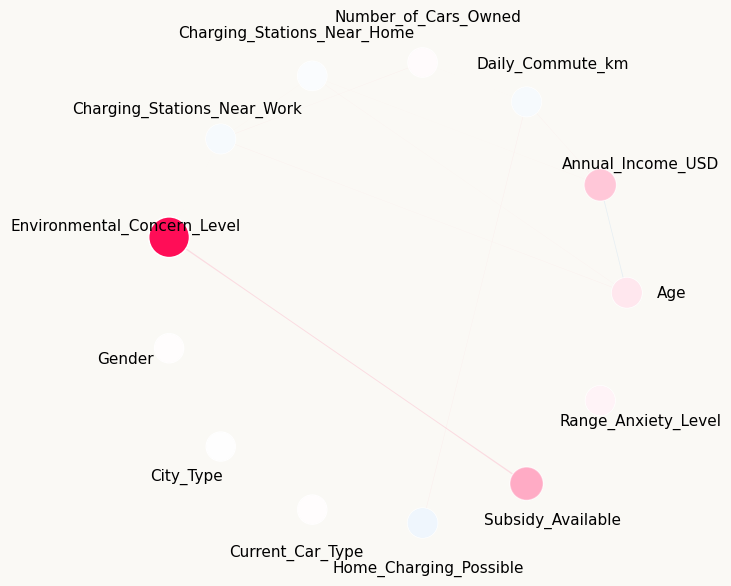

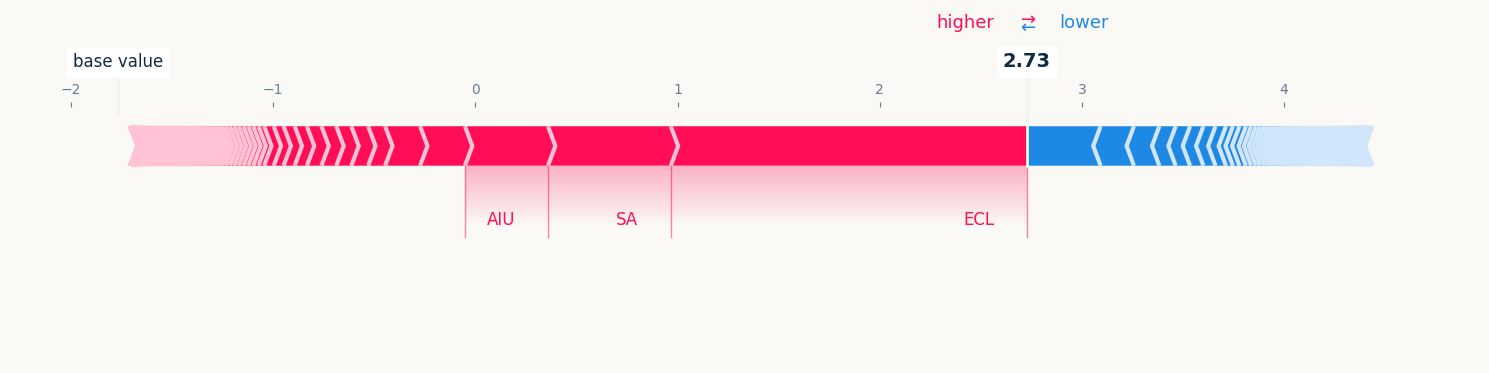

In [48]:
## -- Feature interactions/influence --
shapiq.network_plot(interaction_values=explanation, feature_names=BASE, show=True)
explanation.plot_force(feature_names=BASE, contribution_threshold=0.1)

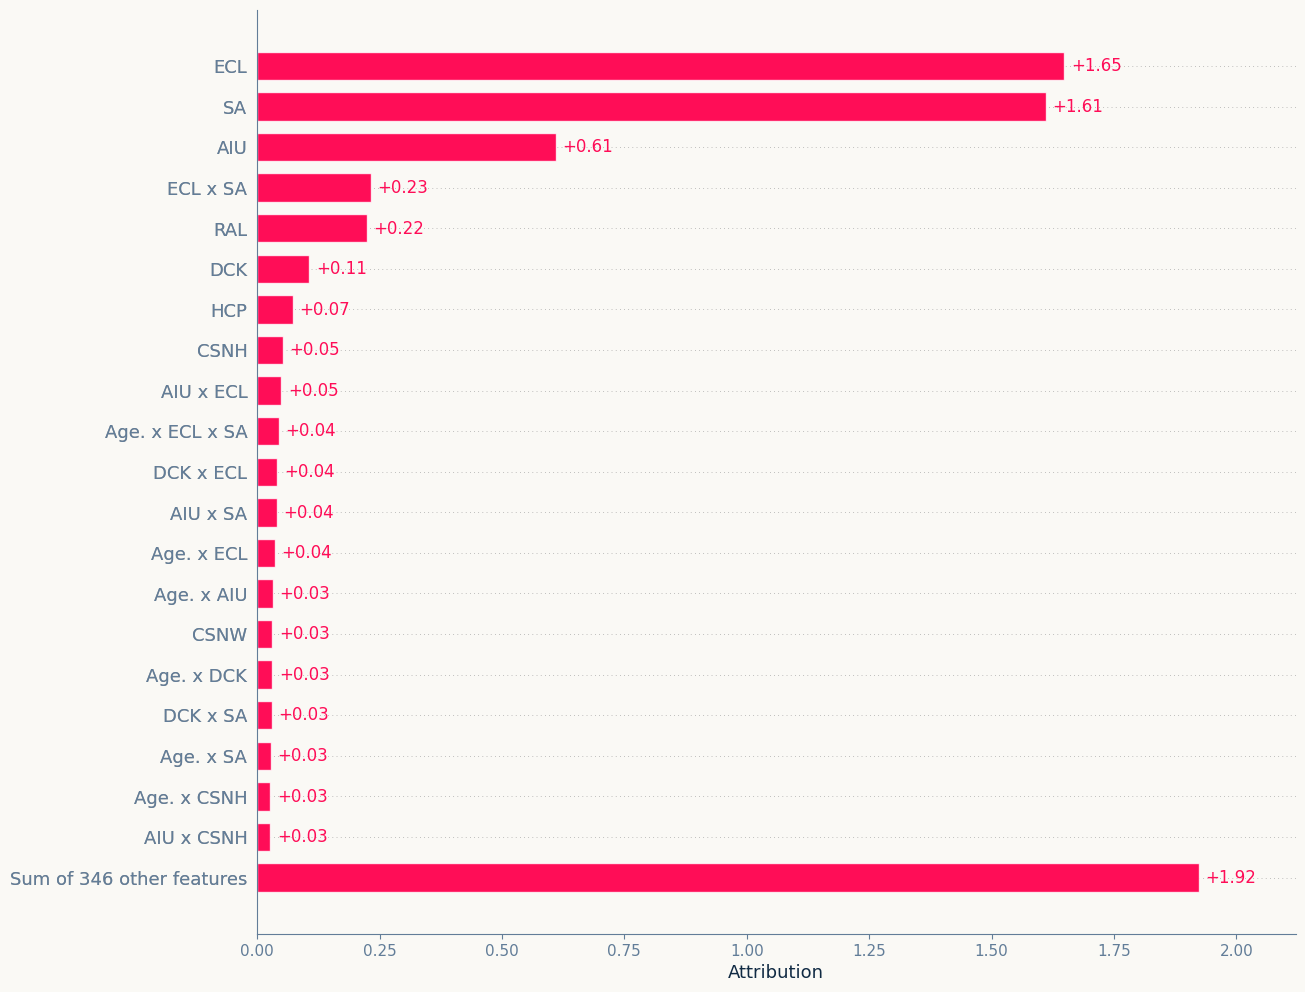

In [49]:
list_of_ivs = explainer.explain_X(X_test.loc[idx].to_numpy())
shapiq.plot.bar_plot(list_of_ivs, feature_names=BASE, max_display=MAX, show=True)

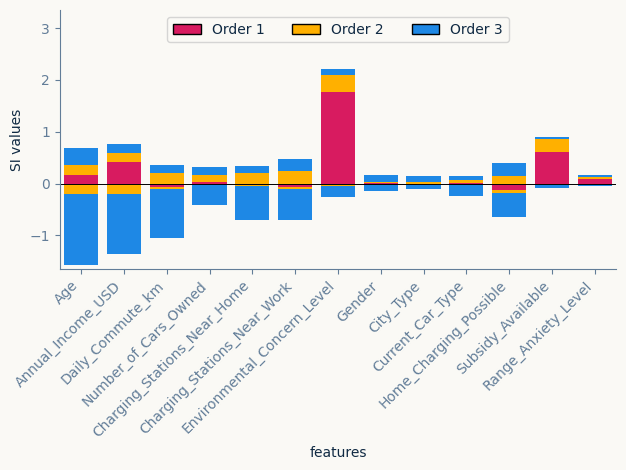

In [50]:
shapiq.stacked_bar_plot(
    # interaction_values=explanation.get_n_order(1), # plot order 1
    # interaction_values=explanation.get_n_order(2, min_order=1), # plot order 2
    interaction_values=explanation.get_n_order(3, min_order=1), # plot order 3
    feature_names=BASE, show=True,
)
# plt.show()

## 2. GAM Partial Effects

In [51]:
try:
    from pygam import LogisticGAM, s, f, te
except:
    !uv pip install --system pygam
    from pygam import LogisticGAM, s, f, te

def gam_dependence_effect(df, features, target, cats):
    df1 = df.copy()

    # Dynamically build the GAM formula based on feature types
    gam_terms = []
    for i, feature_name in enumerate(features):
        if feature_name in cats:
            gam_terms.append(f"f({i})")
        else:
            gam_terms.append(f"s({i})")

    gam_terms.append(f"te({6}, {11})")
    gam_formula = " + ".join(gam_terms)

    for c in cats:
        df1[c] = df1[c].factorize()[0]

    for c in features:
        df1[c] = df1[c].fillna(-1)

    X_gam = df1[features].values
    y_gam = df1[target].values

    # Evaluate the string formula into actual pygam Term objects
    gam = LogisticGAM(eval(gam_formula), verbose=True)
    gam.fit(X_gam, y_gam)

    rows = (len(features) + 2) // 3 # Calculate rows for subplots dynamically
    fig, axs = plt.subplots(rows, 3, figsize=(18, rows*4))
    axs = axs.ravel()

    for i, col in enumerate(features):
        XX = gam.generate_X_grid(term=i)
        # pdep = gam.partial_dependence(term=i, X=XX)
        pdep, confi = gam.partial_dependence(term=i, width=0.95)

        axs[i].plot(XX[:, i], pdep)
        axs[i].plot(XX[:, i], confi, c=GOLD, ls="--")
        axs[i].set_title(f"GAM: {col}", loc='left', pad=26)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel("partial_effect")

    # Hide any unused subplots
    for j in range(len(features), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout(pad=2.0)
    plt.savefig("pygam_pdep_plot")
    plt.show()

    return gam

print("✓ GAM Dependency function ready!")

Using Python 3.12.13 environment at: /usr
Resolved 6 packages in 246ms
Prepared 1 package in 32ms
Installed 1 package in 2ms
 + pygam==0.12.0
✓ GAM Dependency function ready!


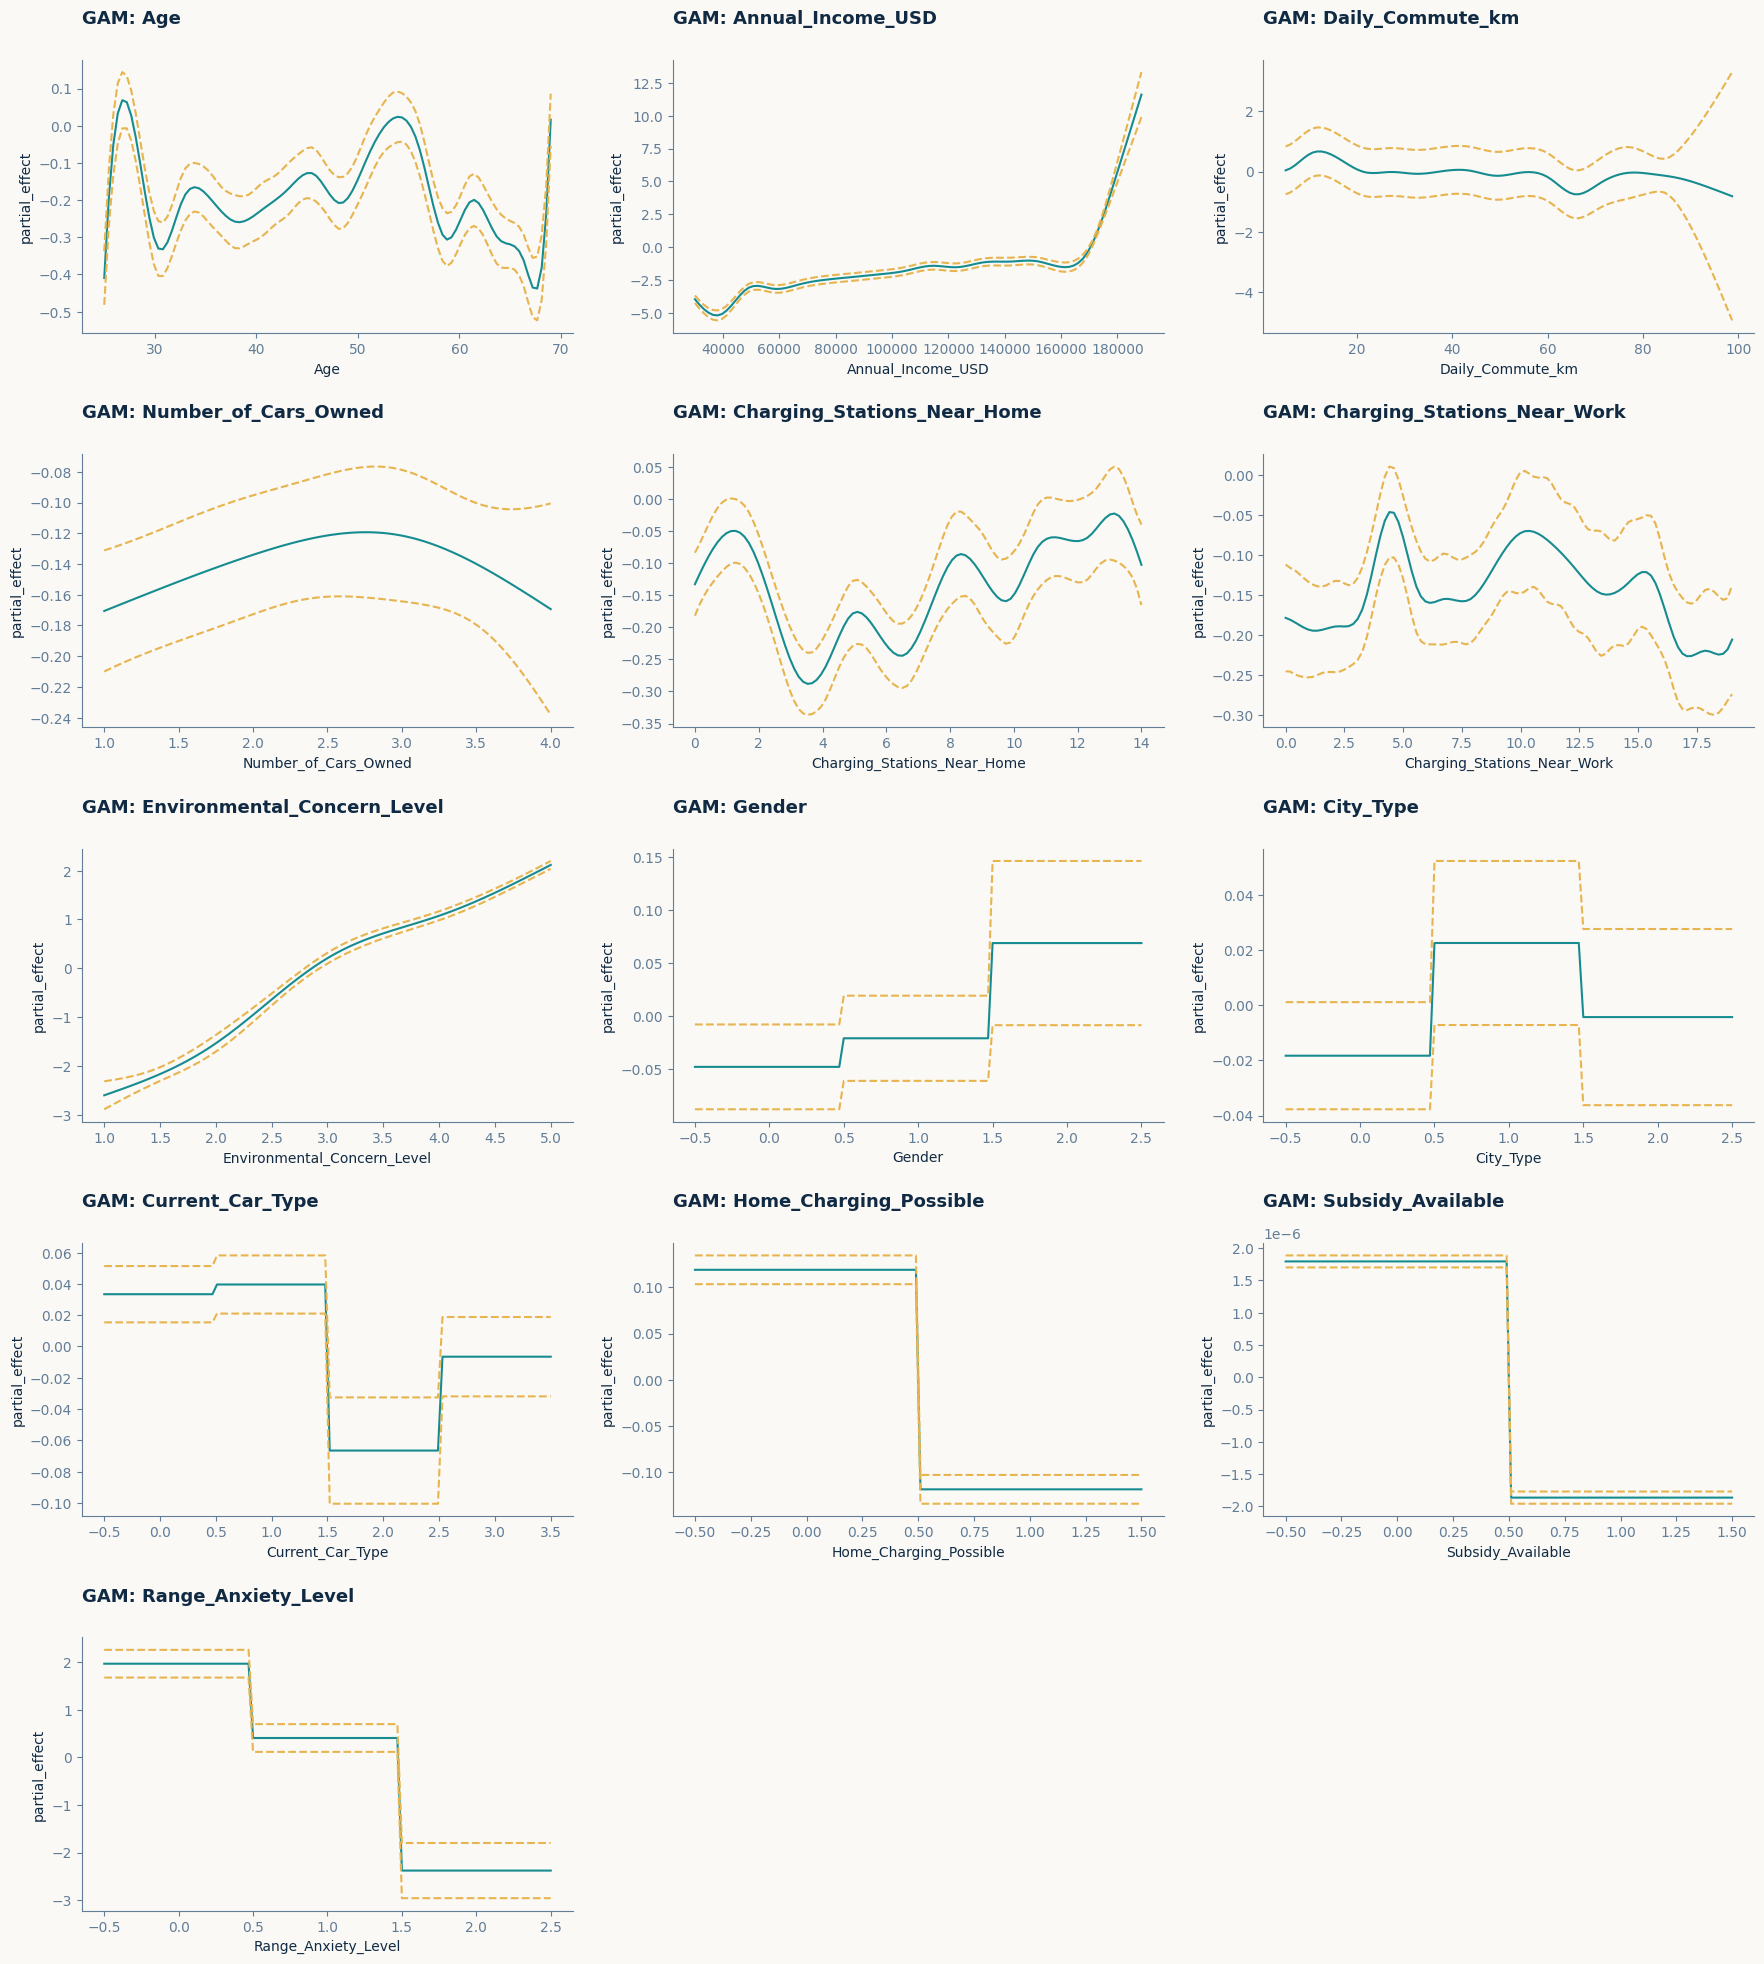

CPU times: user 7min 5s, sys: 35.4 s, total: 7min 41s
Wall time: 3min 42s


In [52]:
%%time

gam_ = gam_dependence_effect(pd.concat([X_train, y_train], axis=1), BASE, TARGET, CATS)

In [53]:
gam_.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                    100.2441
Link Function:                        LogitLink Log Likelihood:                               -115558.3651
Number of Samples:                       501498 AIC:                                           231317.2184
                                                AICc:                                          231317.2597
                                                UBRE:                                               2.4614
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.5025
Feature Function                  Lam

In [54]:
# gam_.accuracy(X_test, y_test)

In [55]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the
#         global mean. If 'auto', an empirical Bayes estimate is used.

#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_valid = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'

#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)

#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups

#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_valid[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_valid[col].map(mapping)

#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_valid.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [56]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [57]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:1000],
#     features=BASE,
#     target=TARGET,
#     # - (count, mean, count, std, nunique, median, max, min)
#     aggs=['mean'],
#     fill_nan=True,
# )

# print(ORIG_COLS)

In [58]:
## -- Factorize using combined data --

# for c in CATS:
#     print(c)
#     combine  = pd.concat([train[c], test[c]]) # , orig[c]
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = pd.Series(combine[:len(train)], index=train.index).astype('category')
#     test[c]  = pd.Series(combine[len(train):len(train)+len(test)], index=test.index).astype('category')
#     # orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [59]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('✓ Total Features:', len(FEATURES))

# if 'age' in NUMS:
#     NUMS.remove('age')
# if 'age' not in CATS:
#     CATS.append('age')

# group = train['Stint'].to_numpy()
# gkf = GroupKFold(n_splits=len(np.unique(group)), shuffle=True, random_state=CFG.SEED)

oof_final    = pd.DataFrame()
test_final   = pd.DataFrame()
model_scores = pd.Series()

CFG['FOLDS'] = 10
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])
skf

✓ Total Features: 13


StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

# ML TRAINING

In [60]:
## -- TREE MODELS --
tree_models = {
    "xgb_": xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        iterations=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.4,
        reg_lambda=0.1,
        enable_categorical=True,
        random_state=CFG['SEED'],
        verbosity=0,
        n_jobs=-1,
        device="cuda" if torch.cuda.is_available() else "cpu",
    ),
    "lgb_": lgb.LGBMClassifier(
        objective="binary",
        metric="auc",
        iterations=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.4,
        reg_lambda=0.1,
        verbose=-1,
        nthreads=-1,
        random_state=CFG['SEED'],
        device="gpu" if torch.cuda.is_available() else "cpu",
    ),
    "cat_": cgb.CatBoostClassifier(
        loss_function="Logloss", # -> also 'CrossEntropy'
        eval_metric="AUC",
        iterations=1000,
        learning_rate=0.1,
        cat_features=CATS,
        verbose=0,
        thread_count=-1,
        random_state=CFG['SEED'],
        allow_writing_files=False,
        task_type="GPU" if torch.cuda.is_available() else "CPU",
    ),
    "rfc_": RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=CFG['SEED'],
    ),
    "hist_": HistGradientBoostingClassifier(
        random_state=CFG['SEED'],
    ),
}

print(f"Tree Models to train: {len(tree_models)}", end=" -> ")
print(list(tree_models.keys()))

Tree Models to train: 5 -> ['xgb_', 'lgb_', 'cat_', 'rfc_', 'hist_']


## ~ TREE MODELS

Training Models:   0%|          | 0/5 [00:00<?, ?it/s]


[1] XGB_ ██████████ | (601798, 13)
• Fold 1/10 Score: 0.940341
• Fold 2/10 Score: 0.940646
• Fold 3/10 Score: 0.941118
• Fold 4/10 Score: 0.941794
• Fold 5/10 Score: 0.942623
• Fold 6/10 Score: 0.942984
• Fold 7/10 Score: 0.941885
• Fold 8/10 Score: 0.942573
• Fold 9/10 Score: 0.942723
• Fold 10/10 Score: 0.940696
OOF Score: 0.941731
AVG Score: 0.941738 ± 0.000930
Time: 1.14 mins


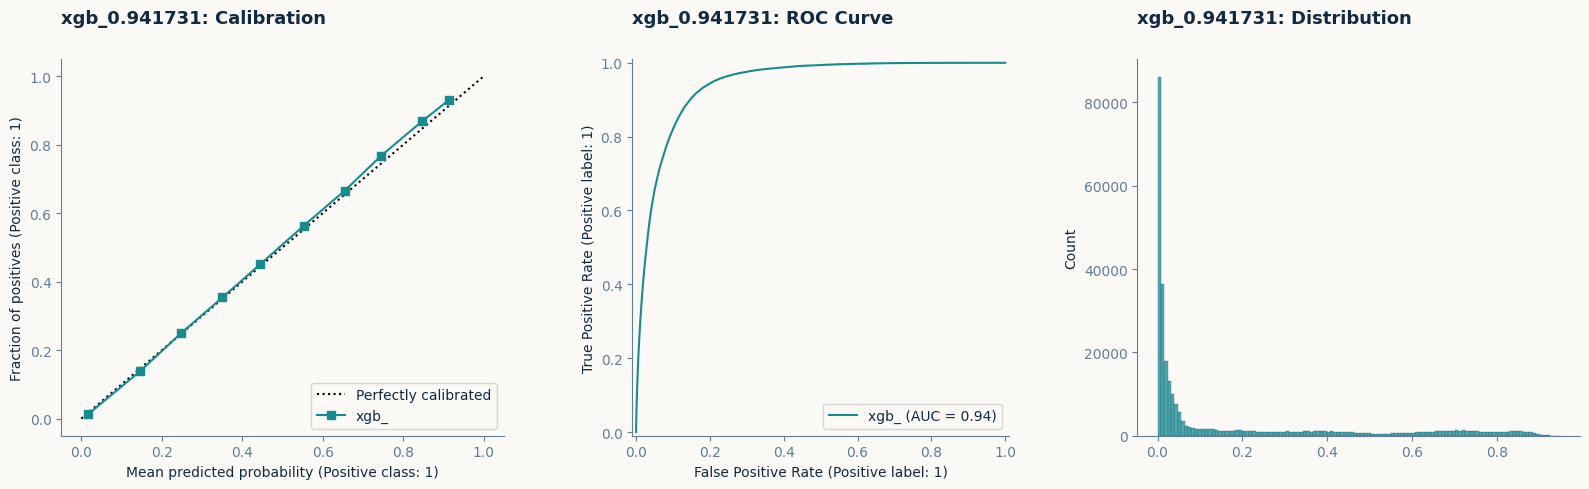

Training Models:  20%|██        | 1/5 [01:09<04:37, 69.45s/it]


[2] LGB_ ██████████ | (601798, 13)
• Fold 1/10 Score: 0.940579
• Fold 2/10 Score: 0.940780
• Fold 3/10 Score: 0.941153
• Fold 4/10 Score: 0.942013
• Fold 5/10 Score: 0.942732
• Fold 6/10 Score: 0.942997
• Fold 7/10 Score: 0.941893
• Fold 8/10 Score: 0.942730
• Fold 9/10 Score: 0.942893
• Fold 10/10 Score: 0.940745
OOF Score: 0.941844
AVG Score: 0.941852 ± 0.000919
Time: 0.94 mins


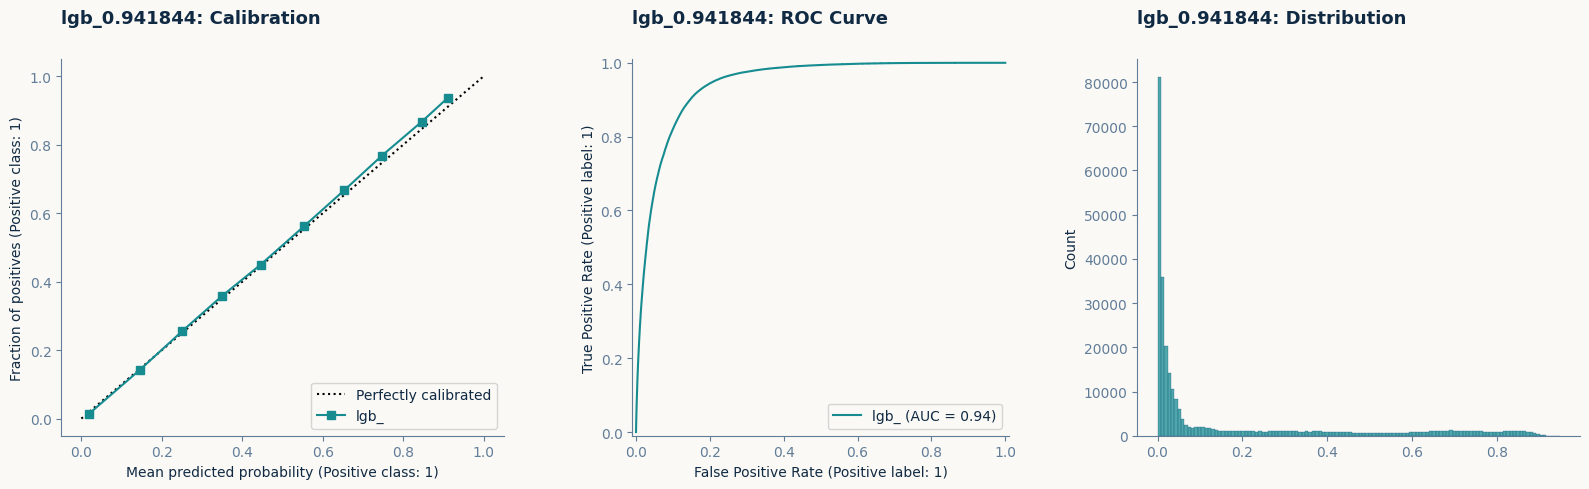

Training Models:  40%|████      | 2/5 [02:07<03:07, 62.48s/it]


[3] CAT_ ██████████ | (601798, 13)
• Fold 1/10 Score: 0.940690
• Fold 2/10 Score: 0.940743
• Fold 3/10 Score: 0.941081
• Fold 4/10 Score: 0.941838
• Fold 5/10 Score: 0.942716
• Fold 6/10 Score: 0.943086
• Fold 7/10 Score: 0.941921
• Fold 8/10 Score: 0.942779
• Fold 9/10 Score: 0.942808
• Fold 10/10 Score: 0.940704
OOF Score: 0.941832
AVG Score: 0.941837 ± 0.000924
Time: 58.34 mins


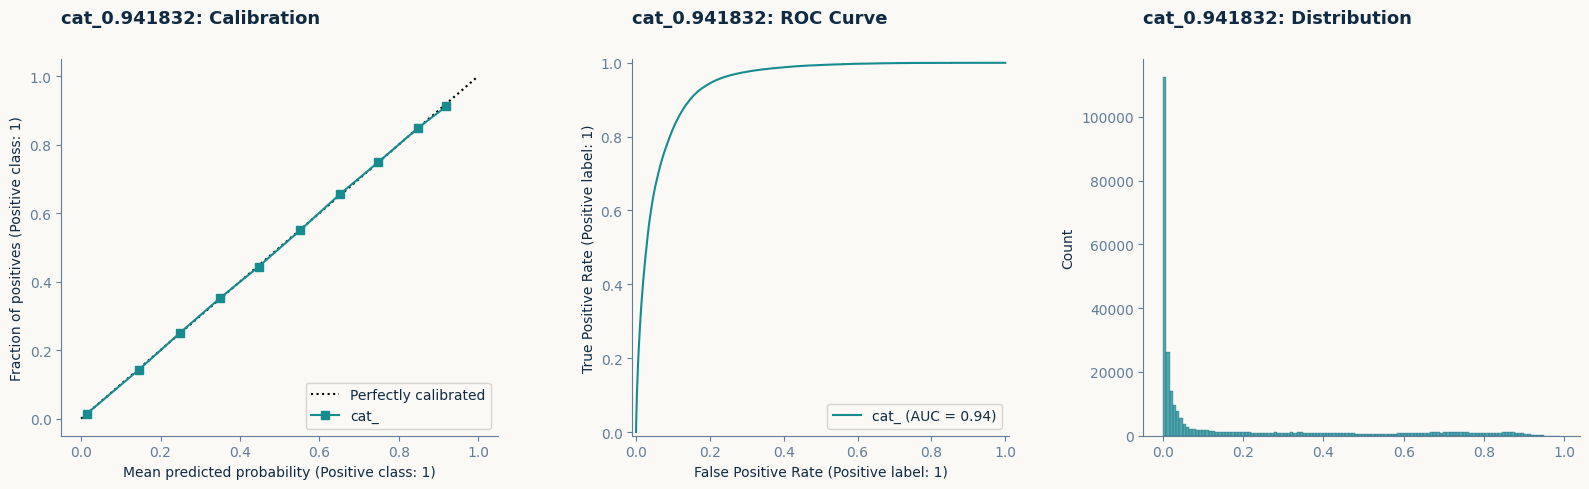

Training Models:  60%|██████    | 3/5 [1:00:29<54:26, 1633.08s/it]


[4] RFC_ ██████████ | (601798, 13)
• Fold 1/10 Score: 0.934657
• Fold 2/10 Score: 0.934420
• Fold 3/10 Score: 0.935092
• Fold 4/10 Score: 0.936019
• Fold 5/10 Score: 0.936619
• Fold 6/10 Score: 0.937497
• Fold 7/10 Score: 0.935731
• Fold 8/10 Score: 0.936993
• Fold 9/10 Score: 0.936975
• Fold 10/10 Score: 0.934781
OOF Score: 0.935875
AVG Score: 0.935878 ± 0.001053
Time: 25.84 mins


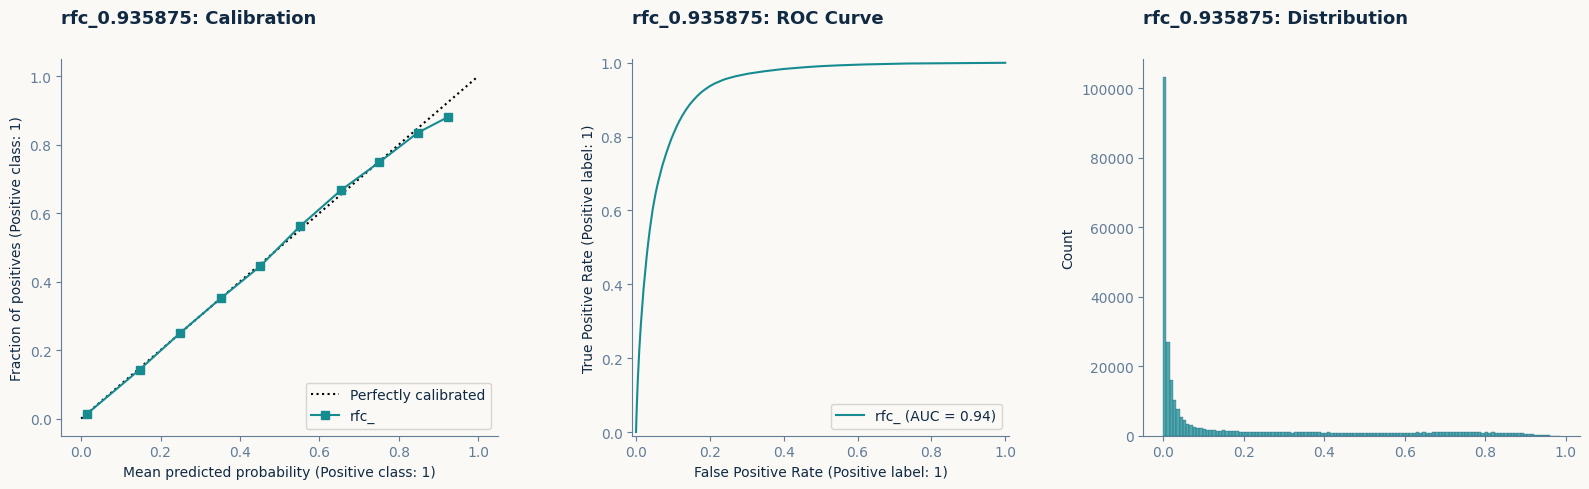

Training Models:  80%|████████  | 4/5 [1:26:20<26:40, 1600.82s/it]


[5] HIST_ ██████████ | (601798, 13)
• Fold 1/10 Score: 0.939565
• Fold 2/10 Score: 0.940030
• Fold 3/10 Score: 0.940343
• Fold 4/10 Score: 0.941205
• Fold 5/10 Score: 0.941895
• Fold 6/10 Score: 0.942354
• Fold 7/10 Score: 0.941171
• Fold 8/10 Score: 0.942008
• Fold 9/10 Score: 0.942165
• Fold 10/10 Score: 0.940085
OOF Score: 0.941065
AVG Score: 0.941082 ± 0.000963
Time: 1.46 mins


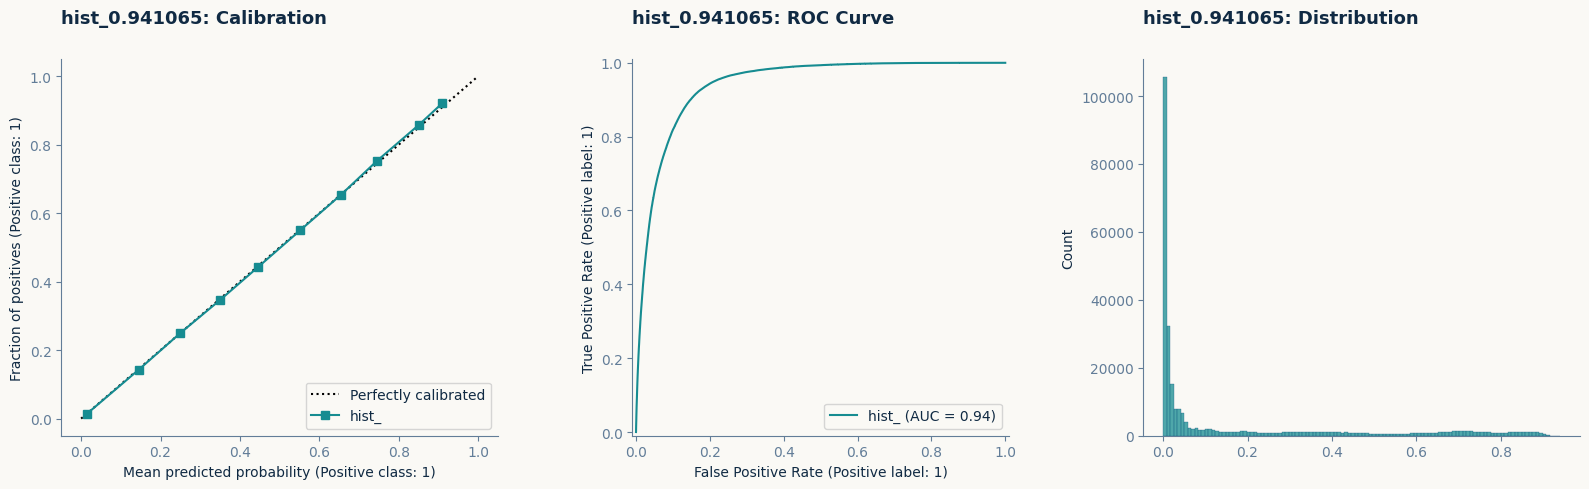

Training Models: 100%|██████████| 5/5 [1:27:49<00:00, 1053.88s/it]


In [61]:
## -- Initiate GBDTs Training --
TREE_MODELS = {}

desc = "Training Models"
for i, (name, model) in tqdm(enumerate(tree_models.items(), 1), total=len(tree_models), desc=desc):
    print(f"\n[{i}] {(name.upper())} {'█'*10}", end=" | ")
    t0 = time()
    
    X = train[FEATURES]
    y = train[TARGET]
    test_1 = test[FEATURES]

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(test_1))
    fold_scores = []

    if "cat" in name:
        combined = pd.concat([X, test_1])
        for c in CATS:
            combined[c] = combined[c].factorize()[0]
        X = combined[:len(X)]
        test_1 = combined[-len(test_1):]
    else:
        combined = pd.concat([X, test_1])
        for c in CATS:
            combined[c] = combined[c].factorize()[0]
            combined[c] = combined[c].astype("category")
        X = combined.iloc[:len(X)]
        test_1 = combined.iloc[-len(test_1):]

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_1[FEATURES].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=FEATURES,
        #     target=TARGET,
        #     aggs=['mean'], # (mean, count, std, nunique, median, max, min)
        #     # fill_nan=True,
        # )

        ## -- TE Opt1. -> Using CUSTOM --
        # te_cols = [c for c in FEATURES if X_train[c].nunique()<=1000]
        # TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE.fit_transform(X_train, y_train)
        # X_valid = TE.transform(X_valid)
        # X_test  = TE.transform(X_test)

        # if 'cat' in name:
        #     combined = pd.concat([X_train, X_valid, X_test])
        #     for c in CATS:
        #         combined[c] = combined[c].factorize()[0]
        #     X_train = combined[:len(X_train)]
        #     X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
        #     X_test  = combined[len(X_train)+len(X_valid):]
        # else:
        #     combined = pd.concat([X_train, X_valid, X_test])
        #     for c in CATS:
        #         combined[c] = combined[c].factorize()[0]
        #         combined[c] = combined[c].astype('category')
        #     X_train = combined[:len(X_train)]
        #     X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
        #     X_test  = combined[len(X_train)+len(X_valid):]

        if fold == 1:
            print(f"{X_train.shape}")

        print(f"• Fold {fold}/{skf.n_splits}", end=" ")

        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"Score: {fold_score:.6f}")

    # test_preds /= skf.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 6)
    print(f"{'='*30}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print(f"{'='*30}")

    print(f"Time: {(time() - t0)/60:.2f} mins")

    _, axs = plt.subplots(1, 3, figsize=(16, 5)) #, width_ratios=[0.6,0.4]

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
    axs[0].set_title(f"{name}{overall_score}: Calibration", loc='left', pad=26)

    RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
    axs[1].set_title(f"{name}{overall_score}: ROC Curve", loc='left', pad=26)
    ## -- axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{name}{overall_score}: Distribution", loc='left', pad=26)

    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split('.')[1]
    oof_final[n]    = oof_preds
    test_final[n]   = test_preds
    TREE_MODELS[n]  = model
    model_scores[n] = overall_score

    del X, y, test_1
    gc.collect()

In [62]:
# 5-fold test
# -------------------------------
# xgboost
# OOF Score: 0.941693
# AVG Score: 0.941701 ± 0.000772

# lgbm
# OOF Score: 0.941891
# AVG Score: 0.941897 ± 0.000790

# cat
# OOF Score: 0.941714
# AVG Score: 0.941720 ± 0.000707

In [63]:
display(oof_final.head(3))
print()
display(test_final.head(3))

# xgb_941205	lgb_941352	cat_941664	rfc_933663	hist_941042

,xgb_941731,lgb_941844,cat_941832,rfc_935875,hist_941065
0,0.001382,0.001605,0.000106,0.000000,0.000248
1,0.004592,0.004719,0.002202,0.000000,0.002944
2,0.736309,0.741163,0.783630,0.673333,0.752703


,xgb_941731,lgb_941844,cat_941832,rfc_935875,hist_941065
0,0.013701,0.016641,0.010923,0.007667,0.008060
1,0.031489,0.029806,0.021666,0.045333,0.018436
2,0.009040,0.010272,0.004858,0.004333,0.006402


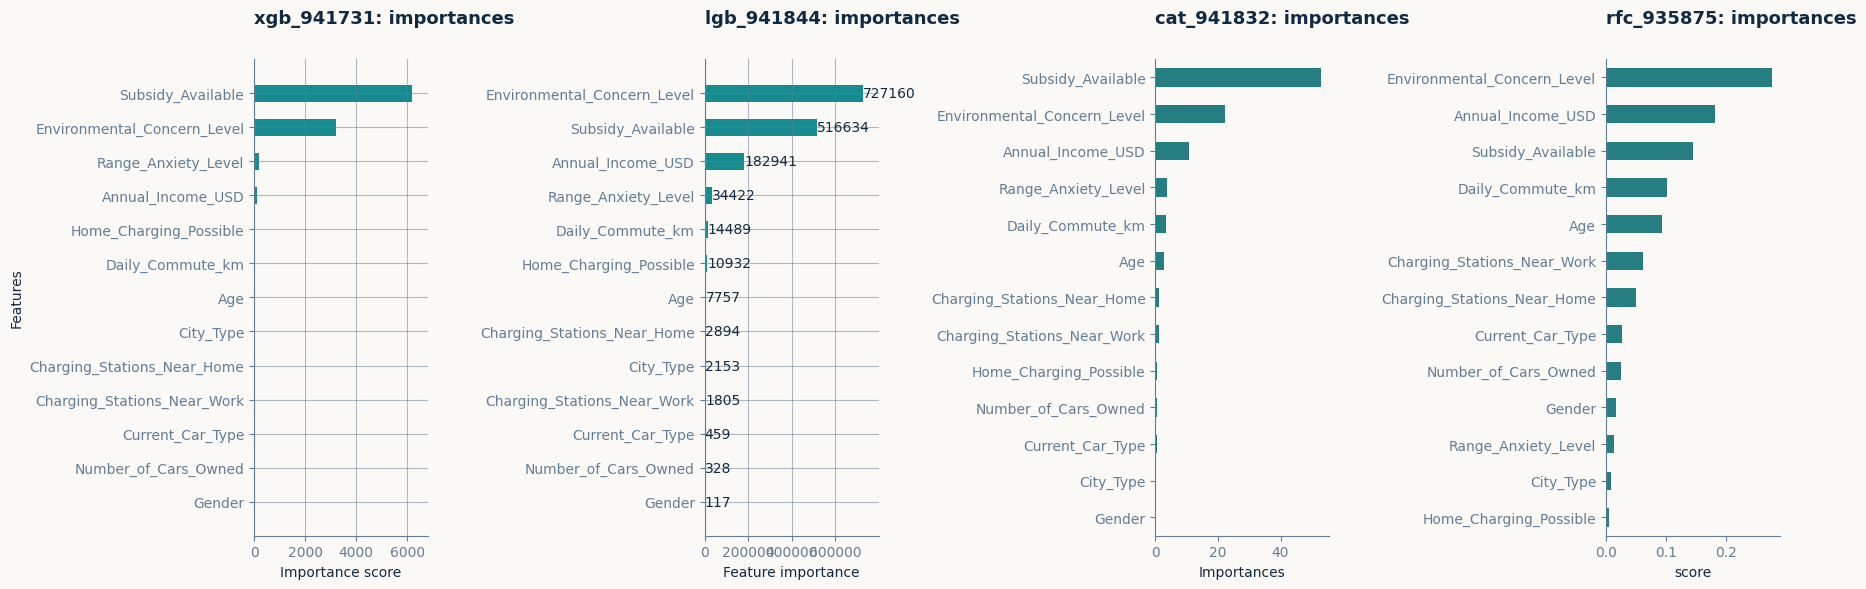

In [64]:
## -- Plot Feature Importances --

plot_trees = {k: v for k, v in TREE_MODELS.items() if 'hist' not in k}
plot_trees

MAX = 20

rows = (len(plot_trees) + 2) // 4 # Calculate rows for subplots dynamically
fig, axs = plt.subplots(rows, 4, figsize=(18, rows*6))
axs = axs.ravel()

for i, (k, v) in enumerate(plot_trees.items()):
    ## -- xgboost --
    if "xgb" in k:
        xgb.plot_importance(
            v, max_num_features=MAX,
            importance_type="gain",
            title="",
            height=0.5, show_values=False, ax=axs[i],
        )

    ## -- lightgbm --
    elif "lgb" in k:
        lgb.plot_importance(
            v, max_num_features=MAX,
            importance_type="gain",
            title="",
            height=0.5, precision=0, ax=axs[i],
        )
        axs[i].set_ylabel('')

    ## -- catboost --
    elif "cat" in k:
        cat_imp_df = v.get_feature_importance(prettified=True).iloc[:MAX]
        sns.barplot(data=cat_imp_df, x="Importances", y="Feature Id", width=0.5, ax=axs[i])
        # axs[i].set_title("CAT: importances")
        axs[i].set_ylabel("")

    ## -- random forest --
    elif "rfc" in k:
        rf_dicts = dict(zip(X_train.columns, v.feature_importances_))
        rf_imp_df = pd.DataFrame.from_dict(rf_dicts, orient="index", columns=["score"])\
                                .sort_values("score", ascending=False).iloc[:MAX]
        sns.barplot(rf_imp_df, x=rf_imp_df.score, y=rf_imp_df.index, width=0.5, ax=axs[i])
        axs[i].set_ylabel("")
        
    axs[i].set_title(f"{k}: importances", loc='left', pad=26)
    plt.tight_layout()

# Hide any unused subplots
for j in range(len(plot_trees), len(axs)):
    axs[j].axis('off')

plt.show()

In [65]:
# ## -- Plot Feature Importances --
# plot_trees = {k: v for k, v in TREE_MODELS.items() if 'hist' not in k}
# plot_trees

# MAX = 20
# fig, axs = plt.subplots(1, len(plot_trees), figsize=(16, 6))

# ## -- XGBoost --
# for k, v in plot_trees.items():
#     if "xgb" in k:
#         xgb.plot_importance(
#             v, max_num_features=MAX,
#             importance_type="gain",
#             title="XGB - Feature importance",
#             height=0.5, show_values=False, ax=axs[0],
#         )

#     ## -- LightGBM --
#     elif "lgb" in k:
#         lgb.plot_importance(
#             v, max_num_features=MAX,
#             importance_type="gain",
#             title="LGBM - Feature importance",
#             height=0.5, precision=0, ax=axs[1],
#         )
#         axs[1].set_ylabel('')

#     ## -- CatBoost --
#     elif "cat" in k:
#         cat_imp_df = v.get_feature_importance(prettified=True).iloc[:MAX]
#         sns.barplot(data=cat_imp_df, x="Importances", y="Feature Id", width=0.5, ax=axs[2])
#         axs[2].set_title("CAT - Feature importance")
#         axs[2].set_ylabel("")

#     ## -- RandomForest --
#     elif "rfc" in k:
#         rf_dicts = dict(zip(X_train.columns, v.feature_importances_))
#         rf_imp_df = pd.DataFrame.from_dict(rf_dicts, orient="index", columns=["score"])\
#                                 .sort_values("score", ascending=False).iloc[:MAX]
#         sns.barplot(rf_imp_df, x=rf_imp_df.score, y=rf_imp_df.index, width=0.5, ax=axs[3])
#         axs[3].set_title("RF - Feature importance")
#         axs[3].set_ylabel("")

#     for ax in axs:
#         ax.spines["top"].set_visible(False)
#         ax.spines["right"].set_visible(False)

# plt.tight_layout()
# plt.show()

## ~ LINEAR MODELS

In [66]:
train_2 = train.copy()
test_2  = test.copy()

In [67]:
for col in ["Annual_Income_USD"]:
    log_col = f"log_{col}"
    train_2[log_col] = np.log1p(train_2[col])
    test_2[log_col]  = np.log1p(test_2[col])
    print(f"+++ applying log: {col} --- min={min(train_2[log_col]):.6g} | max={max(train_2[log_col]):.6g}")

poly_feats = ["Age", "Daily_Commute_km"]

for col in poly_feats:
    p2_col = f"squared_{col}"
    train_2[p2_col] = train_2[col] ** 2
    test_2[p2_col]  = test_2[col] ** 2
    print(f"+++ power^2: {col} --- min={min(train_2[p2_col]):.6g} | max={max(train_2[p2_col]):.6g}")

    p3_col = f"cubed_{col}"
    train_2[p3_col] = train_2[col] ** 3
    test_2[p3_col]  = test_2[col] ** 3
    print(f"+++ power^3: {col} --- min={min(train_2[p3_col]):.6g} | max={max(train_2[p3_col]):.6g}")

# # Add the binned column to your training dataframe
# bin_feats = ['Annual_Income_USD']
# bins_     = [5]
# bin_cats  = []

# for col in bin_feats:
#     for bin_ in bins_:
#         n = f"{col}_bin{bin_}"
#         train_2[n], bin_edges = pd.cut(train_2[col], bins=bin_, duplicates='drop', include_lowest=True, retbins=True)
#         # Apply the saved bin edges to the test data
#         test_2[n] = pd.cut(test_2[col], bins=bin_edges)
#         bin_cats.append(n)
# CATS.extend(bin_cats)

+++ applying log: Annual_Income_USD --- min=10.309 | max=12.1471
+++ power^2: Age --- min=625 | max=4761
+++ power^3: Age --- min=15625 | max=328509
+++ power^2: Daily_Commute_km --- min=25 | max=9741.69
+++ power^3: Daily_Commute_km --- min=125 | max=961505


In [68]:
FEATURES_2 = [c for c in train_2.columns if c not in [ID, TARGET]]
print("✓ Total Features:", len(FEATURES_2))

train_2

✓ Total Features: 18


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,log_Annual_Income_USD,squared_Age,cubed_Age,squared_Daily_Commute_km,cubed_Daily_Commute_km
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0,11.439150,4356,287496,547.56,12812.904
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0,10.308986,1444,54872,25.00,125.000
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1,11.455190,676,17576,1354.24,49836.032
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,11.206142,4356,287496,561.69,13312.053
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,10.966455,2916,157464,2580.64,131096.512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,0,11.171716,900,27000,750.76,20570.824
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,0,11.775220,1024,32768,25.00,125.000
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,0,11.710070,4096,262144,585.64,14172.488
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,0,11.660690,2601,132651,1909.69,83453.453


In [69]:
# ## -- Fill categorical --
# # train[CATS] = train[CATS].fillna('missing')
# # test[CATS]  = test[CATS].fillna('missing')
# # orig[CATS]  = orig[CATS].fillna('missing')

# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train_2, INDI_COLS = appy_nan_indicator(train_2)
# test_2, _  = appy_nan_indicator(test_2)
# # orig, _  = appy_nan_indicator(orig)

# print(INDI_COLS)
# train_2

In [70]:
## -- Linear Models --

# oof_final    = pd.DataFrame()
# test_final   = pd.DataFrame()
# model_scores = pd.Series()

linear_models = {
    "naive_": GaussianNB(),
    "logit_": LogisticRegression(
        max_iter=1000,
        C=1.0,
        # class_weight='balanced',
        n_jobs=-1,
        random_state=CFG["SEED"],
    ),
    # "logit0.1_": LogisticRegression(
    #     max_iter=1000,
    #     C=0.1,
    #     # class_weight='balanced',
    #     n_jobs=-1,
    #     random_state=CFG["SEED"],
    # ),
    # "logit30.01_": LogisticRegression(
    #     max_iter=1000,
    #     C=0.01,
    #     # class_weight='balanced',
    #     n_jobs=-1,
    #     random_state=CFG["SEED"],
    # ),
    "mlp_": MLPClassifier(
        hidden_layer_sizes=(len(FEATURES_2) * 5),
        alpha=0.001, # reduce for faster convergence
        max_iter=50,
        random_state=CFG["SEED"],
    ),
    "knn_": KNeighborsClassifier(
        # algorithm="auto",
        n_jobs=-1,
    ),
}

print(f"Linear Models ({len(linear_models)}): ", end="")
print(list(linear_models.keys()))

Linear Models (4): ['naive_', 'logit_', 'mlp_', 'knn_']


In [71]:
# ## -- LINEAR MODEL TRAINER --
# model_id = 0
# name = [*linear_models.keys()][model_id]

# X = train_2[FEATURES_2].copy()
# y = train_2[TARGET].copy()

# oof_preds   = np.zeros(len(X))
# test_preds  = np.zeros(len(test_2))
# fold_scores = []

# t0 = time()
# print(f"\n[1] {name.upper()} {'█'*10} | ", end="")

# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#     X_train, y_train = X.iloc[train_idx], y[train_idx]
#     X_valid, y_valid = X.iloc[val_idx], y[val_idx]
#     X_test = test_2[FEATURES_2].copy()

#     if fold == 1:
#         print(X_train.shape)

#     ## ------------------------------------------------------------------------
#     # ## -- Define encoders --
#     # scaler_enc  = StandardScaler()
#     # one_h_enc   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary")
#     # num_imputer = IterativeImputer(max_iter=50, tol=1e-4, add_indicator=False, random_state=0)
#     # cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING", add_indicator=False)
    
#     # num_cols = X_train.columns.difference(CATS, sort=False)

#     # num_sub_pipeline = Pipeline([('sca', scaler_enc), ('imp', num_imputer)])
#     # # cat_sub_pipeline = Pipeline([('imp', cat_imputer), ('ohe', one_h_enc)])
#     # preprocessor = ColumnTransformer(
#     #     [
#     #         # ('cat_prep', cat_sub_pipeline, CATS),
#     #         ('num_prep', num_sub_pipeline, NUMS),
#     #     ],
#     #     remainder='passthrough',
#     #     n_jobs=8 if os.cpu_count() > 4 else 1,
#     #     )
#     # ## -- Create pipeline --
#     # m = LogisticRegression(
#     #     max_iter=5000,
#     #     # tol=1e-4,
#     #     # cv=5,
#     #     # scoring='roc_auc',
#     #     # class_weight='balanced',
#     #     n_jobs=64 if os.cpu_count() > 4 else 3,
#     #     random_state=CFG['SEED'],
#     # )
#     # model = Pipeline([('prep_cols', preprocessor), (name, m)]).set_output(transform='pandas')
#     # ## ------------------------------------------------------------------------
#     for col in NUMS:
#         scaler = StandardScaler()
#         X_train[col] = scaler.fit_transform(X_train[[col]], y_train)
#         X_valid[col] = scaler.transform(X_valid[[col]])
#         X_test[col]  = scaler.transform(X_test[[col]])

#     iter_imputer = IterativeImputer(max_iter=50, tol=1e-4, add_indicator=False, random_state=0)
#     X_train.loc[:, NUMS] = iter_imputer.fit_transform(X_train[NUMS])
#     X_valid.loc[:, NUMS] = iter_imputer.transform(X_valid[NUMS])
#     X_test.loc[:, NUMS]  = iter_imputer.transform(X_test[NUMS])

#     model = [*linear_models.values()][model_id]
#     model.fit(X_train, y_train)

#     # if fold == 1:
#     #     print(f"-> Total expanded features: {len(model[:-1].get_feature_names_out())}")

#     oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
#     test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

#     fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#     fold_scores.append(fold_score)
#     print(f"\tFold {fold}/{skf.n_splits} Score: {fold_score:.6f}")

#     del X_train, y_train, X_valid, y_valid, X_test

# # test_preds /= skf.n_splits

# ## -- After all folds --
# overall_score = np.round(roc_auc_score(y, oof_preds), 6)

# print(f"{'-'*31}")
# print(f"OOF Score: {overall_score}")
# print(f"AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
# print(f"{'-'*31}")

# print(f"Duration: {(time() - t0)/60:.2f} mins")

# _, axs = plt.subplots(1, 3, figsize=(18, 5)) #, width_ratios=[0.6,0.4]
# # Right: Confusion matrix (threshold = 0.5)
# pred_labels = (oof_preds >= 0.5).astype('int8')

# CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
# axs[0].set_title(f"{name}: Calibrated predictions")

# # Left: ROC curve
# RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
# axs[1].set_title(f"{name}: Score = {overall_score}")
# # axs[1].grid(False)

# sns.histplot(test_preds, ax=axs[2])
# axs[2].set_title(f"{name}: Distribution")

# plt.tight_layout()
# plt.show()

# n = name + str(overall_score).split('.')[1]
# oof_final[n]     = oof_preds
# test_final[n]    = test_preds
# model_scores[n]  = overall_score
# LINEAR_MODELS[n] = model

# gc.collect()

  0%|          | 0/4 [00:00<?, ?it/s]


[1] NAIVE_ ██████████ | (601798, 18)
-> Total expanded features: 27
	Fold 1/10 Score: 0.921452
	Fold 2/10 Score: 0.921307
	Fold 3/10 Score: 0.921618
	Fold 4/10 Score: 0.924287
	Fold 5/10 Score: 0.923409
	Fold 6/10 Score: 0.923707
	Fold 7/10 Score: 0.922701
	Fold 8/10 Score: 0.923225
	Fold 9/10 Score: 0.922862
	Fold 10/10 Score: 0.920804
-------------------------------
OOF Score: 0.922431
AVG Score: 0.922537 ± 0.001111
-------------------------------
Duration: 0.75 mins


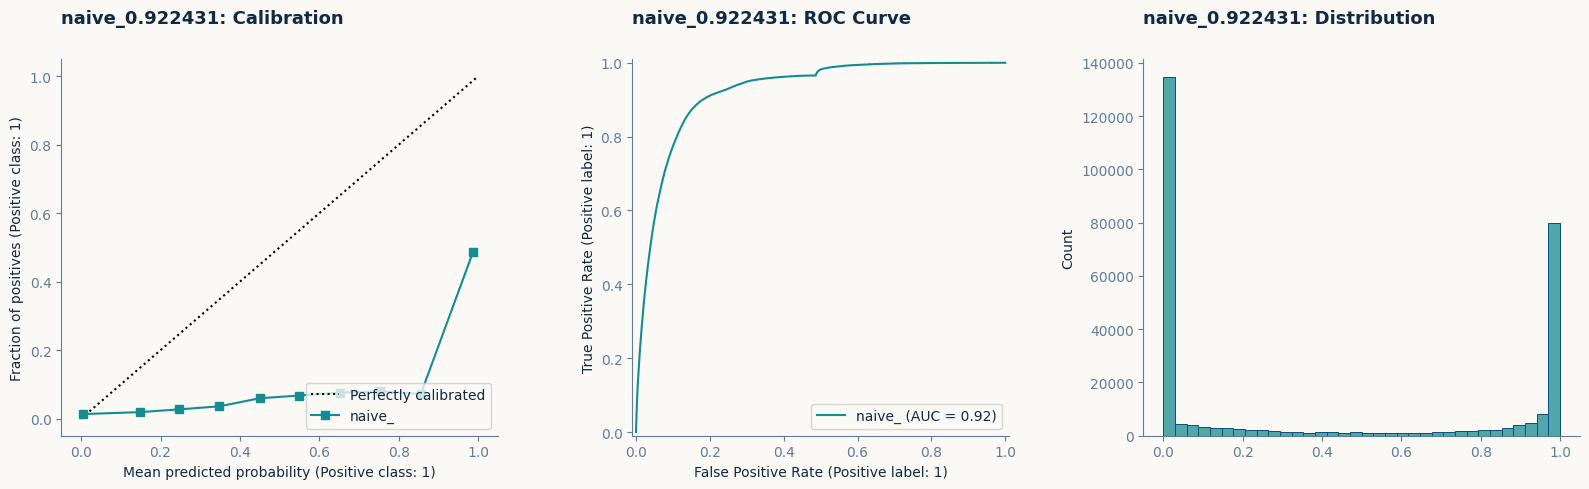

 25%|██▌       | 1/4 [00:46<02:19, 46.55s/it]


[2] LOGIT_ ██████████ | (601798, 18)
-> Total expanded features: 27
	Fold 1/10 Score: 0.936996
	Fold 2/10 Score: 0.936727
	Fold 3/10 Score: 0.937786
	Fold 4/10 Score: 0.938621
	Fold 5/10 Score: 0.939272
	Fold 6/10 Score: 0.939365
	Fold 7/10 Score: 0.938574
	Fold 8/10 Score: 0.939186
	Fold 9/10 Score: 0.939229
	Fold 10/10 Score: 0.937308
-------------------------------
OOF Score: 0.938305
AVG Score: 0.938307 ± 0.000966
-------------------------------
Duration: 1.50 mins


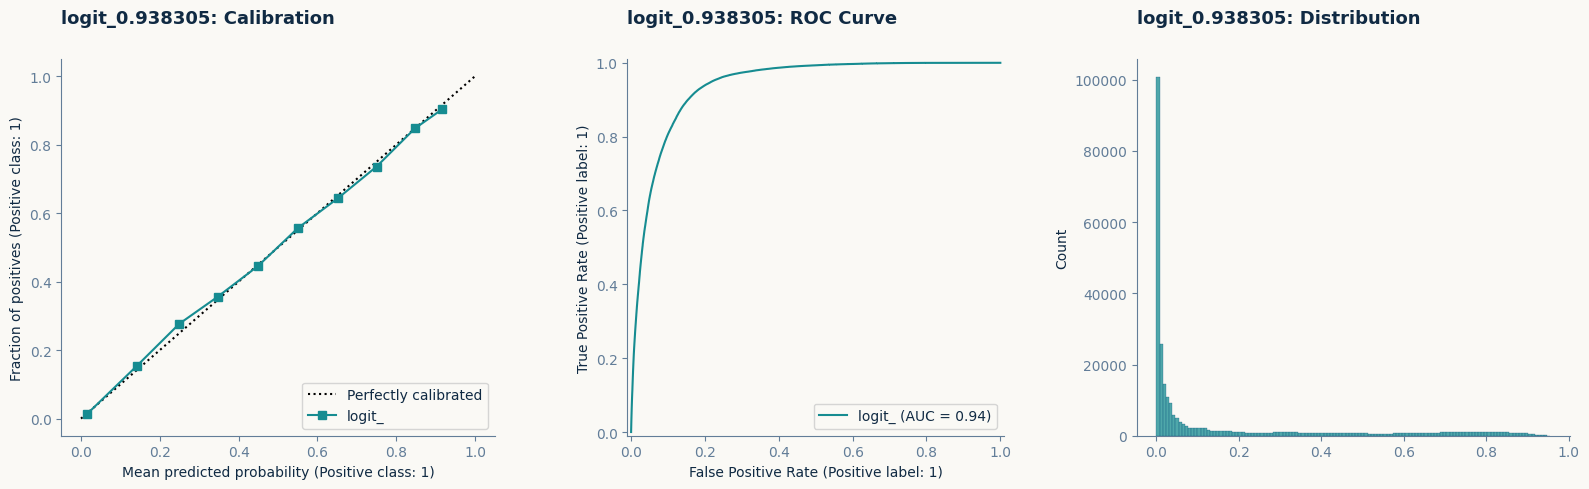

 50%|█████     | 2/4 [02:17<02:25, 72.82s/it]


[3] MLP_ ██████████ | (601798, 18)
-> Total expanded features: 27
	Fold 1/10 Score: 0.937247
	Fold 2/10 Score: 0.936858
	Fold 3/10 Score: 0.937814
	Fold 4/10 Score: 0.938710
	Fold 5/10 Score: 0.939271
	Fold 6/10 Score: 0.939840
	Fold 7/10 Score: 0.939103
	Fold 8/10 Score: 0.939492
	Fold 9/10 Score: 0.939259
	Fold 10/10 Score: 0.937768
-------------------------------
OOF Score: 0.93842
AVG Score: 0.938536 ± 0.000981
-------------------------------
Duration: 19.51 mins


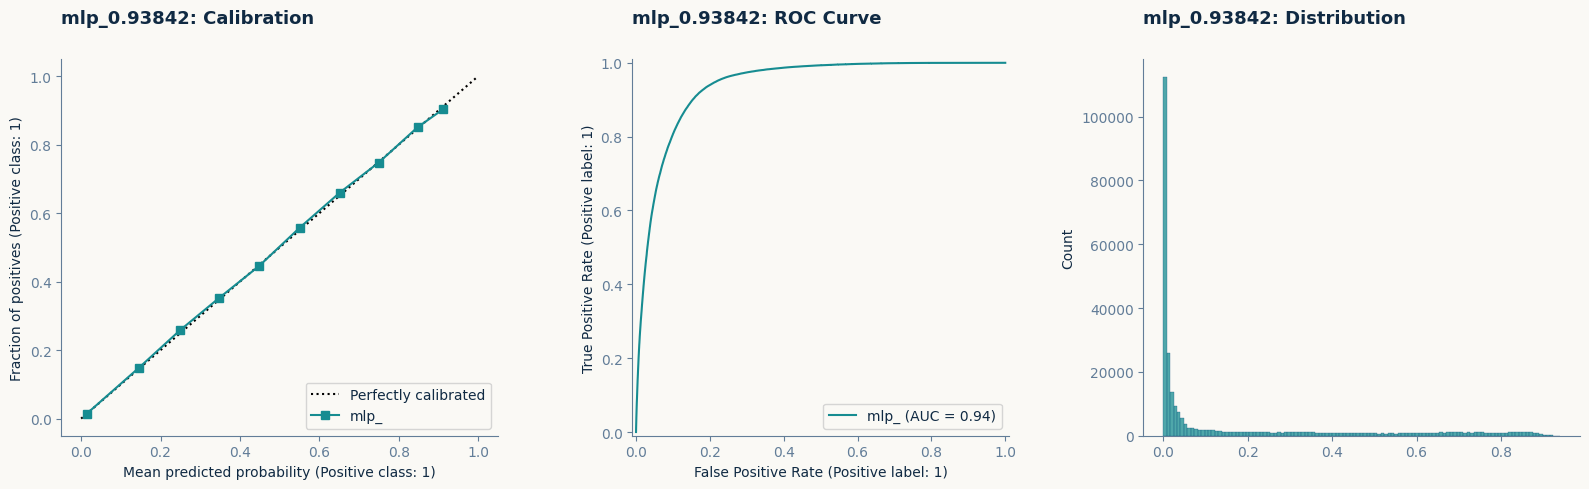

 75%|███████▌  | 3/4 [21:49<09:34, 574.77s/it]


[4] KNN_ ██████████ | (601798, 18)
-> Total expanded features: 27
	Fold 1/10 Score: 0.884166
	Fold 2/10 Score: 0.880442
	Fold 3/10 Score: 0.886004
	Fold 4/10 Score: 0.884225
	Fold 5/10 Score: 0.882846
	Fold 6/10 Score: 0.886230
	Fold 7/10 Score: 0.884868
	Fold 8/10 Score: 0.885887
	Fold 9/10 Score: 0.884560
	Fold 10/10 Score: 0.882937
-------------------------------
OOF Score: 0.884216
AVG Score: 0.884216 ± 0.001684
-------------------------------
Duration: 106.84 mins


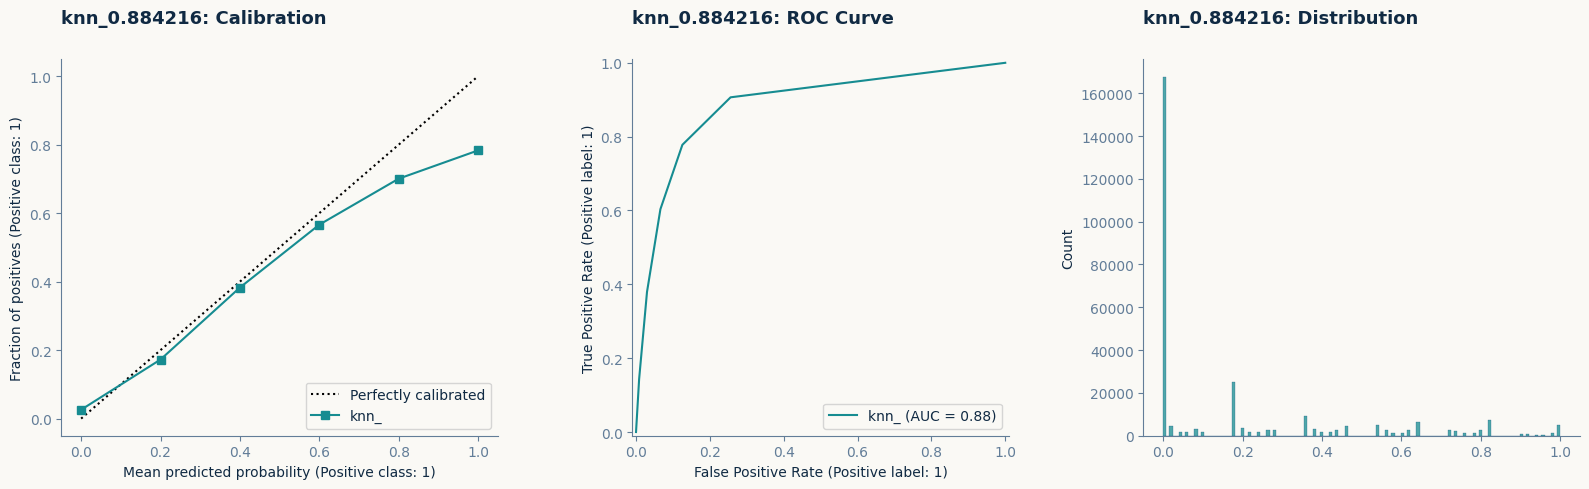

100%|██████████| 4/4 [2:08:42<00:00, 1930.61s/it]


In [72]:
## -- Initiate training --

LINEAR_MODELS = {}

for i, (name, mod) in tqdm(enumerate(linear_models.items(), 1), total=len(linear_models)):
    print(f"\n[{i}] {name.upper()} {'█'*10} | ", end="")
    t0 = time()

    X = train_2[FEATURES_2]
    y = train_2[TARGET]

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(test_2))
    fold_scores = []

    # CATS_2 = [c for c in NUMS if train_2[c].nunique() < 1000]
    # NUMS_LEFT = list(set(NUMS) - set(CATS_lt_1000))

    # if 'age' in NUMS:
    #     NUMS.remove('age')
    # if 'age' not in CATS:
    #     CATS.append('age')

    # X['age'] = X['age'].astype(str)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, y_train = X.iloc[train_idx], y[train_idx]
        X_valid, y_valid = X.iloc[val_idx], y[val_idx]
        X_test = test_2[FEATURES_2].copy()

        if fold == 1:
            print(X_train.shape)

        ## -- Define encoders --
        scaler_enc  = StandardScaler()
        one_hot_enc = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
        # num_imputer = IterativeImputer(max_iter=50, tol=1e-4, random_state=0, add_indicator=True)
        # cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING", add_indicator=False)
        # pwr_scaler   = PowerTransformer()
        ## ------------------------------------------------------------------------
        num_transformer = make_pipeline(scaler_enc)
        cat_transformer = make_pipeline(one_hot_enc)
        # pwr_transformer = make_pipeline(pwr_scaler)
        # num_cat_transformer = make_pipeline(num_cat_imputer, one_hot_enc)
        ## ------------------------------------------------------------------------
        # CATS_2 = [c for c in NUMS if X_train[c].nunique() < 1000]
        NUM_COLS = X_train.columns.difference(CATS, sort=False) #.tolist()
        ## ------------------------------------------------------------------------
        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', cat_transformer, CATS),
                ('num', num_transformer, NUM_COLS),
                # ('ptf', pwr_transformer, ["Annual_Income_USD"]),
                # ('num_cat', num_cat_transformer, CATS_lt_300),
            ],
            remainder="passthrough",
            n_jobs=-1,
        )
        ## ------------------------------------------------------------------------
        model = make_pipeline(preprocessor, mod)
        model.fit(X_train, y_train)
        if fold == 1:
            print(f"-> Total expanded features: {len(model[:-1].get_feature_names_out())}")
        ## ------------------------------------------------------------------------
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"\tFold {fold}/{skf.n_splits} Score: {fold_score:.6f}")

    # test_preds /= skf.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 6)

    print(f"{'-'*31}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print(f"{'-'*31}")
    # if 'log' in name:
    #     print(f"Best 'C': {lr_model[-1].C_}") 
    print(f"Duration: {(time() - t0)/60:.2f} mins")

    _, axs = plt.subplots(1, 3, figsize=(16, 5)) #, width_ratios=[0.6,0.4]
    # Right: Confusion matrix (threshold = 0.5)
    pred_labels = (oof_preds >= 0.5).astype('int8')

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
    axs[0].set_title(f"{name}{overall_score}: Calibration", loc='left', pad=26)

    # Left: ROC curve
    RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
    axs[1].set_title(f"{name}{overall_score}: ROC Curve", loc='left', pad=26)
    # axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{name}{overall_score}: Distribution", loc='left', pad=26)

    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split(".")[1]

    oof_final[n]     = oof_preds
    test_final[n]    = test_preds
    model_scores[n]  = overall_score
    LINEAR_MODELS[n] = model

    gc.collect()

In [73]:
# [1] NAIVE_ ██████████ | (534932, 13)
# -> Total expanded features: 22
# -------------------------------
# OOF Score: 0.925969
# AVG Score: 0.926214 ± 0.000792
# -------------------------------
# Duration: 0.42 mins

# [2] LOGIT_ ██████████ | (534932, 13)
# -> Total expanded features: 22
# -------------------------------
# OOF Score: 0.938256
# AVG Score: 0.938257 ± 0.000801
# -------------------------------
# Duration: 0.64 mins

# [3] MLP_ ██████████ | (534932, 14)
# -> Total expanded features: 23
# -------------------------------
# OOF Score: 0.938357
# AVG Score: 0.938420 ± 0.000782
# -------------------------------
# Duration: 4.05 mins

In [74]:
oof_final
# logit1.0_938256	logit0.1_938245	logit30.01_938192 - base
# logit1.0_938259	logit0.1_938253	logit30.01_9382   - squared age
# logit1.0_938267	logit0.1_938256	logit30.01_938208 - cubed age
# logit1.0_93827	logit0.1_938261	logit30.01_938213 - squared+cubed age

# logit1.0_938289	logit0.1_938287	logit30.01_938236 - squared commute_km
# logit1.0_938293	logit0.1_938289	logit30.01_938237 - cubed commute_km
# logit1.0_938294	logit0.1_938285	logit30.01_938232 - squared+cubed commute_km

# logit1.0_938306	logit0.1_938303	logit30.01_93825  - age+commute_km

# xgb_941693	lgb_941891	hist_941042	logit_938306	mlp_93846

,xgb_941731,lgb_941844,cat_941832,rfc_935875,hist_941065,naive_922431,logit_938305,mlp_93842,knn_884216
0,0.001382,0.001605,0.000106,0.000000,0.000248,1.213096e-18,0.000177,0.000155,0.0
1,0.004592,0.004719,0.002202,0.000000,0.002944,3.490087e-18,0.001470,0.001711,0.0
2,0.736309,0.741163,0.783630,0.673333,0.752703,9.981313e-01,0.737576,0.783648,1.0
3,0.004401,0.005269,0.001275,0.000000,0.002804,1.826404e-16,0.001483,0.001436,0.0
4,0.004787,0.005503,0.001894,0.000000,0.002355,5.059872e-17,0.000894,0.001613,0.0
...,...,...,...,...,...,...,...,...,...
668660,0.222403,0.236461,0.202071,0.246667,0.223024,4.915329e-14,0.251285,0.231160,0.4
668661,0.032050,0.037050,0.024879,0.010000,0.021155,5.019603e-01,0.041282,0.028087,0.0
668662,0.021536,0.026529,0.012321,0.010000,0.017774,4.402222e-01,0.030112,0.010997,0.0
668663,0.031553,0.034425,0.021558,0.023333,0.022536,4.764274e-01,0.029715,0.023344,0.0


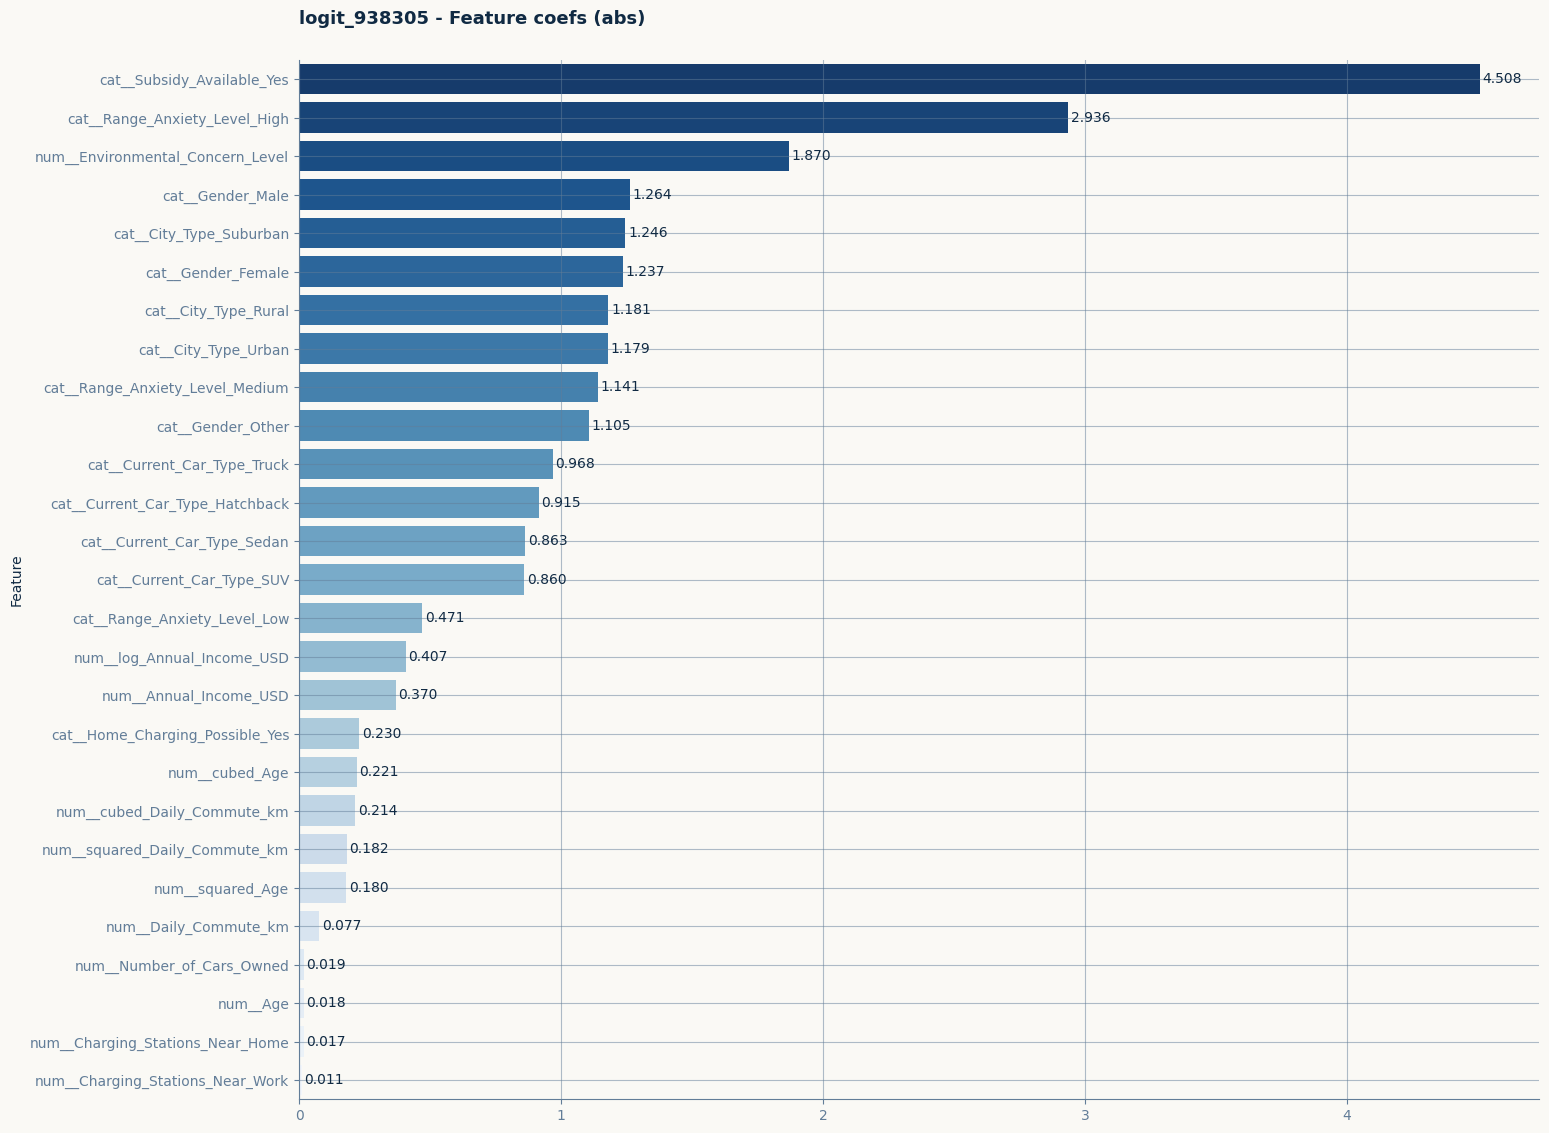

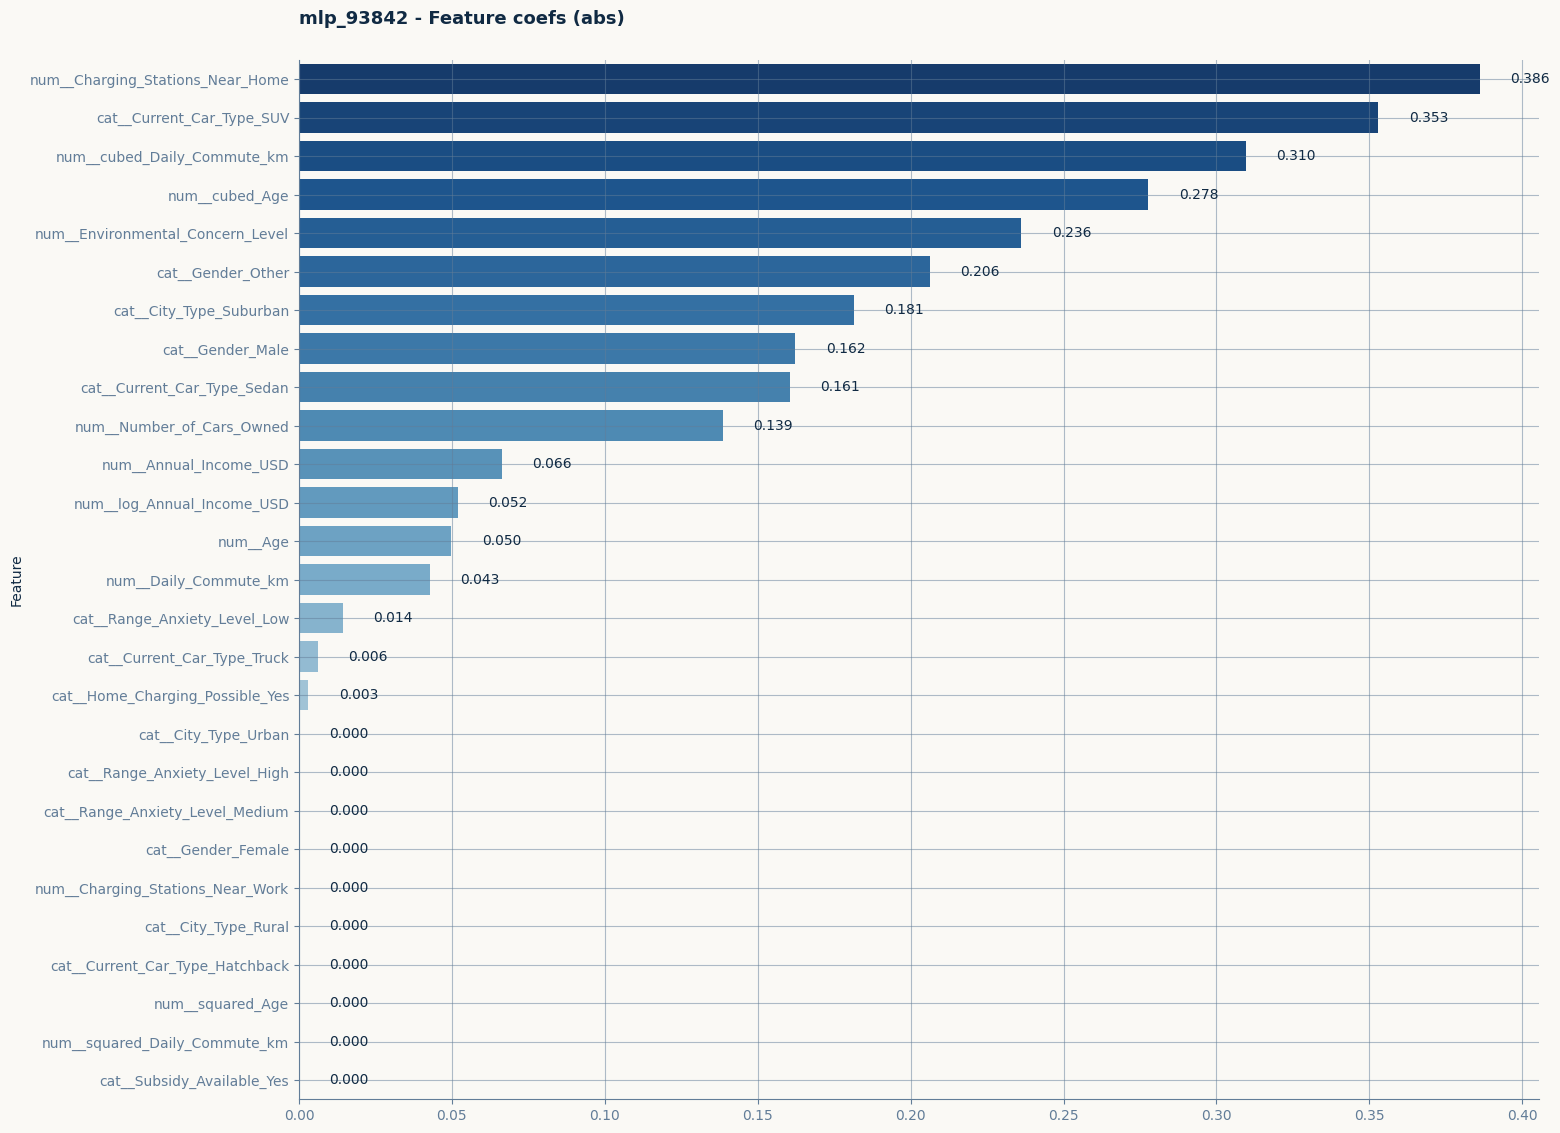

In [75]:
## -- Feature Coefs: Logistic Regression --

for i, name in enumerate(list(LINEAR_MODELS.keys())):
    if "logit" in name:
        coef_dict = dict(
            zip(
                LINEAR_MODELS[name][0].get_feature_names_out(),
                LINEAR_MODELS[name][-1].coef_[0],
                # X_valid.columns.tolist(),
                # LINEAR_MODELS[name].coef_[0],
            )
        )
    elif "mlp" in name:
        coef_dict = dict(
            zip(
                LINEAR_MODELS[name][0].get_feature_names_out(),
                LINEAR_MODELS[name][-1].coefs_[0][0],
                # X_valid.columns.tolist(),
                # LINEAR_MODELS[name].coef_[0],
            )
        )
    else:
        continue

    reg_imp = pd.Series(coef_dict).abs().sort_values(ascending=False) #.iloc[:40] # Top'N' features

    plt.figure(figsize=(16, len(reg_imp)*0.5))
    ax = sns.barplot(reg_imp, orient="h", palette="Blues_r")
    ax.set_ylabel("Feature")
    ax.set_title(f"{name} - Feature coefs (abs)", loc='left', pad=26)
    ax.grid()

    for i, v in enumerate(reg_imp.values):
        ax.text(v+1e-2, i, f"{v:.3f}", va="center", )

    plt.show()

# ~ STACKING

In [76]:
## -- Check if stack model exists --
drop_stacks = [c for c in oof_final.columns if "stack" in c]
oof_final   = oof_final.drop(columns=drop_stacks)
test_final  = test_final.drop(columns=drop_stacks)

print(oof_final.shape, test_final.shape)
oof_final

(668665, 9) (286571, 9)


,xgb_941731,lgb_941844,cat_941832,rfc_935875,hist_941065,naive_922431,logit_938305,mlp_93842,knn_884216
0,0.001382,0.001605,0.000106,0.000000,0.000248,1.213096e-18,0.000177,0.000155,0.0
1,0.004592,0.004719,0.002202,0.000000,0.002944,3.490087e-18,0.001470,0.001711,0.0
2,0.736309,0.741163,0.783630,0.673333,0.752703,9.981313e-01,0.737576,0.783648,1.0
3,0.004401,0.005269,0.001275,0.000000,0.002804,1.826404e-16,0.001483,0.001436,0.0
4,0.004787,0.005503,0.001894,0.000000,0.002355,5.059872e-17,0.000894,0.001613,0.0
...,...,...,...,...,...,...,...,...,...
668660,0.222403,0.236461,0.202071,0.246667,0.223024,4.915329e-14,0.251285,0.231160,0.4
668661,0.032050,0.037050,0.024879,0.010000,0.021155,5.019603e-01,0.041282,0.028087,0.0
668662,0.021536,0.026529,0.012321,0.010000,0.017774,4.402222e-01,0.030112,0.010997,0.0
668663,0.031553,0.034425,0.021558,0.023333,0.022536,4.764274e-01,0.029715,0.023344,0.0


In [77]:
# from scipy.stats import rankdata

# Cs = (0.001, 0.01, 0.1, 1.0)
# # USE_L1_L2 = True

# ## -- Search for best C --
# logit_cv = LogisticRegressionCV(
#     Cs=Cs,
#     cv=skf,
#     max_iter=1000,
#     # class_weight="balanced",
#     # penalty="elasticnet" if USE_L1_L2 else "l2",
#     # solver="saga" if USE_L1_L2 else "lbfgs",
#     # l1_ratios=np.linspace(0, 1, 5) if USE_L1_L2 else None,
#     scoring="roc_auc",
#     random_state=CFG["SEED"],
#     n_jobs=-1,
#     verbose=0,
# )

# model_pipe = make_pipeline(StandardScaler(), logit_cv)

# model_pipe.fit(rankdata(oof_final.to_numpy(), axis=0), train[TARGET])
# print(f"Best C: {model_pipe[-1].C_} | Best L1_ratio: {model_pipe[-1].l1_ratio_}")

In [78]:
# model_pipe[-1].scores_

In [79]:
# cv_scores = [s for s in model_pipe[-1].scores_.values()]

# for i, (c, scores) in enumerate(zip(Cs, cv_scores[0])):
#     avg = sum(scores[i]) / skf.n_splits
#     print(f"{c:>5}: {avg:.6f}")

Stacking models: 9
Fold 1/10 | Fold 1 AUC: 0.940834
Fold 2/10 | Fold 2 AUC: 0.941096
Fold 3/10 | Fold 3 AUC: 0.941371
Fold 4/10 | Fold 4 AUC: 0.942084
Fold 5/10 | Fold 5 AUC: 0.942977
Fold 6/10 | Fold 6 AUC: 0.943338
Fold 7/10 | Fold 7 AUC: 0.942127
Fold 8/10 | Fold 8 AUC: 0.943025
Fold 9/10 | Fold 9 AUC: 0.943157
Fold 10/10 | Fold 10 AUC: 0.940959
|------------------------------
| OOF Score: 0.942087
| AVG Score: 0.942097 ± 0.000934
|------------------------------
| Duration: 30.09 secs


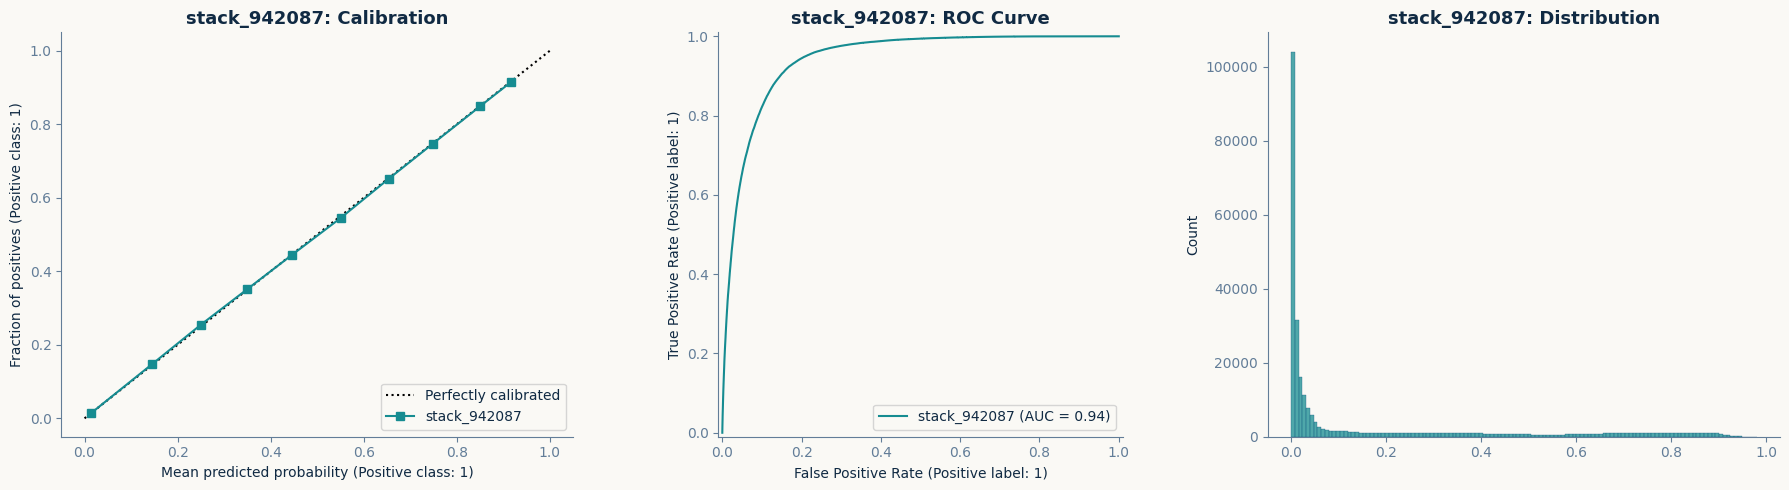

In [80]:
## -- Define Training Parameters --
def prob_to_prob(p, eps=1e-15, clip=30.0):
    p = np.clip(np.asarray(p), eps, 1.0 - eps)
    p = np.log(p / (1 - p))
    return np.clip(p, -clip, clip)

## -- Check if stack model exists --
drop_stacks  = [c for c in model_scores.index if "stack" in c]
model_scores = model_scores.drop(drop_stacks)

drop_stacks  = [c for c in oof_final.columns if "stack" in c]
oof_final    = oof_final.drop(columns=drop_stacks)
test_final   = test_final.drop(columns=drop_stacks)

stack_oof_preds  = np.zeros(len(oof_final))
stack_test_preds = np.zeros(len(test_final))
fold_scores = []

X = prob_to_prob(oof_final).astype(np.float32)
y = train[TARGET].values

## -- Initiate Training --
t0 = time()

print(f"Stacking models: {X.shape[1]}")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}/{skf.n_splits} | ", end='')
    
    X_train, X_valid = X[train_idx], X[val_idx]
    y_train, y_valid = y[train_idx], y[val_idx]
    X_test = prob_to_prob(test_final).astype(np.float32)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train, y_train)
    X_valid = scaler.transform(X_valid)
    X_test  = scaler.transform(X_test)

    meta_model = LogisticRegression(**{
        "C": 1.0,
        "max_iter": 1000,
        "random_state": 0,
    })

    meta_model.fit(X_train, y_train)
    stack_oof_preds[val_idx] = meta_model.predict_proba(X_valid)[:, 1]
    stack_test_preds += meta_model.predict_proba(X_test)[:, 1] / skf.n_splits
    
    oof_score = roc_auc_score(y_valid, stack_oof_preds[val_idx])
    fold_scores.append(oof_score)
    print(f"Fold {fold} AUC: {oof_score:.6f}")

## -- After all folds --
stack_score = np.round(roc_auc_score(y, stack_oof_preds), 6)
stack_name = 'stack_' + str(stack_score).split('.')[1]

print(f"|{'-'*30}")
print(f"| OOF Score: {stack_score}")
print(f"| AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
print(f"|{'-'*30}")
print(f"| Duration: {(time()-t0):.2f} secs")

_, axs = plt.subplots(1, 3, figsize=(18, 5))

CalibrationDisplay.from_predictions(y, stack_oof_preds.clip(0, 1), n_bins=10, name=stack_name, ax=axs[0])
axs[0].set_title(f"{stack_name}: Calibration")

RocCurveDisplay.from_predictions(y, stack_oof_preds, name=stack_name, ax=axs[1])
axs[1].set_title(f"{stack_name}: ROC Curve")
# axs[1].grid(False)

sns.histplot(stack_test_preds, ax=axs[2])
axs[2].set_title(f"{stack_name}: Distribution")

plt.tight_layout()
plt.show()

In [81]:
oof_final[stack_name]    = stack_oof_preds
test_final[stack_name]   = stack_test_preds
model_scores[stack_name] = stack_score

display(oof_final)
model_scores

,xgb_941731,lgb_941844,cat_941832,rfc_935875,hist_941065,naive_922431,logit_938305,mlp_93842,knn_884216,stack_942087
0,0.001382,0.001605,0.000106,0.000000,0.000248,1.213096e-18,0.000177,0.000155,0.0,0.000288
1,0.004592,0.004719,0.002202,0.000000,0.002944,3.490087e-18,0.001470,0.001711,0.0,0.002095
2,0.736309,0.741163,0.783630,0.673333,0.752703,9.981313e-01,0.737576,0.783648,1.0,0.773297
3,0.004401,0.005269,0.001275,0.000000,0.002804,1.826404e-16,0.001483,0.001436,0.0,0.001659
4,0.004787,0.005503,0.001894,0.000000,0.002355,5.059872e-17,0.000894,0.001613,0.0,0.002241
...,...,...,...,...,...,...,...,...,...,...
668660,0.222403,0.236461,0.202071,0.246667,0.223024,4.915329e-14,0.251285,0.231160,0.4,0.207752
668661,0.032050,0.037050,0.024879,0.010000,0.021155,5.019603e-01,0.041282,0.028087,0.0,0.024619
668662,0.021536,0.026529,0.012321,0.010000,0.017774,4.402222e-01,0.030112,0.010997,0.0,0.014578
668663,0.031553,0.034425,0.021558,0.023333,0.022536,4.764274e-01,0.029715,0.023344,0.0,0.023526


xgb_941731      0.941731
lgb_941844      0.941844
cat_941832      0.941832
rfc_935875      0.935875
hist_941065     0.941065
naive_922431    0.922431
logit_938305    0.938305
mlp_93842       0.938420
knn_884216      0.884216
stack_942087    0.942087
dtype: float64

# ~ HILLCLIMB

In [82]:
try:
    from hillclimbers import climb_hill, partial
except:
    !uv pip install --system hillclimbers
    from hillclimbers import climb_hill, partial

Using Python 3.12.13 environment at: /usr
Resolved 11 packages in 1.30s
Prepared 1 package in 335ms
Installed 1 package in 1ms
 + hillclimbers==0.1.4


In [83]:
%%time

## -- Run hillclimber --
hc_test_preds, hc_oof_preds = climb_hill(
        train=train,
        target=TARGET,
        oof_pred_df=oof_final.drop(columns=[stack_name]),
        test_pred_df=test_final.drop(columns=[stack_name]),
        eval_metric=partial(roc_auc_score),
        objective="maximize",
        return_oof_preds=True,
        negative_weights=True,
        precision=0.01,
        plot_hill=True,
        plot_hist=False,
)

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (9 total): 

lgb_941844:   0.94184 (best solo model)
cat_941832:   0.94183
xgb_941731:   0.94173
hist_941065:  0.94106
mlp_93842:    0.93842
logit_938305: 0.93831
rfc_935875:   0.93588
naive_922431: 0.92243
knn_884216:   0.88422

[Data preparation completed successfully] - [Initiate hill climbing] 

Iteration: 1 | Model added: cat_941832 | Best weight: 0.49 | Best roc_auc_score: 0.94204
Iteration: 2 | Model added: logit_938305 | Best weight: -0.12 | Best roc_auc_score: 0.94209
Iteration: 3 | Model added: xgb_941731 | Best weight: 0.16 | Best roc_auc_score: 0.94210
Iteration: 4 | Model added: mlp_93842 | Best weight: -0.05 | Best roc_auc_score: 0.94211
Iteration: 5 | Model added: hist_941065 | Best weight: -0.03 | Best roc_auc_score: 0.94211
Iteration: 6 | Model added: rfc_935875 | Best weight: 0.01 | Best roc_auc_score: 0.94211


CPU times: user 11min 10s, sys: 2.16 s, total: 11min 12s
Wall time: 11min 13s


In [84]:
hc_score = np.round(roc_auc_score(y, hc_oof_preds), 6)
hc_name = "hillclimb_" + str(hc_score).split('.')[1]

oof_final[hc_name]  = hc_oof_preds
test_final[hc_name] = hc_test_preds

model_scores[hc_name] = hc_score
model_scores.sort_values(inplace=True)
model_scores

knn_884216          0.884216
naive_922431        0.922431
rfc_935875          0.935875
logit_938305        0.938305
mlp_93842           0.938420
hist_941065         0.941065
xgb_941731          0.941731
cat_941832          0.941832
lgb_941844          0.941844
stack_942087        0.942087
hillclimb_942113    0.942113
dtype: float64

,xgb_941731,lgb_941844,cat_941832,rfc_935875,hist_941065,naive_922431,logit_938305,mlp_93842,knn_884216,stack_942087,hillclimb_942113
0,0.001382,0.001605,0.000106,0.000000,0.000248,1.213096e-18,0.000177,0.000155,0.0,0.000288,0.001079
1,0.004592,0.004719,0.002202,0.000000,0.002944,3.490087e-18,0.001470,0.001711,0.0,0.002095,0.003964
2,0.736309,0.741163,0.783630,0.673333,0.752703,9.981313e-01,0.737576,0.783648,1.0,0.773297,0.758493
3,0.004401,0.005269,0.001275,0.000000,0.002804,1.826404e-16,0.001483,0.001436,0.0,0.001659,0.003773
4,0.004787,0.005503,0.001894,0.000000,0.002355,5.059872e-17,0.000894,0.001613,0.0,0.002241,0.004333


,xgb_941731,lgb_941844,cat_941832,rfc_935875,hist_941065,naive_922431,logit_938305,mlp_93842,knn_884216,stack_942087,hillclimb_942113
0,0.013701,0.016641,0.010923,0.007667,0.008060,7.694257e-16,0.005213,0.004760,0.00,0.012779,0.015319
1,0.031489,0.029806,0.021666,0.045333,0.018436,2.803449e-15,0.028617,0.024611,0.26,0.022417,0.026963
2,0.009040,0.010272,0.004858,0.004333,0.006402,2.265523e-16,0.005686,0.006096,0.00,0.005942,0.008152
3,0.004728,0.005648,0.002587,0.001333,0.003287,1.130048e-16,0.002772,0.003221,0.00,0.003097,0.004440
4,0.032205,0.035641,0.022054,0.022333,0.018062,1.163627e-01,0.022145,0.015555,0.00,0.025763,0.031216


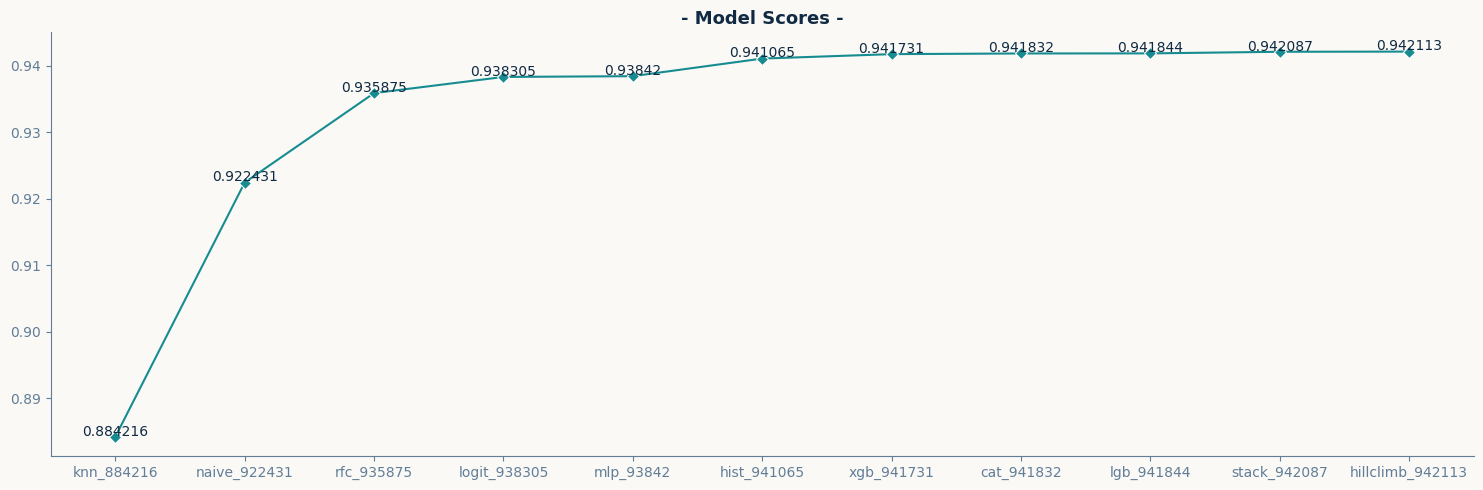

In [85]:
display(oof_final.head())
print()
display(test_final.head())
print()
plt.figure(figsize=(15, 5))
sns.lineplot(model_scores.sort_values(), marker='D')
plt.tick_params(axis='x')
plt.title("- Model Scores -", fontweight='bold')

for i, s in enumerate(model_scores.values):
    plt.text(model_scores.index[i], s+1e-3, s, va="center_baseline", ha="center")

plt.tight_layout()
plt.show()

# SUBMISSION

In [86]:
## -- Export stacking --

s_score = str(stack_score).split('.')[1]
s_oof   = oof_final[stack_name].to_numpy().ravel()
s_test  = test_final[stack_name].to_numpy().ravel()

stack_oof  = f"oof_base_stack_{s_score}.npy"
stack_pred = f"test_base_stack_{s_score}.npy"

np.save(stack_oof, s_oof)
np.save(stack_pred, s_test)

print(stack_oof, stack_pred)

oof_base_stack_942087.npy test_base_stack_942087.npy


In [87]:
## -- Export hillclimb --
h_score = str(hc_score).split('.')[1]
h_oof   = oof_final[hc_name].to_numpy().ravel()
h_test  = test_final[hc_name].to_numpy().ravel()

hill_oof  = f"oof_base_hill_{h_score}.npy"
hill_pred = f"test_base_hill_{h_score}.npy"

np.save(hill_oof, h_oof)
np.save(hill_pred, h_test)

print(hill_oof, hill_pred)

oof_base_hill_942113.npy test_base_hill_942113.npy


In [88]:
# ## -- Create Submission files --
# for i, c in enumerate(test_final.columns):
#     submit[TARGET] = test_final[c].values.ravel()
#     submit.to_csv(f"submit_base_{c}.csv", index=False)
#     print(f"--> submit_base_{c}.csv file saved!")

In [89]:
# !rm -r /kaggle/working/